<a href="https://colab.research.google.com/github/Michael-YaoYiWei/CUDA-Programming/blob/master/extras/exercises/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. PyTorch Classification Exercises

The following is a template for 02. PyTorch Classification exercises.

It's only starter code and it's your job to fill in the blanks.

Because of the flexibility of PyTorch, there may be more than one way to answer the question.

Don't worry about trying to be *right* just try writing code that suffices the question.

## Resources
* These exercises are based on [notebook 02 of the learn PyTorch course](https://www.learnpytorch.io/02_pytorch_classification/).
* You can see one form of [solutions on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions) (but try the exercises below yourself first!).

In [ ]:
# Import torch
import torch

# Setup device agnostic code


# Setup random seed
RANDOM_SEED = 42

## 1. Make a binary classification dataset with Scikit-Learn's [`make_moons()`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html) function.
  * For consistency, the dataset should have 1000 samples and a `random_state=42`.
  * Turn the data into PyTorch tensors.
  * Split the data into training and test sets using `train_test_split` with 80% training and 20% testing.

In [ ]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons

In [ ]:
# Turn data into a DataFrame
import pandas as pd


In [ ]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt


In [ ]:
# Turn data into tensors of dtype float


# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split


## 2. Build a model by subclassing `nn.Module` that incorporates non-linear activation functions and is capable of fitting the data you created in 1.
  * Feel free to use any combination of PyTorch layers (linear and non-linear) you want.

In [ ]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    ## Your code here ##

    def forward(self, x):
        ## Your code here ##
        return

# Instantiate the model
## Your code here ##

## 3. Setup a binary classification compatible loss function and optimizer to use when training the model built in 2.

In [ ]:
# Setup loss function

# Setup optimizer to optimize model's parameters

## 4. Create a training and testing loop to fit the model you created in 2 to the data you created in 1.
  * Do a forward pass of the model to see what's coming out in the form of logits, prediction probabilities and labels.
  * To measure model accuray, you can create your own accuracy function or use the accuracy function in [TorchMetrics](https://torchmetrics.readthedocs.io/en/latest/).
  * Train the model for long enough for it to reach over 96% accuracy.
  * The training loop should output progress every 10 epochs of the model's training and test set loss and accuracy.

In [ ]:
# What's coming out of our model?

# logits (raw outputs of model)
print("Logits:")
## Your code here ##

# Prediction probabilities
print("Pred probs:")
## Your code here ##

# Prediction labels
print("Pred labels:")
## Your code here ##

Logits:
Pred probs:
Pred labels:


In [ ]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
# acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
# acc_fn

In [ ]:
## TODO: Uncomment this to set the seed
# torch.manual_seed(RANDOM_SEED)

# Setup epochs


# Send data to the device


# Loop through the data
# for epoch in range(epochs):
  ### Training


  # 1. Forward pass (logits output)

  # Turn logits into prediction probabilities


  # Turn prediction probabilities into prediction labels


  # 2. Calculaute the loss
  # loss = loss_fn(y_logits, y_train) # loss = compare model raw outputs to desired model outputs

  # Calculate the accuracy
  # acc = acc_fn(y_pred, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients


  # 4. Loss backward (perform backpropagation) - https://brilliant.org/wiki/backpropagation/#:~:text=Backpropagation%2C%20short%20for%20%22backward%20propagation,to%20the%20neural%20network's%20weights.

  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression)


  ### Testing
  # model_0.eval()
  # with torch.inference_mode():
    # 1. Forward pass (to get the logits)

    # Turn the test logits into prediction labels


    # 2. Caculate the test loss/acc


  # Print out what's happening every 100 epochs
  # if epoch % 100 == 0:


## 5. Make predictions with your trained model and plot them using the `plot_decision_boundary()` function created in this notebook.

In [ ]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [ ]:
# Plot decision boundaries for training and test sets


## 6. Replicate the Tanh (hyperbolic tangent) activation function in pure PyTorch.
  * Feel free to reference the [ML cheatsheet website](https://ml-cheatsheet.readthedocs.io/en/latest/activation_functions.html#tanh) for the formula.

In [ ]:
# Create a straight line tensor


In [ ]:
# Test torch.tanh() on the tensor and plot it


In [ ]:
# Replicate torch.tanh() and plot it


## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

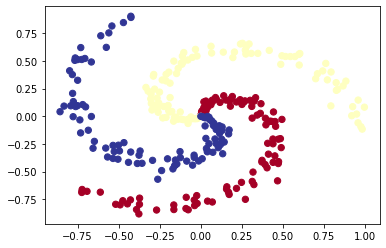

In [ ]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [ ]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split


In [ ]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
# acc_fn = Accuracy(task="multiclass", num_classes=4).to(device)
# acc_fn

In [ ]:
# Prepare device agnostic code
# device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module



# Instantiate model and send it to device


In [ ]:
# Setup data to be device agnostic


# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
## Your code here ##

print("Pred probs:")
## Your code here ##

print("Pred labels:")
## Your code here ##

Logits:
Pred probs:
Pred labels:


In [ ]:
# Setup loss function and optimizer
# loss_fn =
# optimizer =

In [ ]:
# Build a training loop for the model

# Loop over data


  ## Training

  # 1. Forward pass


  # 2. Calculate the loss


  # 3. Optimizer zero grad


  # 4. Loss backward


  # 5. Optimizer step


  ## Testing


    # 1. Forward pass

    # 2. Caculate loss and acc

  # Print out what's happening every 100 epochs


In [ ]:
# Plot decision boundaries for training and test sets


In [ ]:
S#!/usr/bin/env python
# coding: utf-8

# ============================================================
# Strela Operational Advisor — Complete Version
# 合并自：strela_advisor_v3_claude.py / strela_agent_v1.py
#         strela_retrieval_metrics.py + 新增模块
#
# 文件结构：
#   Part 1 — 基础配置 + 检索模块
#   Part 2 — Query Rewriting + Skills + Harness + Monitoring
#   Part 3 — Agent 模块（Skill+Harness / ReAct / LangGraph）
#   Part 4 — 评估框架（检索 + 生成）
#   Part 5 — LoRA/QLoRA + AWS部署 + Gradio UI + Unit Tests + main
#
# 主线选择说明：
#   - Query Rewriting : HyDE 为主线（Multi-query / Step-back 注释备用）
#   - 检索架构       : 混合检索 BM25 + Semantic + RRF 为主线
#   - Agent 架构     : Skill + Harness 为主线（ReAct / LangGraph 注释备用）
# ============================================================


# ============================================================
# PART 1：基础配置 + 检索模块
#
# 包含：
#   1.1  导入依赖
#   1.2  基础配置（Azure OpenAI / Embedding / ChromaDB）
#   1.3  规则库（RULES / DEFAULT_RULE）
#   1.4  基础语义检索（备用）
#   1.5  混合检索（BM25 + Semantic + RRF）← 主线
#   1.6  Cross-Encoder Reranker
# ============================================================


# ============================================================
# 1.1  导入依赖
# ============================================================
import os
import glob
import json
import re
import math
import time
import logging
from pathlib import Path
from collections import Counter
from typing import List, Dict, Tuple, Any, Optional

# 环境变量库
from dotenv import load_dotenv

# LangChain 核心
from langchain_chroma import Chroma
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_openai import AzureOpenAIEmbeddings, AzureChatOpenAI

# BM25 混合检索
from rank_bm25 import BM25Okapi

# Cross-Encoder Reranker
from sentence_transformers import CrossEncoder

# Gradio UI
import gradio as gr

# ── 可选：LangGraph（Part 3 需 langgraph 库）───
# from langgraph.graph import StateGraph, END
# from langgraph.prebuilt import ToolNode
# ────────────────────────────────────────────

# ── 可选：评估框架（Part 4 需 rouge-score, nltk, bert-score, ragas 库）───
# from rouge_score import rouge_scorer
# import nltk
# from bert_score import score as bert_score_fn
# ────────────────────────────────────────────

# ── 可选：Fine-tuning（Part 5 需 peft, bitsandbytes, transformers, trl, datasets）───
# ────────────────────────────────────────────

# 日志配置
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)
logger = logging.getLogger(__name__)

print("✅ 依赖库导入成功")


# ============================================================
# 1.2  基础配置
# ============================================================

# ── 模型与路径配置 ────────────────────────────────────────
MODEL          = "gpt-4o"
DB_NAME        = "vector_db"        # ChromaDB 持久化目录
KNOWLEDGE_PATH = "knowledge_base"   # 知识库文档目录（存放 .md 文件）
LOG_DIR        = "./strela_logs"    # 监控日志目录（Part 2 使用）

# ── 加载 .env（存放 API Key 等敏感信息，不要提交到 Git）───
load_dotenv(override=True)

API_KEY     = os.getenv("OPENAI_API_KEY")
ENDPOINT    = "https://cog-openai-od-ed.openai.azure.com/"
API_VERSION = "2025-01-01-preview"

if API_KEY:
    logger.info(f"✅ Azure OpenAI API Key 已加载，前缀：{API_KEY[:8]}")
else:
    logger.warning("❌ 未找到 API Key，请检查 .env 文件")


# ── 初始化 Embedding 模型 ─────────────────────────────────
# text-embedding-3-large：3072 维向量
# 大维度 embedding 语义表达能力更强，检索效果优于 ada-002
embeddings = AzureOpenAIEmbeddings(
    azure_endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    deployment="text-embedding-3-large"
)

# ── 初始化 LLM ────────────────────────────────────────────
# temperature=0：输出确定性更强，减少随机性和幻觉
# 工业顾问场景下，稳定比"创意"更重要
llm = AzureChatOpenAI(
    azure_deployment=MODEL,
    azure_endpoint=ENDPOINT,
    api_key=API_KEY,
    api_version=API_VERSION,
    temperature=0
)

# ── 构建 / 加载 ChromaDB 向量数据库 ──────────────────────
if os.path.exists(DB_NAME):
    logger.info(f"✅ 检测到已有向量数据库，直接加载：{DB_NAME}")
    vectorstore = Chroma(
        persist_directory=DB_NAME,
        embedding_function=embeddings
    )
else:
    logger.info("⚙️ 未检测到向量数据库，开始构建...")

    folders   = glob.glob(KNOWLEDGE_PATH + "/*")
    documents = []

    for folder in folders:
        # 文件夹名作为 doc_type 标签（例如：quickstart / troubleshooting）
        doc_type = os.path.basename(folder)
        loader   = DirectoryLoader(
            folder,
            glob="**/*.md",
            loader_cls=TextLoader,
            loader_kwargs={"encoding": "utf-8"}
        )
        folder_docs = loader.load()
        for doc in folder_docs:
            doc.metadata["doc_type"] = doc_type
            documents.append(doc)

    logger.info(f"✅ 共加载 {len(documents)} 个文档")

    # 文档切分
    # chunk_size=1000  : 每块最多 1000 字符
    # chunk_overlap=200: 相邻块重叠 200 字符，防止关键信息被切断
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )
    chunks = text_splitter.split_documents(documents)
    logger.info(f"✅ 共切分为 {len(chunks)} 个文本块")

    vectorstore = Chroma.from_documents(
        documents=chunks,
        embedding=embeddings,
        persist_directory=DB_NAME
    )
    logger.info(
        f"✅ 向量数据库构建完成，共 {vectorstore._collection.count()} 个向量"
    )

# ── 读取所有 chunk 供 BM25 使用 ────────────────────────────
# ChromaDB.get() 返回所有文档文本和元数据
try:
    _all_data           = vectorstore.get(
        include=["documents", "metadatas"]
    )
    ALL_CHUNKS_TEXTS    = _all_data["documents"]   # List[str]
    ALL_CHUNKS_METADATA = _all_data["metadatas"]   # List[dict]
    logger.info(
        f"✅ 已从向量库读取 {len(ALL_CHUNKS_TEXTS)} 个 chunk 用于 BM25"
    )
except Exception as e:
    logger.warning(f"⚠️ 读取 chunk 失败，BM25 将不可用：{e}")
    ALL_CHUNKS_TEXTS    = []
    ALL_CHUNKS_METADATA = []

print("✅ 基础配置完成")


# ============================================================
# 1.3  规则库（RULES / DEFAULT_RULE）
#
# 设计理念（Constrained Workflow 核心）：
#   - 硬规则（Hard Rules）：关键词命中即触发，完全不依赖 LLM 判断
#   - 相当于"领域专家经验的显式编码"
#   - 可独立维护：只改这个字典，不需要动任何代码逻辑
#   - 与 LLM 软判断互补：关键词匹配失败时才交给 LLM 分类
# ============================================================

RULES: Dict[str, Dict] = {
    "how_to": {
        # 操作类：用户想知道"怎么做"
        "keywords": [
            "how to", "how do i", "how can i", "steps to",
            "怎么", "如何", "步骤", "操作"
        ],
        "doc_type_priority": [
            "quickstart", "accessit", "reporting", "simulation"
        ],
        "diagnosis": "这是一个操作指引类问题",
        "actions": [
            "建议先查阅 quickstart 文档了解基本流程",
            "如涉及权限或登录，参考 accessit 模块",
            "如涉及报告生成，参考 reporting 模块"
        ]
    },
    "troubleshooting": {
        # 故障排查类：用户遇到问题或错误
        "keywords": [
            "error", "issue", "problem", "not working", "fail",
            "cannot", "wrong", "bug",
            "错误", "问题", "无法", "失败", "不能"
        ],
        "doc_type_priority": [
            "troubleshooting", "recentchanges", "glossary", "reporting_old"
        ],
        "diagnosis": "这是一个故障排查类问题",
        "actions": [
            "优先检查 troubleshooting 文档中的已知问题列表",
            "查看 recentchanges 确认是否有近期版本变更影响",
            "如涉及术语理解，参考 glossary"
        ]
    },
    "concept": {
        # 概念理解类：用户想了解某个术语或功能
        "keywords": [
            "what is", "what does", "explain", "define", "meaning",
            "difference between", "是什么", "解释", "定义", "区别"
        ],
        "doc_type_priority": ["glossary", "background", "intro"],
        "diagnosis": "这是一个概念理解类问题",
        "actions": [
            "建议先查阅 glossary 获取术语定义",
            "background 文档提供系统背景知识",
            "intro 文档适合初次了解系统整体架构"
        ]
    },
    "recommendation": {
        # 建议类：用户想要推荐或最佳实践
        "keywords": [
            "recommend", "suggest", "best practice", "should i",
            "which", "what should", "advise",
            "推荐", "建议", "最佳", "应该"
        ],
        "doc_type_priority": [
            "quickstart", "troubleshooting", "simulation", "reporting"
        ],
        "diagnosis": "这是一个寻求建议类问题",
        "actions": [
            "根据使用场景推荐最相关的模块文档",
            "结合用户当前操作上下文给出优先级建议",
            "如不确定，建议从 quickstart 开始"
        ]
    }
}

# 当问题无法匹配任何规则时的默认处理
DEFAULT_RULE: Dict[str, Any] = {
    "doc_type_priority": ["quickstart", "troubleshooting", "glossary"],
    "diagnosis": "问题类型未能明确识别",
    "actions": [
        "建议从 quickstart 开始了解系统",
        "如遇到具体问题，参考 troubleshooting",
        "如有术语不理解，参考 glossary"
    ]
}

print("✅ 规则库加载完成")


# ============================================================
# 1.4  基础语义检索（备用方案）
#
# 主线是混合检索（1.5），这里保留纯语义检索作为备用
# 替换方法：把所有 retrieve_with_rerank() 调用换成：
#     docs = semantic_retriever.invoke(question)
# ============================================================

# 基础语义检索器
semantic_retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)

# ── 备用：MMR 检索（最大边际相关性，减少结果重复度）───────
# mmr_retriever = vectorstore.as_retriever(
#     search_type="mmr",
#     search_kwargs={
#         "k": 5,
#         "fetch_k": 20,
#         "lambda_mult": 0.5  # 0=最大多样性，1=最大相关性
#     }
# )
# ─────────────────────────────────────────────────────────

print("✅ 语义检索器初始化完成")


# ============================================================
# 1.5  混合检索（BM25 + Semantic + RRF）← 主线
#
# 为什么混合检索比纯语义检索更好：
#   语义检索（Bi-Encoder / 向量相似度）：
#     优点：理解语义相似性，能处理同义词、改写、意译
#     缺点：对精确关键词（型号名、错误码、专有名词）不敏感
#
#   BM25（词频统计 / 稀疏检索）：
#     优点：精确关键词匹配效果好，不依赖向量训练
#     缺点：无法理解语义，不能处理近义词和改写
#
#   RRF 融合：取长补短
#     两个列表都排名靠前的文档得分最高
#     只出现在一个列表的文档也能得到一定分数，不会丢失
#
# RRF 公式：score(d) = Σ  1 / (k + rank_i(d))
#   k=60 是 Cormack et al. (SIGIR 2009) 推荐经验常数
#   rank 从 1 开始，排名越靠前贡献越大
# ============================================================

# ── 构建 BM25 索引 ────────────────────────────────────────
if ALL_CHUNKS_TEXTS:
    # BM25Okapi 需要分词后的 token 列表
    _bm25_corpus = [text.lower().split() for text in ALL_CHUNKS_TEXTS]
    bm25_index   = BM25Okapi(_bm25_corpus)
    logger.info(
        f"✅ BM25 索引构建完成，共 {len(_bm25_corpus)} 个文档"
    )
else:
    bm25_index = None
    logger.warning("⚠️ BM25 索引未构建（无可用 chunk）")


def bm25_retrieve(query: str, k: int = 20) -> List[Dict]:
    """
    BM25 检索

    Args:
        query: 用户查询字符串
        k    : 返回的文档数量

    Returns:
        List[Dict]: 按 BM25 分数降序排列的 top-k 结果
        每个 Dict 包含：text, metadata, bm25_score
    """
    if bm25_index is None or not ALL_CHUNKS_TEXTS:
        return []

    query_tokens = query.lower().split()
    scores       = bm25_index.get_scores(query_tokens)

    # 取 top-k 索引
    top_indices = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True
    )[:k]

    results = []
    for idx in top_indices:
        meta = ALL_CHUNKS_METADATA[idx] \
               if idx < len(ALL_CHUNKS_METADATA) else {}
        results.append({
            "text":       ALL_CHUNKS_TEXTS[idx],
            "metadata":   meta,
            "bm25_score": float(scores[idx])
        })
    return results


def semantic_retrieve_raw(query: str, k: int = 20) -> List[Any]:
    """
    语义检索（向量相似度），返回 LangChain Document 列表
    与 semantic_retriever 的区别：这里可以自定义 k 值
    """
    return vectorstore.similarity_search(query, k=k)


def rrf_fusion(
    bm25_results:     List[Dict],
    semantic_results: List[Any],
    k_rrf:            int = 60,
    top_n:            int = 20
) -> List[Any]:
    """
    RRF（Reciprocal Rank Fusion）融合两个排序列表

    Args:
        bm25_results     : BM25 检索结果（List[Dict]，含 text 字段）
        semantic_results : 语义检索结果（List[LangChain Document]）
        k_rrf            : RRF 平滑常数，默认 60
        top_n            : 最终返回的候选文档数量

    Returns:
        融合排序后的 top_n 个文档对象
        每个文档统一有 .page_content 和 .metadata 属性

    RRF 公式：
        score(d) = Σ_i  1 / (k_rrf + rank_i(d))
        rank 从 1 开始
        文档在某个列表中排名越靠前，贡献分数越高
        如果文档只出现在一个列表中，也会得到相应分数

    参考：
        Cormack et al. "Reciprocal Rank Fusion outperforms
        Condorcet and individual rank learning methods"
        SIGIR 2009
    """
    rrf_scores: Dict[str, float] = {}
    doc_map:    Dict[str, Any]   = {}

    # 内部辅助类：统一 BM25 结果接口
    class _Doc:
        """模拟 LangChain Document 接口"""
        def __init__(self, text: str, metadata: dict):
            self.page_content = text
            self.metadata     = metadata

    # BM25 排名贡献
    for rank, item in enumerate(bm25_results, start=1):
        key = item["text"][:200]   # 用前 200 字符作唯一 key
        rrf_scores[key]  = rrf_scores.get(
            key, 0.0
        ) + 1.0 / (k_rrf + rank)
        if key not in doc_map:
            doc_map[key] = _Doc(item["text"], item["metadata"])

    # 语义检索排名贡献
    for rank, doc in enumerate(semantic_results, start=1):
        key = doc.page_content[:200]
        rrf_scores[key]  = rrf_scores.get(
            key, 0.0
        ) + 1.0 / (k_rrf + rank)
        if key not in doc_map:
            doc_map[key] = doc

    # 按 RRF 分数降序，取 top_n
    sorted_keys = sorted(
        rrf_scores, key=lambda x: rrf_scores[x], reverse=True
    )
    return [doc_map[k] for k in sorted_keys[:top_n]]


def hybrid_retrieve(query: str, top_n: int = 20) -> List[Any]:
    """
    混合检索主函数（主线 - Two-stage Retrieval Stage 1）

    流程：
        1. BM25 召回 top-20（精确关键词匹配）
        2. 语义检索召回 top-20（语义相似度匹配）
        3. RRF 融合两个列表 → 返回 top_n 候选

    注意：
        此函数只负责召回阶段（Stage 1）
        精排阶段（Stage 2）由 rerank() 完成
        完整调用链：
          hybrid_retrieve() → rerank() → retrieve_with_rerank()

    备用方案（替换此函数的调用处）：
        # 纯语义检索（无 BM25，无精排）
        docs = semantic_retriever.invoke(query)
        # 纯语义检索（自定义 k）
        docs = semantic_retrieve_raw(query, k=top_n)
    """
    logger.info(f"  [混合检索] 开始：{query[:50]}")

    bm25_results     = bm25_retrieve(query, k=20)
    semantic_results = semantic_retrieve_raw(query, k=20)

    logger.info(
        f"  [混合检索] BM25={len(bm25_results)} "
        f"/ 语义={len(semantic_results)}"
    )

    fused = rrf_fusion(bm25_results, semantic_results, top_n=top_n)
    logger.info(f"  [混合检索] RRF 融合后候选数：{len(fused)}")
    return fused


print("✅ 混合检索（BM25 + Semantic + RRF）模块完成")


# ============================================================
# 1.6  Cross-Encoder Reranker（两阶段检索 Stage 2）
#
# 为什么需要 Reranker：
#   Bi-Encoder（向量检索 / Stage 1）：
#     query 和 doc 分别独立编码 → 速度快，适合大规模召回
#     缺点：query 和 doc 之间没有交互，精度有上限
#
#   Cross-Encoder（精排 / Stage 2）：
#     query + doc 拼接后一起输入模型 → 精度大幅提升
#     缺点：每对 (query, doc) 都要单独推理，不能用于全库检索
#     解决方案：Stage 1 先召回少量候选，Stage 2 再精排
#
# 两阶段检索 Pipeline：
#   Stage 1：hybrid_retrieve → 召回 top-20（速度优先，保证召回率）
#   Stage 2：rerank          → 精排 top-5（精度优先，保证准确率）
#
# Reranker 模型选择：
#   主线：cross-encoder/ms-marco-MiniLM-L-6-v2
#         （轻量快速，适合生产环境）
#   备用：cross-encoder/ms-marco-electra-base
#         （精度更高，速度较慢，适合离线评估）
#   备用：BAAI/bge-reranker-base
#         （中文更友好，适合中英混合场景）
# ============================================================

try:
    reranker_model     = CrossEncoder(
        "cross-encoder/ms-marco-MiniLM-L-6-v2",
        max_length=512
    )
    RERANKER_AVAILABLE = True
    logger.info("✅ Cross-Encoder Reranker 加载成功")
except Exception as e:
    reranker_model     = None
    RERANKER_AVAILABLE = False
    logger.warning(f"⚠️ Reranker 加载失败，将跳过精排：{e}")

    # ── 备用 Reranker 模型（取消注释替换上面的模型名）────
    # reranker_model = CrossEncoder(
    #     "cross-encoder/ms-marco-electra-base",
    #     max_length=512
    # )
    # reranker_model = CrossEncoder(
    #     "BAAI/bge-reranker-base",
    #     max_length=512
    # )
    # ─────────────────────────────────────────────────────


def rerank(
    query: str, candidates: List[Any], top_k: int = 5
) -> List[Any]:
    """
    Cross-Encoder 精排（Stage 2）

    Args:
        query      : 用户原始问题
        candidates : Stage 1 召回的候选文档列表
        top_k      : 精排后返回的文档数量

    Returns:
        按 Cross-Encoder 分数降序排列的 top_k 文档

    降级处理：
        如果 Reranker 不可用（加载失败或模型文件缺失），
        直接返回 candidates[:top_k]，保证系统仍能正常运行
    """
    if not RERANKER_AVAILABLE or reranker_model is None:
        logger.warning("  [Reranker] 不可用，直接截取候选前 top_k 个")
        return candidates[:top_k]

    if not candidates:
        return []

    # 构建 (query, doc_text) 对，输入给 Cross-Encoder
    pairs  = [(query, doc.page_content) for doc in candidates]
    scores = reranker_model.predict(pairs)

    # 按分数从高到低排序
    ranked   = sorted(
        zip(scores, candidates),
        key=lambda x: x[0],
        reverse=True
    )
    top_docs = [doc for _, doc in ranked[:top_k]]

    logger.info(
        f"  [Reranker] 精排完成："
        f"{len(candidates)} → {len(top_docs)}"
    )
    return top_docs

    # ── 备用：跳过精排，直接用混合检索结果 ──────────────
    # return candidates[:top_k]
    # ─────────────────────────────────────────────────────


def retrieve_with_rerank(query: str, top_k: int = 5) -> List[Any]:
    """
    完整两阶段检索入口（对外统一接口）

    Stage 1：hybrid_retrieve(query, top_n=20)  → 召回 20 个候选
    Stage 2：rerank(query, candidates, top_k)  → 精排取 top_k

    这是 Part 2 Skills 模块调用检索的唯一入口
    如需切换检索策略，只改这一个函数即可

    备用方案（替换此函数的调用处）：
        # 纯语义检索，无混合检索，无精排
        docs = semantic_retriever.invoke(query)
    """
    candidates = hybrid_retrieve(query, top_n=20)
    final_docs = rerank(query, candidates, top_k=top_k)
    return final_docs


print("✅ Cross-Encoder Reranker 模块完成")
print("=" * 55)
print("✅ Part 1 全部完成：基础配置 + 检索模块")
print("   下一步：Part 2 — Query Rewriting + Skills + Harness")
print("=" * 55)

# ── Part 1 结束 ───────────────────────────────────────────────
# 下一步：Part 2 — Query Rewriting + Skills + Harness + Monitoring




#!/usr/bin/env python
# coding: utf-8

# ============================================================
# PART 2：Query Rewriting + Skills + Harness + Monitoring
#
# 前置依赖：Part 1 中已初始化的变量
#   - llm, embeddings, vectorstore
#   - ALL_CHUNKS_TEXTS, ALL_CHUNKS_METADATA
#   - RULES, DEFAULT_RULE
#   - retrieve_with_rerank, semantic_retriever
#   - bm25_index, reranker_model
#
# 包含：
#   2.1  Query Rewriting（HyDE 主线 + Multi-query / Step-back 备用）
#   2.2  五个 Skill 函数（分类 / 检索 / 规则 / 生成 / 主动推荐）
#   2.3  Advisor Harness 总控框架
#   2.4  Monitoring & Enhanced Fallback
# ============================================================


# ============================================================
# 2.1  Query Rewriting — 查询改写
#
# 为什么需要 Query Rewriting：
#   用户提问往往简短、口语化、不够精确
#   而文档是用长文、正式语言写的
#   查询改写把"用户语言"翻译为"文档语言"，大幅提升检索质量
#
# 三种主流方法对比：
#   ┌─────────────┬──────────────────────┬───────────┬──────────┐
#   │   方法       │      原理            │   优点     │   缺点    │
#   ├─────────────┼──────────────────────┼───────────┼──────────┤
#   │ HyDE        │ 生成假想答案→用答案   │ 语义桥接  │ 多一次   │
#   │   (主线)    │ 检索（而非用问题检索） │ 效果好    │ LLM调用  │
#   ├─────────────┼──────────────────────┼───────────┼──────────┤
#   │ Multi-query │ 生成N个改写问题→      │ 多角度    │ N次LLM   │
#   │             │ 分别检索→合并去重     │ 覆盖召回  │ 调用+    │
#   │             │                      │           │ N次检索  │
#   ├─────────────┼──────────────────────┼───────────┼──────────┤
#   │ Step-back   │ 抽象化问题→先检索     │ 结构性    │ 需要     │
#   │             │ 背景知识→再检索具体   │ 分步推理  │ 两次检索 │
#   └─────────────┴──────────────────────┴───────────┴──────────┘
#
# 主线选 HyDE 的原因：
#   - 论文实验效果好，在多个 benchmark 上超过直接检索
#   - 只需一次额外 LLM 调用（Multi-query 需要 N 次）
#   - 假想答案和真实文档的语义空间更接近
#
# 切换方式：
#   在 harness 的 Step 2 前调用你选择的改写函数即可
#   当前主线：rewrite_query_hyde(question)
#   替换为：rewrite_query_multi(question, n=3)
#   或者：rewrite_query_stepback(question)
# ============================================================


# ----------------------------------------------------------
# 主线：HyDE — Hypothetical Document Embeddings
# 参考：Gao et al. "Precise Zero-Shot Dense Retrieval
#       without Relevance Labels" (2022)
#
# 核心思路：
#   - 先让 LLM 根据问题，凭空写一段"假想答案"
#   - 用这段假想答案去向量库检索（而非用原始问题）
#   - 因为假想答案和真实文档都是"答案风格"，语义空间更接近
#   - 检索精度通常提升 10-20%
#
# 例子：
#   用户问："Why can't I see my report?"
#   HyDE 生成假想答案：
#     "There could be several reasons: permission issues,
#      incorrect module version, or the report hasn't been
#      generated yet. Check accessit for permissions..."
#   用这个长文本去检索 → 比短问题"can't see my report"
#   找到更相关的文档
# ----------------------------------------------------------

def rewrite_query_hyde(question: str) -> str:
    """
    HyDE 查询改写（主线）

    Args:
        question: 用户原始问题

    Returns:
        假想答案文本（用于后续检索）

    流程：
        1. LLM 根据问题生成一段假想答案（hallucinate 是被鼓励的）
        2. 把这个假想答案当作检索 query 去向量库搜索
        3. 假想答案的风格更接近真实文档，能提升检索精度
    """
    hyde_prompt = f"""You are an expert technical writer for Strela software.
Based on the question below, write a hypothetical document passage
(about 100-200 words) that would answer this question.

CRITICAL: You are ALLOWED to make up details — the goal is to
generate a passage that "looks like" a real technical document.
This helps with document retrieval accuracy.

Question: {question}

Hypothetical document passage:"""

    try:
        response = llm.invoke([HumanMessage(content=hyde_prompt)])
        hyde_passage = response.content.strip()
        logger.info(
            f"  [HyDE] 假想答案生成成功，长度：{len(hyde_passage)} 字符"
        )
        return hyde_passage
    except Exception as e:
        logger.warning(f"  [HyDE] 生成失败，回退到原问题：{e}")
        return question  # fallback：返回原问题


# ── 备用方案 1：Multi-query 改写 ──
# 参考：LangChain MultiQueryRetriever
# 核心思路：
#   1. LLM 根据原问题，生成 N 个不同角度/措辞的改写版本
#   2. 对每个改写版本分别检索
#   3. 合并所有结果，去重后返回
# 优点：多角度覆盖，召回率更高
# 缺点：N 次 LLM 调用 + N 次检索，延迟较高
#
# 使用方法（替换主线 HyDE）：
#   rewrites = rewrite_query_multi(question, n=3)
#   all_docs = []
#   for rw in rewrites:
#       docs = retrieve_with_rerank(rw, top_k=3)
#       all_docs.extend(docs)
#   # 去重后取 top_k
#   final_docs = deduplicate_docs(all_docs)[:5]
# ─────────────────────────────────────────────────────────────

def rewrite_query_multi(question: str, n: int = 3) -> List[str]:
    """
    Multi-query 查询改写（备用方案 A）

    Args:
        question: 用户原始问题
        n       : 生成改写版本的数量

    Returns:
        List[str]: n 个不同角度的改写问题（含原问题）

    原理：
        LLM 从不同角度（不同措辞、不同细节侧重）重新表述问题，
        多路并行检索后合并结果，提高召回率。
    """
    multi_prompt = f"""You are an AI assistant. Generate {n} different versions
of the following user question, each phrased differently.
They should all ask about the same thing but use different
wording, perspectives, or levels of detail.

Original question: {question}

Return exactly {n} versions, one per line.
Do not number them or add any extra text."""

    try:
        response = llm.invoke([HumanMessage(content=multi_prompt)])
        versions = response.content.strip().split("\n")
        versions = [v.strip() for v in versions if v.strip()]
        # 确保包含原问题
        if question not in versions:
            versions.insert(0, question)
        logger.info(
            f"  [Multi-query] 生成 {len(versions)} 个改写版本"
        )
        return versions[:n+1]  # +1 因为包含了原问题
    except Exception as e:
        logger.warning(f"  [Multi-query] 生成失败：{e}")
        return [question]


def deduplicate_docs(docs: List[Any]) -> List[Any]:
    """
    文档去重（Multi-query 合并结果时使用）
    基于 page_content 前 200 字符去重
    """
    seen = set()
    unique = []
    for doc in docs:
        key = doc.page_content[:200]
        if key not in seen:
            seen.add(key)
            unique.append(doc)
    return unique


# ── 备用方案 2：Step-back 改写 ──
# 参考：Zheng et al. "Take a Step Back: Evoking Reasoning
#       via Abstraction in Large Language Models" (2023)
# 核心思路：
#   1. 将具体问题抽象为更泛化的问题（step-back question）
#   2. 用抽象问题检索背景/概念知识
#   3. 用原问题检索具体/操作知识
#   4. 合并两类文档作为最终 context
#
# 优点：同时覆盖"概念理解"和"具体操作"两个层面
# 缺点：需要两次检索 + 一次 LLM 抽象化，流程复杂
#
# 适用场景：用户问的是具体操作问题，但需要先理解概念背景
# 例子：
#   原问题："How to configure DOE parameters?"
#   Step-back 抽象问题："What is DOE and how does it relate
#                        to Strela simulation?"
#
# 使用方法（替换主线 HyDE）：
#   original_query = question
#   stepback_query = rewrite_query_stepback(question)
#   original_docs  = retrieve_with_rerank(original_query, top_k=3)
#   stepback_docs  = retrieve_with_rerank(stepback_query, top_k=2)
#   final_docs     = deduplicate_docs(original_docs + stepback_docs)[:5]
# ─────────────────────────────────────────────────────────────

def rewrite_query_stepback(question: str) -> str:
    """
    Step-back 查询改写（备用方案 B）

    Args:
        question: 用户原始问题

    Returns:
        抽象化后的问题（用于检索背景知识）

    原理：
        把具体操作问题抽象为更上位的问题，
        帮助检索到概念性/背景性文档。
    """
    stepback_prompt = f"""You are an expert at abstraction.
Given the following specific user question, write a more
generic, high-level question about the underlying concept
or background knowledge that would help answer it.

Example:
  Specific: "How do I configure DOE parameters in Strela?"
  Generic:  "What is Design of Experiments (DOE) in the
             context of chemical process simulation?"

Original question: {question}

Step-back (generic) question:"""

    try:
        response = llm.invoke([HumanMessage(content=stepback_prompt)])
        stepback_q = response.content.strip()
        logger.info(
            f"  [Step-back] 抽象问题生成：{stepback_q[:60]}..."
        )
        return stepback_q
    except Exception as e:
        logger.warning(f"  [Step-back] 生成失败：{e}")
        return question


def apply_query_rewriting(question: str) -> str:
    """
    查询改写统一入口（对外接口）

    当前主线：HyDE
    替换方法：修改此函数内部的调用即可

    三种模式：
        # 模式1：HyDE（当前主线）
        return rewrite_query_hyde(question)

        # 模式2：不改写，直接返回原问题
        return question

        # 模式3：Multi-query（需要调整 harness 中的检索逻辑）
        return rewrite_query_multi(question, n=3)
    """
    # ── 主线：HyDE 改写 ──────────────────────────────────
    return rewrite_query_hyde(question)

    # ── 备用：不改写（直接检索原问题）─────────────────────
    # return question
    # ─────────────────────────────────────────────────────


print("✅ Query Rewriting 模块完成（HyDE 主线）")


# ============================================================
# 2.2  五个 Skill 函数
#
# Skill 设计原则：
#   - 单一职责：每个函数只做一件事
#   - 输入输出清晰：类型明确，便于测试和替换
#   - 可独立测试：不依赖 harness，单独调用也能工作
#   - 可替换：如果某个 skill 效果不好，只需替换对应函数
#
# Skill 1: classify_query_skill    — 问题分类路由
# Skill 2: retrieve_docs_skill     — 定向文档检索
# Skill 3: apply_rules_skill       — 硬规则判断
# Skill 4: generate_answer_skill   — 结构化答案生成
# Skill 5: proactive_recommend_skill — 主动推荐
# ============================================================


# ----------------------------------------------------------
# Skill 1: classify_query_skill — 问题分类路由
#
# 两层分类策略：
#   第一层：硬规则（关键词匹配）→ 速度快，结果确定
#   第二层：LLM 分类 → 关键词失败时才使用，覆盖长尾问题
#
# 输出类别：how_to / troubleshooting / concept /
#           recommendation / unknown
# ----------------------------------------------------------

def classify_query_skill(question: str) -> str:
    """
    问题分类 Skill — 两层分类策略

    Args:
        question: 用户问题字符串

    Returns:
        问题类别 (str)：
          "how_to"          — 操作指引类
          "troubleshooting" — 故障排查类
          "concept"         — 概念理解类
          "recommendation"  — 寻求建议类
          "unknown"         — 无法判断

    流程：
        1. 关键词快速匹配（不区分大小写）
        2. 匹配失败时，用 LLM 辅助判断
    """
    question_lower = question.lower()

    # ── 第一层：关键词硬匹配 ──────────────────────────────
    for category, rule in RULES.items():
        for keyword in rule["keywords"]:
            if keyword in question_lower:
                logger.info(f"  [分类] 关键词匹配 → {category}")
                return category

    # ── 第二层：LLM 辅助分类 ──────────────────────────────
    classify_prompt = f"""Classify the user question into one of these types.
Return ONLY the type name, nothing else:
- how_to: step-by-step operation questions
- troubleshooting: error, issue, problem questions
- concept: "what is", definition, explanation questions
- recommendation: "which should I", "what is best" questions
- unknown: cannot determine

User question: {question}

Type:"""

    try:
        response = llm.invoke([HumanMessage(content=classify_prompt)])
        category = response.content.strip().lower()

        # 校验 LLM 返回的类别是否合法
        valid_categories = list(RULES.keys()) + ["unknown"]
        if category not in valid_categories:
            category = "unknown"

        logger.info(f"  [分类] LLM 判断 → {category}")
        return category
    except Exception as e:
        logger.warning(f"  [分类] LLM 失败，使用默认类别：{e}")
        return "unknown"


# ----------------------------------------------------------
# Skill 2: retrieve_docs_skill — 定向文档检索
#
# 根据问题类别，优先检索对应 doc_type 的文档
# 如果定向检索结果不足，自动补充通用检索
# ----------------------------------------------------------

def retrieve_docs_skill(question: str, category: str) -> List[Any]:
    """
    定向检索 Skill — 按类别优先级检索

    Args:
        question : 用户问题（可能是 HyDE 改写后的）
        category : classify_query_skill 返回的类别

    Returns:
        检索到的文档列表（已去重）

    流程：
        1. 获取该类别的 doc_type_priority（优先文档类型列表）
        2. 在优先类型中做语义检索（用 ChromaDB filter）
        3. 如果定向结果 < 3，补充一次无过滤器的检索
        4. 去重后返回
    """
    rule          = RULES.get(category, DEFAULT_RULE)
    priority_types = rule["doc_type_priority"]

    # ── 定向检索：只搜索优先 doc_type ─────────────────────
    targeted_docs = []
    try:
        targeted_docs = vectorstore.similarity_search(
            question,
            k=4,
            filter={"doc_type": {"$in": priority_types}}
        )
        logger.info(
            f"  [检索] 定向检索 {category} → "
            f"{len(targeted_docs)} 个文档块"
        )
    except Exception as e:
        logger.warning(f"  [检索] 定向检索失败：{e}")

    # ── 结果不足时，补充通用检索 ──────────────────────────
    if len(targeted_docs) < 3:
        # 使用主线混合检索（见 Part 1）
        general_docs = retrieve_with_rerank(question, top_k=5)

        # 去重合并
        existing = {doc.page_content for doc in targeted_docs}
        for doc in general_docs:
            if doc.page_content not in existing:
                targeted_docs.append(doc)
                existing.add(doc.page_content)

        logger.info(
            f"  [检索] 补充通用检索后共 {len(targeted_docs)} 个"
        )

    return targeted_docs


# ----------------------------------------------------------
# Skill 3: apply_rules_skill — 硬规则判断
#
# 纯粹基于规则库，不调用 LLM
# 输出结构化的诊断方向和建议操作
# ----------------------------------------------------------

def apply_rules_skill(category: str) -> Dict:
    """
    规则应用 Skill

    Args:
        category: 问题类别

    Returns:
        Dict: {"diagnosis": "...", "actions": [...]}

    设计意图：
        这一步完全不给 LLM，由硬规则决定诊断方向
        这是 harness 约束 LLM 的核心机制之一
    """
    rule = RULES.get(category, DEFAULT_RULE)
    return {
        "diagnosis": rule["diagnosis"],
        "actions":   rule["actions"]
    }


# ----------------------------------------------------------
# Skill 4: generate_answer_skill — 结构化答案生成
#
# LLM 的职责被明确限定：
#   - 只能基于检索到的文档内容回答
#   - 必须按固定格式输出
#   - 没有足够证据时必须说"不确定"
#   - 不能编造文档中没有的内容
# ----------------------------------------------------------

def generate_answer_skill(
    question:    str,
    docs:        List[Any],
    rule_result: Dict
) -> str:
    """
    答案生成 Skill — 受约束的 LLM 生成

    Args:
        question    : 用户原始问题（非改写后）
        docs        : retrieve_docs_skill 返回的文档列表
        rule_result : apply_rules_skill 返回的诊断信息

    Returns:
        结构化的回答文本

    输出格式：
        **问题类型**：...
        **回答**：...
        **建议操作步骤**：...
        **参考文档来源**：...
    """
    # ── 拼接文档内容为 context ────────────────────────────
    if docs:
        context_parts = []
        for doc in docs:
            doc_type = doc.metadata.get("doc_type", "未知")
            context_parts.append(
                f"[来源: {doc_type}]\n{doc.page_content}"
            )
        context      = "\n\n---\n\n".join(context_parts)
        has_context  = True
    else:
        context     = "未检索到相关文档内容"
        has_context = False

    # ── 系统提示词（harness 约束 LLM 的关键）──────────────
    system_prompt = f"""You are the Strela system operational advisor,
helping BASF colleagues use Strela software.

【CRITICAL CONSTRAINTS — You MUST follow these rules】:
1. ONLY use the provided document content to answer.
   DO NOT make up information.
2. If the documents are insufficient, say:
   "Based on available documents, I cannot determine the answer."
3. Follow the exact output format specified below.
4. Do not pretend to know things not in the documents.

【Diagnosis】: {rule_result['diagnosis']}

【Reference Documents】:
{context}

【Output Format — STRICT】:

**问题类型**: [One sentence describing the question type]

**回答**:
[Your answer based ONLY on the documents above.
 If insufficient, state so clearly.]

**建议操作步骤**:
[1-3 actionable steps]

**参考文档来源**:
[Document types used]"""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=question)
        ])
        return response.content
    except Exception as e:
        logger.error(f"  [生成] LLM 调用失败：{e}")
        return (
            "⚠️ 回答生成失败，请稍后重试。\n\n"
            "可能原因：API 限流、网络问题或模型暂时不可用。"
        )


# ----------------------------------------------------------
# Skill 5: proactive_recommend_skill — 主动推荐
#
# 即使用户没有明确问题，也能根据对话上下文给出引导
# 触发条件（硬规则，不依赖 LLM）：
#   - 对话刚开始：给新用户欢迎引导
#   - 连续问故障类问题：建议查看 troubleshooting 文档
#   - 连续问报告相关：提示新旧报告模块的区别
# ----------------------------------------------------------

def proactive_recommend_skill(history: List) -> str:
    """
    主动推荐 Skill

    Args:
        history: 对话历史列表（Gradio 格式：
                 [(user_msg, bot_msg), ...]）

    Returns:
        主动推荐文本（如果触发条件），否则返回空字符串 ""

    触发规则：
        1. 历史为空 → 欢迎引导
        2. 最近 3 条中频繁出现故障关键词 → 故障诊断建议
        3. 最近 3 条中频繁出现 report → 报告模块建议
    """
    # ── 触发 1：对话刚开始 ────────────────────────────────
    if not history or len(history) == 0:
        return (
            "👋 **Welcome to Strela Advisor!**\n\n"
            "I can help you with:\n"
            "- 🔍 **Getting started**: How to access and use "
            "Strela modules\n"
            "- 🔧 **Troubleshooting**: Diagnose and resolve "
            "issues\n"
            "- 📚 **Concepts**: Understand Strela features "
            "and terminology\n"
            "- 💡 **Best practices**: Recommendations for "
            "your use case\n\n"
            "Try asking something like:\n"
            "*'How do I access the DOE module?'* or "
            "*'Why can't I see my report?'*"
        )

    # ── 触发 2：近期频繁问故障问题 ────────────────────────
    if len(history) >= 3:
        recent_qs = [
            h[0] for h in history[-3:] if h and h[0]
        ]
        recent_text = " ".join(recent_qs).lower()

        trouble_kw = [
            "error", "issue", "problem", "not working",
            "cannot", "fail"
        ]
        trouble_count = sum(
            1 for kw in trouble_kw if kw in recent_text
        )

        if trouble_count >= 2:
            return (
                "💡 **I notice you may be running into issues**\n\n"
                "Recommended resources:\n"
                "- **troubleshooting** docs: Known issues and "
                "solutions\n"
                "- **recentchanges** docs: Check for recent "
                "version changes\n"
                "- **glossary** docs: Verify terminology\n\n"
                "If issues persist, describe the specific "
                "error and I'll help diagnose further."
            )

        # ── 触发 3：近期频繁问报告相关 ────────────────────
        if "report" in recent_text and recent_text.count("report") >= 2:
            return (
                "💡 **It seems you're working with reports**\n\n"
                "Tip: Strela has two report modules "
                "(reporting and reporting_old).\n"
                "Make sure you are using the correct one.\n"
                "Ask: *'What is the difference between "
                "reporting and reporting_old?'*"
            )

    return ""  # 没有触发任何条件


print("✅ 五个 Skill 函数加载完成")


# ============================================================
# 2.3  Harness — 总控框架
#
# 这是整个系统的"收口层"，也是核心架构决策
#
# harness 的职责：
#   1. 控制执行顺序（改写→分类→检索→规则→生成）
#   2. 在每一步加校验和降级
#   3. 处理异常和 fallback
#   4. 保证输出格式一致
#   5. 防止 LLM 在没有证据时乱说
#   6. 记录监控日志
#
# 与 Agent 架构的对比（详见 Part 3）：
#   Harness：代码固定流程 → 稳定、可控、低延迟
#   Agent ：LLM 动态决策  → 灵活、但可能跑偏
#
# 本场景（工业手册问答）选择 Harness 的原因：
#   - 任务边界清晰，不需要 LLM 探索未知路径
#   - 固定流程更可控，减少幻觉和安全风险
#   - 延迟更低（不需要多次 Tool 调用循环）
# ============================================================

def advisor_harness(
    user_input: str,
    history:    List
) -> Tuple[str, Dict]:
    """
    Advisor 总控 Harness

    Args:
        user_input: 用户输入问题
        history   : 对话历史列表（Gradio 格式）

    Returns:
        (final_response, metadata)
        - final_response: 最终回答文本
        - metadata      : 包含 category, doc_count 等诊断信息

    执行流程：
      Step 0: 安全检查（空输入拦截）
      Step 0.5: 主动推荐检查
      Step 1: 问题分类（classify_query_skill）
      Step 1.5: 查询改写（apply_query_rewriting — HyDE）
      Step 2: 定向检索（retrieve_docs_skill）
      Step 3: 应用规则（apply_rules_skill）
      Step 4: 生成回答（generate_answer_skill）
      Step 5: 后处理（合并主动推荐、追加规则建议）
    """
    logger.info(f"\n{'='*50}")
    logger.info(f"[Harness] 收到问题：{user_input[:50]}...")

    metadata = {
        "category":  "unknown",
        "doc_count":  0,
        "rewritten":  False,
        "fallback":   False
    }

    # ── Step 0: 输入安全检查 ──────────────────────────────
    if not user_input or not user_input.strip():
        return "Please enter your question.", metadata

    # ── Step 0.5: 主动推荐检查 ────────────────────────────
    proactive_msg = proactive_recommend_skill(history)

    # ── Step 1: 问题分类 ──────────────────────────────────
    logger.info("[Harness] Step 1: 问题分类...")
    try:
        category = classify_query_skill(user_input)
        metadata["category"] = category
    except Exception as e:
        logger.warning(f"  分类失败：{e}，使用默认类别")
        category = "unknown"
        metadata["category"] = "unknown"

    # ── Step 1.5: 查询改写（HyDE）─────────────────────────
    logger.info("[Harness] Step 1.5: 查询改写 (HyDE)...")
    try:
        rewritten_query = apply_query_rewriting(user_input)
        if rewritten_query != user_input:
            metadata["rewritten"] = True
    except Exception as e:
        logger.warning(f"  改写失败：{e}，使用原问题")
        rewritten_query = user_input

    # ── Step 2: 定向检索 ──────────────────────────────────
    logger.info("[Harness] Step 2: 定向检索...")
    try:
        docs = retrieve_docs_skill(rewritten_query, category)
        metadata["doc_count"] = len(docs)
    except Exception as e:
        logger.warning(f"  检索失败：{e}")
        docs = []
        metadata["doc_count"] = 0

    # ── Fallback: 检索结果为空 ────────────────────────────
    if len(docs) == 0:
        logger.info("[Harness] 检索为空，触发 fallback")
        metadata["fallback"] = True
        fallback = (
            "⚠️ **No relevant documents found.**\n\n"
            "Possible reasons:\n"
            "- Your question may be outside current knowledge base\n"
            "- Try rephrasing with different keywords\n\n"
            "Suggested references:\n"
            "- **quickstart** for basic operations\n"
            "- **troubleshooting** for common issues\n"
            "- **glossary** for terminology"
        )
        if proactive_msg:
            return proactive_msg + "\n\n---\n\n" + fallback, metadata
        return fallback, metadata

    # ── Step 3: 应用规则 ──────────────────────────────────
    logger.info("[Harness] Step 3: 应用规则...")
    rule_result = apply_rules_skill(category)

    # ── Step 4: 生成结构化回答 ────────────────────────────
    logger.info("[Harness] Step 4: 生成回答...")
    try:
        answer = generate_answer_skill(user_input, docs, rule_result)
    except Exception as e:
        logger.error(f"  生成失败：{e}")
        answer = "Sorry, answer generation failed. Please try again."
        metadata["fallback"] = True

    # ── Step 5: 后处理 ────────────────────────────────────
    # 如果回答中没有建议操作步骤，补充规则层的建议
    if rule_result["actions"] and "建议操作步骤" not in answer:
        actions_text = "\n\n**📋 Suggested checks**:\n"
        for i, action in enumerate(rule_result["actions"], 1):
            actions_text += f"{i}. {action}\n"
        answer += actions_text

    # 拼接主动推荐（仅首次对话）
    if proactive_msg and len(history) == 0:
        final = proactive_msg + "\n\n---\n\n" + answer
    else:
        final = answer

    logger.info(
        f"[Harness] 完成，回答长度：{len(final)} 字符"
    )
    return final, metadata


print("✅ Advisor Harness 总控框架加载完成")


# ============================================================
# 2.4  Monitoring（监控）& Enhanced Fallback
#
# 监控模块：记录每次查询的结构化信息
#   - 查询日志（queries.jsonl）
#   - 用户反馈日志（feedback.jsonl）
#   - 定期生成监控报告
#
# Enhanced Fallback：三级降级策略
#   Level 1: 无检索结果 → 引导用户提供更多信息
#   Level 2: 有检索但证据薄弱 → 标注低置信度
#   Level 3: 规则和检索都无法覆盖 → 建议人工介入
# ============================================================

# ── 创建日志目录 ─────────────────────────────────────────
os.makedirs(LOG_DIR, exist_ok=True)
QUERIES_LOG  = os.path.join(LOG_DIR, "queries.jsonl")
FEEDBACK_LOG  = os.path.join(LOG_DIR, "feedback.jsonl")
METRICS_LOG   = os.path.join(LOG_DIR, "metrics.jsonl")


def monitor_log_query(
    user_input:   str,
    category:     str,
    docs:         List[Any],
    llm_response: str = None
) -> None:
    """
    记录每次查询的结构化信息到本地 JSONL 日志

    Args:
        user_input   : 用户原始问题
        category     : 问题类别
        docs         : 检索到的文档列表
        llm_response : 最终生成的回答（可选）

    日志字段：
        ts, question, category, doc_count, doc_types,
        avg_doc_len, llm_response_len
    """
    try:
        timestamp = int(time.time())
        doc_types  = [
            getattr(d, "metadata", {}).get("doc_type", "unknown")
            for d in docs
        ]
        doc_count  = len(docs)
        avg_doc_len = 0
        if doc_count > 0:
            lengths = [
                len(getattr(d, "page_content", ""))
                for d in docs
            ]
            avg_doc_len = sum(lengths) / len(lengths)

        record = {
            "ts":               timestamp,
            "question":         user_input,
            "category":         category,
            "doc_count":        doc_count,
            "doc_types":        doc_types,
            "avg_doc_len":      avg_doc_len,
            "llm_response_len": len(llm_response) if llm_response else 0
        }

        with open(QUERIES_LOG, "a", encoding="utf-8") as f:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
    except Exception as e:
        logger.error(f"[Monitor] 查询日志记录失败: {e}")


def monitor_record_feedback(
    question:    str,
    user_action: str,
    notes:       str = ""
) -> None:
    """
    记录用户反馈（采纳 / 拒绝 / 补充信息）

    Args:
        question    : 触发该建议的问题
        user_action : "accepted" / "rejected" /
                      "manual_override" / "needs_more_info"
        notes       : 用户备注（可选）
    """
    try:
        rec = {
            "ts":       int(time.time()),
            "question": question,
            "action":   user_action,
            "notes":    notes
        }
        with open(FEEDBACK_LOG, "a", encoding="utf-8") as f:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    except Exception as e:
        logger.error(f"[Monitor] 反馈记录失败: {e}")


def monitor_generate_report(limit: int = 1000) -> Dict[str, Any]:
    """
    从本地日志生成简要监控报告

    返回：
        {
            "total_queries": int,
            "avg_docs": float,
            "top_doc_types": [(type, count), ...],
            "feedback_summary": {action: count, ...}
        }

    建议通过 crontab 定期运行，结果推送到 Slack/邮件
    """
    report = {
        "total_queries":   0,
        "avg_docs":        0.0,
        "top_doc_types":   {},
        "feedback_summary": {}
    }

    try:
        # 查询统计
        if os.path.exists(QUERIES_LOG):
            with open(QUERIES_LOG, "r", encoding="utf-8") as f:
                lines = f.readlines()[-limit:]
            total = len(lines)
            report["total_queries"] = total
            if total > 0:
                docs_counts       = []
                doc_types_counter = Counter()
                for l in lines:
                    obj = json.loads(l)
                    docs_counts.append(obj.get("doc_count", 0))
                    doc_types_counter.update(
                        obj.get("doc_types", [])
                    )
                report["avg_docs"] = (
                    sum(docs_counts) / len(docs_counts)
                )
                report["top_doc_types"] = (
                    doc_types_counter.most_common(10)
                )

        # 反馈统计
        if os.path.exists(FEEDBACK_LOG):
            with open(FEEDBACK_LOG, "r", encoding="utf-8") as f:
                lines = f.readlines()[-limit:]
            fb_counter = Counter()
            for l in lines:
                obj = json.loads(l)
                fb_counter.update([obj.get("action", "unknown")])
            report["feedback_summary"] = dict(fb_counter)
    except Exception as e:
        logger.error(f"[Monitor] 生成报告失败: {e}")

    # 追加到 metrics 日志
    try:
        with open(METRICS_LOG, "a", encoding="utf-8") as f:
            f.write(
                json.dumps(
                    {"ts": int(time.time()), "report": report},
                    ensure_ascii=False
                ) + "\n"
            )
    except Exception:
        pass

    return report


# ── Enhanced Fallback Handler — 三级降级 ─────────────────

def enhanced_fallback_handler(
    user_input:   str,
    category:     str,
    docs:         List[Any],
    rule_result:  Dict[str, Any],
    proactive_msg: str = ""
) -> str:
    """
    增强型 Fallback 处理器 — 三级降级策略

    Level 1 — 完全没有检索到文档：
      引导用户用不同关键词重试，建议参考基础文档

    Level 2 — 检索到文档但证据薄弱：
      文档过短或仅来自术语/概念文档 → 标注为低置信度

    Level 3 — 规则和检索都无法覆盖：
      建议人工介入或提交工单

    这个函数独立于 harness，可随时替换原有简单 fallback
    """
    # Level 1: 无检索结果
    if not docs or len(docs) == 0:
        msg = (
            "⚠️ **No relevant documents found.**\n\n"
            "Possible causes:\n"
            "- Topic may be outside the current knowledge base\n"
            "- Try different keywords\n\n"
            "References: quickstart / troubleshooting / glossary.\n"
            "If you can provide more context (screenshots, "
            "error messages, logs), I can try again."
        )
        if proactive_msg:
            return proactive_msg + "\n\n---\n\n" + msg
        return msg

    # Level 2: 有检索结果但证据薄弱
    doc_types = [
        getattr(d, "metadata", {}).get("doc_type", "unknown")
        for d in docs
    ]
    lengths = [
        len(getattr(d, "page_content", "")) for d in docs
    ]
    avg_len = sum(lengths) / len(lengths) if lengths else 0

    # 启发式：如果平均长度 < 300 且主要来自概念类文档
    weak_sources = {"glossary", "intro"}
    if avg_len < 300 or set(doc_types).issubset(weak_sources):
        msg = (
            "⚠️ **I found some documents but evidence "
            "may be weak.**\n\n"
            "The retrieved content is brief or mainly "
            "conceptual, lacking specific steps.\n\n"
            "Suggestions:\n"
            "1) Provide more context (error logs, module name)\n"
            "2) I can give broad advice but will mark it "
            "as low-confidence.\n"
        )
        return msg

    # Level 3: 文档存在但规则未覆盖
    if rule_result.get("diagnosis", "") == DEFAULT_RULE["diagnosis"]:
        msg = (
            "⚠️ **Documents found but rules cannot diagnose "
            "this case.**\n\n"
            "If this is high-risk (production downtime or "
            "safety concern):\n"
            "- Contact on-site engineer immediately\n"
            "- I can generate a summary for the ticket system.\n"
        )
        return msg

    # 无需降级
    return ""


print("✅ Monitoring & Enhanced Fallback 模块完成")
print("=" * 55)
print("✅ Part 2 全部完成：Query Rewriting + Skills + Harness")
print("   下一步：Part 3 — Agent 模块（ReAct / LangGraph）")
print("=" * 55)

# ── Part 2 结束 ───────────────────────────────────────────────
# 下一步：Part 3 — Agent 模块（ReAct Agent / LangGraph Agent）



#!/usr/bin/env python
# coding: utf-8

# ============================================================
# PART 3：Agent 模块（三种架构）
#
# 前置依赖：Part 1 + Part 2 中已初始化的变量
#   - llm, vectorstore, retriever
#   - RULES, DEFAULT_RULE
#   - All Skill functions from Part 2
#   - retrieve_with_rerank, advisor_harness
#
# 包含：
#   3.1  架构对比说明（Skill+Harness vs ReAct vs LangGraph）
#   3.2  ReAct Agent（来自 strela_agent_v1.py，主线备用 A）
#   3.3  LangGraph Agent（新写，主线备用 B）
#   3.4  统一对话接口（三种架构共用）
#
# 主线选择：Skill + Harness（已在 Part 2 实现）
#   原因：任务边界清晰，固定流程更稳定、延迟更低
#   ReAct / LangGraph 作为可插入替代方案，注释说明切换方法
# ============================================================


# ============================================================
# 3.1  三种架构对比说明
#
# ┌──────────────────┬──────────────┬──────────────┬──────────────┐
# │    维度           │ Skill+Harness│  ReAct Agent │  LangGraph   │
# ├──────────────────┼──────────────┼──────────────┼──────────────┤
# │ 决策者            │ 代码（固定）  │ LLM（动态）  │ 图结构（混合）│
# │ 执行顺序          │ 写死，不变    │ LLM 自决定   │ 节点+边定义  │
# │ 可控性            │ 最高         │ 低           │ 中           │
# │ 灵活性            │ 低           │ 最高         │ 中           │
# │ 延迟              │ 最低         │ 最高（多轮）  │ 中           │
# │ 幻觉风险          │ 最低         │ 最高         │ 中           │
# │ 调试难度          │ 简单         │ 难（黑盒）   │ 中（可视化）  │
# │ 适合场景          │ 边界清晰任务  │ 开放探索任务  │ 复杂多步任务  │
# ├──────────────────┼──────────────┼──────────────┼──────────────┤
# │ 本项目推荐        │ ✅ 主线       │ 备用 A       │ 备用 B       │
# └──────────────────┴──────────────┴──────────────┴──────────────┘
#
# 为什么本项目选 Skill + Harness 作主线：
#   1. 任务边界清晰：工业手册问答，不需要 LLM 探索未知路径
#   2. 固定流程更可控：减少幻觉和安全风险
#   3. 延迟更低：不需要多次 Tool 调用循环
#   4. 易于测试：每个 Skill 可独立单元测试
#   5. 易于维护：修改某个步骤只改对应 Skill 函数
#
# 切换到 ReAct Agent（备用 A）：
#   在 chat_interface() 中把 advisor_harness() 换成 agent_chat()
#
# 切换到 LangGraph Agent（备用 B）：
#   在 chat_interface() 中把 advisor_harness() 换成 langgraph_chat()
# ============================================================


# ============================================================
# 3.2  ReAct Agent（备用方案 A）
#
# 来源：strela_agent_v1.py（重构整合版）
#
# ReAct = Reasoning + Acting
# 工作方式：
#   Thought（思考）→ Action（调用 Tool）→ Observation（观察结果）
#   → 循环，直到 LLM 认为任务完成，输出 Final Answer
#
# 与 Harness 的本质区别：
#   Harness：代码决定执行顺序，强制走完五步
#   ReAct  ：LLM 自己决定调哪个 Tool，调几次，什么顺序
#
# 实验结论（来自 strela_agent_v1.py 注释）：
#   对于边界清晰的手册问答任务，Harness 更优
#   ReAct 在以下场景有优势：
#     - 需要多步推理（先查 A，根据 A 的结果再查 B）
#     - 任务类型多样，无法预先写死流程
#     - 需要动态决定是否需要检索
# ============================================================

# 导入 ReAct Agent 所需依赖
from langchain.tools import tool
from langchain.agents import create_react_agent, AgentExecutor
from langchain_core.prompts import PromptTemplate

# ── 把 Skill 函数包装成 LangChain Tool ───────────────────────
# Skill  = 被 Harness 主动调用的函数
# Tool   = 被 Agent 自主选择调用的函数
# 同一个函数，调用者不同，名字不同
# @tool 装饰器把函数注册成 LangChain 可识别的 Tool
# 函数的 docstring 是 Tool 描述，LLM 靠这个决定要不要调它
# 所以 docstring 必须写清楚，LLM 看不懂就不会调

@tool
def classify_query_tool(question: str) -> str:
    """
    Classify the user question into a category.
    Returns one of: how_to, troubleshooting, concept,
    recommendation, unknown.
    ALWAYS call this tool first before answering any question.
    Input: the user question string.
    """
    return f"Category: {classify_query_skill(question)}"


@tool
def retrieve_docs_tool(question: str) -> str:
    """
    Retrieve relevant documents from the Strela knowledge base.
    Input: the user question string.
    Returns: relevant document content snippets.
    MUST call this before generating any answer.
    Never answer from memory — always retrieve first.
    """
    try:
        docs = retrieve_with_rerank(question, top_k=5)
        if not docs:
            return "No relevant documents found."

        result = f"Retrieved {len(docs)} document(s):\n\n"
        for i, doc in enumerate(docs, 1):
            doc_type = doc.metadata.get("doc_type", "unknown")
            result += (
                f"[Doc {i} - Source: {doc_type}]\n"
                f"{doc.page_content}\n\n---\n\n"
            )
        return result
    except Exception as e:
        return f"Retrieval failed: {str(e)}"


@tool
def apply_rules_tool(category: str) -> str:
    """
    Get diagnosis direction and suggested actions for a category.
    Input: category name (how_to / troubleshooting /
           concept / recommendation / unknown).
    Returns: diagnosis and action suggestions.
    Call this after classify_query_tool to get structured guidance.
    """
    rule   = RULES.get(category, DEFAULT_RULE)
    result = f"Diagnosis: {rule['diagnosis']}\n\nSuggested actions:\n"
    for i, action in enumerate(rule["actions"], 1):
        result += f"{i}. {action}\n"
    return result


@tool
def generate_answer_tool(
    question: str,
    context:  str,
    diagnosis: str
) -> str:
    """
    Generate a structured final answer based on retrieved documents.
    Input:
      - question : the original user question
      - context  : document content from retrieve_docs_tool
      - diagnosis: diagnosis from apply_rules_tool
    Returns: structured answer.
    ONLY call this AFTER retrieve_docs_tool has been called.
    """
    system_prompt = f"""You are the Strela operational advisor.

CONSTRAINTS:
1. Only use the provided context to answer.
2. If context is insufficient, say so clearly.
3. Follow the output format below.

Diagnosis: {diagnosis}
Context: {context}

Output format:
**Question Type**: [one sentence]
**Answer**: [based on context only]
**Suggested Steps**: [1-3 steps]
**Document Sources**: [doc types used]"""

    try:
        response = llm.invoke([
            SystemMessage(content=system_prompt),
            HumanMessage(content=question)
        ])
        return response.content
    except Exception as e:
        return f"Answer generation failed: {str(e)}"


# ── 注册所有 Tool ─────────────────────────────────────────────
react_tools = [
    classify_query_tool,
    retrieve_docs_tool,
    apply_rules_tool,
    generate_answer_tool
]

# ── 构建 ReAct Prompt 模板 ────────────────────────────────────
# 标准 ReAct 格式：Thought / Action / Action Input / Observation
# 如果能连接 LangChain Hub，可以用：
#   from langchain import hub
#   react_prompt = hub.pull("hwchase17/react")
# 这里使用本地模板，不依赖网络

react_prompt = PromptTemplate.from_template("""You are the Strela Operational Advisor.
Answer the user question using the tools available.

Available tools:
{tools}

Tool names: {tool_names}

STRICT format (follow exactly):
Thought: what should I do next?
Action: tool_name
Action Input: input to the tool
Observation: tool result
... (repeat Thought/Action/Observation as needed)
Thought: I now have enough information to answer.
Final Answer: your complete answer

Begin!

Question: {input}
{agent_scratchpad}""")

# ── 创建 ReAct Agent ──────────────────────────────────────────
try:
    react_agent = create_react_agent(
        llm=llm,
        tools=react_tools,
        prompt=react_prompt
    )

    # AgentExecutor：Agent 的执行器
    # max_iterations=6  : 最多循环 6 次，防止无限循环
    # handle_parsing_errors : LLM 输出格式不对时自动处理
    # verbose=True      : 打印每步思考过程（面试演示用）
    react_executor = AgentExecutor(
        agent=react_agent,
        tools=react_tools,
        max_iterations=6,
        handle_parsing_errors=True,
        verbose=True
    )
    REACT_AVAILABLE = True
    print("✅ ReAct Agent 创建成功")
except Exception as e:
    react_executor  = None
    REACT_AVAILABLE = False
    print(f"⚠️ ReAct Agent 创建失败（不影响主线）：{e}")


def agent_chat(user_input: str, history: List) -> Tuple[str, Dict]:
    """
    ReAct Agent 对话接口（备用方案 A）

    与 advisor_harness 的核心差异：
      - 没有固定执行顺序
      - LLM 自己决定调哪个 Tool，调几次
      - 可能跳步、重复、或跑偏
      - 没有强制 fallback 保护

    切换方法：
      在 chat_interface() 中把 advisor_harness() 换成 agent_chat()
    """
    metadata = {"agent_type": "react", "fallback": False}

    if not user_input or not user_input.strip():
        return "Please enter your question.", metadata

    if not REACT_AVAILABLE or react_executor is None:
        return (
            "ReAct Agent is not available. "
            "Falling back to Harness mode.",
            {"agent_type": "react", "fallback": True}
        )

    try:
        print(f"\n{'='*50}")
        print(f"[ReAct Agent] Question: {user_input}")
        print("[ReAct Agent] Starting ReAct loop...")

        result = react_executor.invoke({"input": user_input})
        answer = result.get("output", "Agent did not produce an answer.")
        return answer, metadata

    except Exception as e:
        print(f"[ReAct Agent] Failed: {e}")
        metadata["fallback"] = True
        return (
            f"ReAct Agent error: {str(e)}\n\n"
            "Note: This is a known limitation of the Agent "
            "approach — no forced fallback protection. "
            "Consider using Harness mode for production.",
            metadata
        )


print("✅ ReAct Agent 模块完成")


# ============================================================
# 3.3  LangGraph Agent（备用方案 B）
#
# LangGraph 是 LangChain 的有向图执行框架
# 核心概念：
#   - Node（节点）：每个节点是一个处理函数
#   - Edge（边）  ：定义节点之间的跳转逻辑
#   - State（状态）：在节点之间传递的共享数据字典
#   - Conditional Edge：根据状态动态决定下一个节点
#
# 与 ReAct 的区别：
#   ReAct    ：LLM 完全自主决策，黑盒
#   LangGraph：图结构显式定义流程，可视化，可控
#
# 与 Harness 的区别：
#   Harness  ：纯 Python 函数调用，简单直接
#   LangGraph：图框架，支持循环、条件分支、并行节点
#
# 本项目 LangGraph 流程图：
#
#   [START]
#      │
#      ▼
#   [classify_node]  ← 问题分类
#      │
#      ▼
#   [rewrite_node]   ← HyDE 查询改写
#      │
#      ▼
#   [retrieve_node]  ← 混合检索
#      │
#      ├─ docs 为空 ──→ [fallback_node] → [END]
#      │
#      ▼
#   [rules_node]     ← 应用规则
#      │
#      ▼
#   [generate_node]  ← 生成回答
#      │
#      ▼
#   [END]
#
# 注意：LangGraph 需要 langgraph 库
#   使用前请确认已安装：langgraph 包
# ============================================================

# ── LangGraph 导入（可选，不影响主线）────────────────────────
LANGGRAPH_AVAILABLE = False
try:
    from langgraph.graph import StateGraph, END
    from typing import TypedDict
    LANGGRAPH_AVAILABLE = True
    print("✅ LangGraph 可用")
except ImportError:
    print("⚠️ LangGraph 未安装，备用方案 B 不可用（不影响主线）")


# ── State 定义 ────────────────────────────────────────────────
# LangGraph 中所有节点共享同一个 State 字典
# 每个节点读取 State，处理后返回更新的字段

if LANGGRAPH_AVAILABLE:
    from typing import TypedDict, Annotated
    import operator

    class AdvisorState(TypedDict):
        """
        LangGraph State — 在所有节点之间传递的共享状态

        字段说明：
            user_input     : 用户原始问题（不变）
            history        : 对话历史
            category       : 问题分类结果
            rewritten_query: HyDE 改写后的查询
            docs           : 检索到的文档列表
            rule_result    : 规则应用结果
            final_answer   : 最终回答
            fallback       : 是否触发了 fallback
        """
        user_input:      str
        history:         List
        category:        str
        rewritten_query: str
        docs:            List
        rule_result:     Dict
        final_answer:    str
        fallback:        bool

    # ── 节点函数定义 ──────────────────────────────────────────
    # 每个节点函数：接收 State → 返回更新的字段（dict）

    def lg_classify_node(state: AdvisorState) -> Dict:
        """节点 1：问题分类"""
        category = classify_query_skill(state["user_input"])
        logger.info(f"[LangGraph] classify_node → {category}")
        return {"category": category}

    def lg_rewrite_node(state: AdvisorState) -> Dict:
        """节点 2：HyDE 查询改写"""
        rewritten = apply_query_rewriting(state["user_input"])
        logger.info(
            f"[LangGraph] rewrite_node → "
            f"{rewritten[:50]}..."
        )
        return {"rewritten_query": rewritten}

    def lg_retrieve_node(state: AdvisorState) -> Dict:
        """节点 3：定向文档检索"""
        docs = retrieve_docs_skill(
            state["rewritten_query"],
            state["category"]
        )
        logger.info(
            f"[LangGraph] retrieve_node → {len(docs)} docs"
        )
        return {"docs": docs}

    def lg_fallback_node(state: AdvisorState) -> Dict:
        """节点 4a：Fallback 处理（检索为空时触发）"""
        logger.info("[LangGraph] fallback_node triggered")
        fb_answer = (
            "⚠️ **No relevant documents found.**\n\n"
            "Please try rephrasing your question or check:\n"
            "- quickstart / troubleshooting / glossary docs"
        )
        return {"final_answer": fb_answer, "fallback": True}

    def lg_rules_node(state: AdvisorState) -> Dict:
        """节点 4b：应用规则"""
        rule_result = apply_rules_skill(state["category"])
        logger.info(
            f"[LangGraph] rules_node → "
            f"{rule_result['diagnosis']}"
        )
        return {"rule_result": rule_result}

    def lg_generate_node(state: AdvisorState) -> Dict:
        """节点 5：生成结构化回答"""
        answer = generate_answer_skill(
            state["user_input"],
            state["docs"],
            state["rule_result"]
        )
        logger.info(
            f"[LangGraph] generate_node → "
            f"{len(answer)} chars"
        )
        return {"final_answer": answer, "fallback": False}

    # ── 条件边：根据检索结果决定走哪条路 ─────────────────────
    def lg_route_after_retrieve(state: AdvisorState) -> str:
        """
        条件边函数
        检索结果为空 → "fallback"
        检索结果有内容 → "rules"
        """
        if not state.get("docs") or len(state["docs"]) == 0:
            return "fallback"
        return "rules"

    # ── 构建 LangGraph 图 ─────────────────────────────────────
    try:
        # 创建 StateGraph，指定 State 类型
        lg_builder = StateGraph(AdvisorState)

        # 添加节点
        lg_builder.add_node("classify",  lg_classify_node)
        lg_builder.add_node("rewrite",   lg_rewrite_node)
        lg_builder.add_node("retrieve",  lg_retrieve_node)
        lg_builder.add_node("fallback",  lg_fallback_node)
        lg_builder.add_node("rules",     lg_rules_node)
        lg_builder.add_node("generate",  lg_generate_node)

        # 添加边（固定顺序）
        lg_builder.set_entry_point("classify")
        lg_builder.add_edge("classify", "rewrite")
        lg_builder.add_edge("rewrite",  "retrieve")

        # 条件边：retrieve 之后根据结果分叉
        lg_builder.add_conditional_edges(
            "retrieve",
            lg_route_after_retrieve,
            {
                "fallback": "fallback",
                "rules":    "rules"
            }
        )

        # fallback 和 generate 都直接到 END
        lg_builder.add_edge("fallback",  END)
        lg_builder.add_edge("rules",     "generate")
        lg_builder.add_edge("generate",  END)

        # 编译图
        lg_graph = lg_builder.compile()
        LANGGRAPH_READY = True
        print("✅ LangGraph 图构建成功")

    except Exception as e:
        lg_graph        = None
        LANGGRAPH_READY = False
        print(f"⚠️ LangGraph 图构建失败：{e}")

else:
    # LangGraph 未安装，定义占位变量
    lg_graph        = None
    LANGGRAPH_READY = False


def langgraph_chat(
    user_input: str,
    history:    List
) -> Tuple[str, Dict]:
    """
    LangGraph Agent 对话接口（备用方案 B）

    与 Harness 的关键区别：
      - 流程由图结构定义，而非纯 Python 函数调用
      - 支持可视化（lg_graph.get_graph().draw_mermaid()）
      - 支持条件分支（检索失败时自动走 fallback 节点）
      - 更容易扩展（加新节点不需要改 harness 函数）

    切换方法：
      在 chat_interface() 中把 advisor_harness() 换成 langgraph_chat()
    """
    metadata = {"agent_type": "langgraph", "fallback": False}

    if not user_input or not user_input.strip():
        return "Please enter your question.", metadata

    if not LANGGRAPH_READY or lg_graph is None:
        # LangGraph 不可用时，自动降级到 Harness
        logger.warning(
            "[LangGraph] 不可用，自动降级到 Harness 模式"
        )
        return advisor_harness(user_input, history)

    try:
        # 初始化 State
        initial_state: AdvisorState = {
            "user_input":      user_input,
            "history":         history,
            "category":        "unknown",
            "rewritten_query": user_input,
            "docs":            [],
            "rule_result":     {},
            "final_answer":    "",
            "fallback":        False
        }

        # 执行图
        final_state = lg_graph.invoke(initial_state)

        answer = final_state.get("final_answer", "")
        if not answer:
            answer = "LangGraph did not produce an answer."

        metadata["fallback"]  = final_state.get("fallback", False)
        metadata["category"]  = final_state.get("category", "unknown")
        metadata["doc_count"] = len(final_state.get("docs", []))

        return answer, metadata

    except Exception as e:
        logger.error(f"[LangGraph] 执行失败：{e}")
        metadata["fallback"] = True
        # 降级到 Harness
        logger.info("[LangGraph] 降级到 Harness 模式")
        return advisor_harness(user_input, history)


# ── 可视化 LangGraph 图（面试演示用）─────────────────────────
# 如果需要打印 Mermaid 图结构，取消注释以下代码：
# if LANGGRAPH_READY and lg_graph is not None:
#     try:
#         mermaid_str = lg_graph.get_graph().draw_mermaid()
#         print("\n[LangGraph] 图结构（Mermaid 格式）：")
#         print(mermaid_str)
#     except Exception:
#         pass
# ─────────────────────────────────────────────────────────────

print("✅ LangGraph Agent 模块完成")


# ============================================================
# 3.4  统一对话接口
#
# 这是 Gradio UI（Part 5）调用的唯一入口
# 通过修改 AGENT_MODE 变量来切换三种架构
#
# AGENT_MODE 选项：
#   "harness"   → Skill + Harness（主线，默认）
#   "react"     → ReAct Agent（备用 A）
#   "langgraph" → LangGraph Agent（备用 B）
# ============================================================

# ── 主线选择：修改这里切换架构 ───────────────────────────────
AGENT_MODE = "harness"   # 主线
# AGENT_MODE = "react"   # 备用 A：ReAct Agent
# AGENT_MODE = "langgraph"  # 备用 B：LangGraph Agent
# ─────────────────────────────────────────────────────────────


def chat_interface(user_input: str, history: List) -> str:
    """
    统一对话接口（Gradio UI 调用此函数）

    根据 AGENT_MODE 路由到对应的架构：
      "harness"   → advisor_harness()   （Part 2，主线）
      "react"     → agent_chat()        （Part 3，备用 A）
      "langgraph" → langgraph_chat()    （Part 3，备用 B）

    所有架构都返回 (answer, metadata)，
    这里只取 answer 传给 Gradio
    """
    if AGENT_MODE == "react":
        answer, metadata = agent_chat(user_input, history)
    elif AGENT_MODE == "langgraph":
        answer, metadata = langgraph_chat(user_input, history)
    else:
        # 默认：Skill + Harness（主线）
        answer, metadata = advisor_harness(user_input, history)

    # 记录监控日志（从 Part 2 导入）
    # monitor_log_query(user_input, metadata.get("category","unknown"),
    #                   [], llm_response=answer)

    return answer


print("✅ 统一对话接口加载完成")
print("=" * 55)
print("✅ Part 3 全部完成：Agent 模块（三种架构）")
print(f"   当前主线：{AGENT_MODE}")
print("   下一步：Part 4 — 评估框架（检索 + 生成）")
print("=" * 55)

# ── Part 3 结束 ───────────────────────────────────────────────
# 下一步：Part 4 — 评估框架（Precision@K, Recall@K, MRR, NDCG,
#                            ROUGE, BLEU, BERTScore, RAGAS）

#!/usr/bin/env python
# coding: utf-8

# ============================================================
# PART 4：评估框架（检索 + 生成）+ Multi-Agent RAG 架构
#
# 前置依赖：Part 1 + Part 2 中已初始化的变量
#   - llm, embeddings, vectorstore, retriever
#   - retrieve_with_rerank, advisor_harness
#   - ALL_CHUNKS_TEXTS, ALL_CHUNKS_METADATA
#
# 包含：
#   4.1  评估架构概览（两个维度 + 三层策略）
#   4.2  检索质量评估（Precision@K, Recall@K, MRR, NDCG@K, Hit Rate）
#   4.3  生成质量评估（ROUGE, BLEU, BERTScore, RAGAS）
#   4.4  评估数据集管理（标注 + 分割 + 数据泄露防护）
#   4.5  对比实验框架（A/B Test Runner）
#   4.6  综合评估报告生成
#   4.7  评估 Pipeline 自动化
#   4.8  Multi-Agent RAG 架构（4 Agent + Orchestrator）
#
# 评估哲学：
#   检索 + 生成 两个维度独立评估
#   检索决定了"能不能找到正确答案"
#   生成决定了"找到了能不能说好"
#   分离评估，精准定位问题源头
# ============================================================


import os
import json
import time
import logging
import math
import statistics
from typing import List, Dict, Tuple, Any, Optional
from dataclasses import dataclass, field, asdict
from collections import defaultdict

logger = logging.getLogger(__name__)

# ---- Availability checks ----
ROUGE_AVAILABLE = False
BLEU_AVAILABLE = False
BERT_SCORE_AVAILABLE = False
RAGAS_AVAILABLE = False

try:
    from rouge_score import rouge_scorer
    ROUGE_AVAILABLE = True
except ImportError:
    pass

try:
    import nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    BLEU_AVAILABLE = True
except ImportError:
    pass

try:
    from bert_score import score as bert_score_fn
    BERT_SCORE_AVAILABLE = True
except ImportError:
    pass

try:
    from ragas import evaluate as ragas_evaluate
    from ragas.metrics import faithfulness, answer_relevancy
    from datasets import Dataset as HFDataset
    RAGAS_AVAILABLE = True
except ImportError:
    pass

# ============================================================
# 4.1  EVALUATION ARCHITECTURE OVERVIEW
# ============================================================
# Two dimensions, three tiers:
#
# Dimension 1 - Retrieval Quality:
#   Precision@K, Recall@K, F1@K, MRR, NDCG@K, Hit Rate@K
#
# Dimension 2 - Generation Quality:
#   ROUGE-L (lexical), BLEU (N-gram), BERTScore (semantic),
#   RAGAS (Faithfulness + Answer Relevancy)
#
# Three evaluation tiers:
#   L1 - Fast: ROUGE + BLEU + BERTScore (no LLM, CI/CD)
#   L2 - Deep: RAGAS (LLM judge, pre-release)
#   L3 - Human: A/B blind test (major versions)
# ============================================================

# ============================================================
# 4.2  RETRIEVAL QUALITY METRICS
# ============================================================

@dataclass
class RetrievalResult:
    query_id: str
    question: str
    retrieved_ids: List[str]
    relevant_ids: List[str]
    metrics: Dict[str, float] = field(default_factory=dict)


def precision_at_k(retrieved_ids, relevant_ids, k):
    """Precision@K: proportion of relevant docs in top-K results"""
    if k <= 0 or len(retrieved_ids) == 0:
        return 0.0
    top_k = set(retrieved_ids[:k])
    relevant_set = set(relevant_ids)
    return len(top_k & relevant_set) / k


def recall_at_k(retrieved_ids, relevant_ids, k):
    """Recall@K: proportion of all relevant docs that were retrieved"""
    if len(relevant_ids) == 0 or k <= 0:
        return 0.0
    top_k = set(retrieved_ids[:k])
    relevant_set = set(relevant_ids)
    return len(top_k & relevant_set) / len(relevant_set)


def f1_at_k(retrieved_ids, relevant_ids, k):
    """F1@K: harmonic mean of Precision and Recall"""
    p = precision_at_k(retrieved_ids, relevant_ids, k)
    r = recall_at_k(retrieved_ids, relevant_ids, k)
    if p + r == 0:
        return 0.0
    return 2 * p * r / (p + r)


def mrr(retrieved_ids_list, relevant_ids_list):
    """Mean Reciprocal Rank: average of 1/rank of first relevant doc"""
    if not retrieved_ids_list:
        return 0.0
    rr_scores = []
    for retrieved, relevant in zip(retrieved_ids_list, relevant_ids_list):
        relevant_set = set(relevant)
        rr = 0.0
        for i, doc_id in enumerate(retrieved, start=1):
            if doc_id in relevant_set:
                rr = 1.0 / i
                break
        rr_scores.append(rr)
    return sum(rr_scores) / len(rr_scores)


def ndcg_at_k(retrieved_ids, relevant_ids, relevant_grades=None, k=10):
    """NDCG@K: Normalized Discounted Cumulative Gain"""
    if not relevant_ids or k <= 0:
        return 0.0
    relevant_set = set(relevant_ids)
    if relevant_grades is None:
        relevant_grades = {doc_id: 1 for doc_id in relevant_ids}
    dcg = 0.0
    for i in range(min(k, len(retrieved_ids))):
        doc_id = retrieved_ids[i]
        if doc_id in relevant_set:
            grade = relevant_grades.get(doc_id, 1)
            dcg += grade / (math.log2(i + 2))
    sorted_grades = sorted(relevant_grades.values(), reverse=True)
    idcg = 0.0
    for i in range(min(k, len(sorted_grades))):
        idcg += sorted_grades[i] / (math.log2(i + 2))
    if idcg == 0:
        return 0.0
    return dcg / idcg


def hit_rate_at_k(retrieved_ids, relevant_ids, k):
    """Hit Rate@K: whether top-K contains at least one relevant doc"""
    if k <= 0:
        return 0.0
    top_k = set(retrieved_ids[:k])
    relevant_set = set(relevant_ids)
    return 1.0 if (top_k & relevant_set) else 0.0


def evaluate_retrieval(results, k_values=[1, 3, 5, 10]):
    """Comprehensive retrieval evaluation"""
    retrieved_list = [r.retrieved_ids for r in results]
    relevant_list = [r.relevant_ids for r in results]
    report = {
        "num_queries": len(results),
        "mrr": mrr(retrieved_list, relevant_list),
        "precision": {},
        "recall": {},
        "f1": {},
        "ndcg": {},
        "hit_rate": {}
    }
    for k in k_values:
        precisions = [precision_at_k(r.retrieved_ids, r.relevant_ids, k) for r in results]
        recalls = [recall_at_k(r.retrieved_ids, r.relevant_ids, k) for r in results]
        f1s = [f1_at_k(r.retrieved_ids, r.relevant_ids, k) for r in results]
        ndcgs = [ndcg_at_k(r.retrieved_ids, r.relevant_ids, None, k) for r in results]
        hits = [hit_rate_at_k(r.retrieved_ids, r.relevant_ids, k) for r in results]
        n = len(results)
        report["precision"][k] = round(sum(precisions) / n, 4) if n else 0.0
        report["recall"][k] = round(sum(recalls) / n, 4) if n else 0.0
        report["f1"][k] = round(sum(f1s) / n, 4) if n else 0.0
        report["ndcg"][k] = round(sum(ndcgs) / n, 4) if n else 0.0
        report["hit_rate"][k] = round(sum(hits) / n, 4) if n else 0.0
    report["per_query"] = [asdict(r) for r in results]
    return report


print(" Retrieval evaluation module ready")


# ============================================================
# 4.3  GENERATION QUALITY METRICS
# ============================================================

@dataclass
class GenerationResult:
    query_id: str
    question: str
    generated_answer: str
    reference_answer: str
    retrieved_contexts: List[str] = field(default_factory=list)
    metrics: Dict[str, float] = field(default_factory=dict)


def evaluate_rouge(predictions, references):
    """ROUGE-L: Longest Common Subsequence based evaluation"""
    if not ROUGE_AVAILABLE:
        return {"rougeL": {"precision": float("nan"), "recall": float("nan"), "fmeasure": float("nan")}}
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    all_p, all_r, all_f = [], [], []
    for pred, ref in zip(predictions, references):
        scores = scorer.score(ref, pred)["rougeL"]
        all_p.append(scores.precision)
        all_r.append(scores.recall)
        all_f.append(scores.fmeasure)
    n = len(predictions)
    return {
        "rougeL": {
            "precision": round(sum(all_p) / n, 4) if n else 0.0,
            "recall": round(sum(all_r) / n, 4) if n else 0.0,
            "fmeasure": round(sum(all_f) / n, 4) if n else 0.0
        }
    }


def evaluate_bleu(predictions, references):
    """BLEU: N-gram precision with brevity penalty"""
    if not BLEU_AVAILABLE:
        return {"bleu_1": float("nan"), "bleu_2": float("nan"), "bleu_3": float("nan"), "bleu_4": float("nan")}
    smooth = SmoothingFunction().method1
    bleu_scores = {f"bleu_{i}": [] for i in range(1, 5)}
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = [ref.split()] if isinstance(ref, str) else [r.split() for r in ref]
        for n in range(1, 5):
            weights = [1.0 / n] * n
            try:
                score = sentence_bleu(ref_tokens, pred_tokens, weights=weights, smoothing_function=smooth)
                bleu_scores[f"bleu_{n}"].append(score)
            except Exception:
                bleu_scores[f"bleu_{n}"].append(0.0)
    result = {}
    for n in range(1, 5):
        key = f"bleu_{n}"
        result[key] = round(sum(bleu_scores[key]) / len(bleu_scores[key]), 4) if bleu_scores[key] else 0.0
    return result


def evaluate_bertscore(predictions, references, model_type="roberta-large", batch_size=16, lang="en"):
    """BERTScore: contextual embedding cosine similarity"""
    if not BERT_SCORE_AVAILABLE:
        return {"precision": float("nan"), "recall": float("nan"), "f1": float("nan")}
    try:
        P, R, F1 = bert_score_fn(predictions, references, model_type=model_type, batch_size=batch_size, lang=lang, verbose=False)
        return {
            "precision": round(P.mean().item(), 4),
            "recall": round(R.mean().item(), 4),
            "f1": round(F1.mean().item(), 4)
        }
    except Exception as e:
        logger.error(f"BERTScore failed: {e}")
        return {"precision": float("nan"), "recall": float("nan"), "f1": float("nan")}


def evaluate_ragas(questions, answers, contexts, ground_truths=None):
    """RAGAS: Faithfulness + Answer Relevancy via LLM judge"""
    if not RAGAS_AVAILABLE:
        return {"faithfulness": float("nan"), "answer_relevancy": float("nan")}
    try:
        dataset_dict = {"question": questions, "answer": answers, "contexts": contexts}
        if ground_truths:
            dataset_dict["ground_truth"] = ground_truths
        hf_dataset = HFDataset.from_dict(dataset_dict)
        result = ragas_evaluate(hf_dataset, metrics=[faithfulness, answer_relevancy])
        result_dict = result.to_pandas().to_dict("records")[0]
        output = {}
        if "faithfulness" in result_dict:
            output["faithfulness"] = round(result_dict["faithfulness"], 4)
        if "answer_relevancy" in result_dict:
            output["answer_relevancy"] = round(result_dict["answer_relevancy"], 4)
        return output
    except Exception as e:
        logger.error(f"RAGAS failed: {e}")
        return {"faithfulness": float("nan"), "answer_relevancy": float("nan")}


def evaluate_generation(results):
    """Comprehensive generation evaluation"""
    predictions = [r.generated_answer for r in results]
    references = [r.reference_answer for r in results]
    report = {
        "num_samples": len(results),
        "rouge": evaluate_rouge(predictions, references),
        "bleu": evaluate_bleu(predictions, references),
        "bertscore": evaluate_bertscore(predictions, references)
    }
    if results and results[0].retrieved_contexts:
        questions = [r.question for r in results]
        answers = [r.generated_answer for r in results]
        contexts = [r.retrieved_contexts for r in results]
        try:
            report["ragas"] = evaluate_ragas(questions, answers, contexts)
        except Exception as e:
            report["ragas"] = {"error": str(e)}
    return report


print(" Generation evaluation module ready")


# ============================================================
# 4.4  EVALUATION DATASET MANAGEMENT
# ============================================================

@dataclass
class EvalDataset:
    name: str
    queries: List[Dict[str, Any]]
    source: str = "manual"
    created_at: str = ""
    metadata: Dict[str, Any] = field(default_factory=dict)

    def to_dict(self):
        d = asdict(self)
        d["num_questions"] = len(self.queries)
        if self.queries:
            doc_counts = [len(q.get("relevant_doc_ids", [])) for q in self.queries]
            d["avg_relevant_docs"] = round(sum(doc_counts) / len(doc_counts), 3)
        return d


def load_eval_dataset(path):
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    queries = data.get("queries", [])
    return EvalDataset(
        name=data.get("name", ""),
        queries=queries,
        source=data.get("source", "unknown"),
        created_at=data.get("created_at", ""),
        metadata=data.get("metadata", {})
    )


def save_eval_dataset(dataset, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(dataset.to_dict(), f, ensure_ascii=False, indent=2)


def split_dataset(dataset, test_ratio=0.3, seed=42):
    import random
    random.seed(seed)
    indices = list(range(len(dataset.queries)))
    random.shuffle(indices)
    split_idx = int(len(indices) * (1 - test_ratio))
    train_queries = [dataset.queries[i] for i in indices[:split_idx]]
    test_queries = [dataset.queries[i] for i in indices[split_idx:]]
    train = EvalDataset(name=f"{dataset.name}_train", queries=train_queries, source=dataset.source)
    test = EvalDataset(name=f"{dataset.name}_test", queries=test_queries, source=dataset.source)
    return train, test


print(" Dataset management module ready")


# ============================================================
# 4.5  A/B TEST RUNNER
# ============================================================

@dataclass
class ABTestConfig:
    group_a_name: str
    group_b_name: str
    description: str


@dataclass
class ABTestResult:
    config: ABTestConfig
    num_queries: int
    a_mrr: float = 0.0
    b_mrr: float = 0.0
    a_precision_k5: float = 0.0
    b_precision_k5: float = 0.0
    a_recall_k5: float = 0.0
    b_recall_k5: float = 0.0
    a_rouge_f1: float = 0.0
    b_rouge_f1: float = 0.0
    a_bertscore_f1: float = 0.0
    b_bertscore_f1: float = 0.0
    retrieval_winner: str = ""
    generation_winner: str = ""
    retrieval_pct_diff: float = 0.0
    generation_pct_diff: float = 0.0

    def summary(self):
        lines = [
            "=" * 55,
            f"A/B Test: {self.config.group_a_name} vs {self.config.group_b_name}",
            f"Queries: {self.num_queries}",
            "-" * 55,
            "  Retrieval:",
            f"    {self.config.group_a_name}: MRR={self.a_mrr:.4f}, P@5={self.a_precision_k5:.4f}, R@5={self.a_recall_k5:.4f}",
            f"    {self.config.group_b_name}: MRR={self.b_mrr:.4f}, P@5={self.b_precision_k5:.4f}, R@5={self.b_recall_k5:.4f}",
            f"    -> Winner: {self.retrieval_winner} ({self.retrieval_pct_diff:+.1f}%)",
            "-" * 55,
            "  Generation:",
            f"    {self.config.group_a_name}: ROUGE-F1={self.a_rouge_f1:.4f}, BERT-F1={self.a_bertscore_f1:.4f}",
            f"    {self.config.group_b_name}: ROUGE-F1={self.b_rouge_f1:.4f}, BERT-F1={self.b_bertscore_f1:.4f}",
            f"    -> Winner: {self.generation_winner} ({self.generation_pct_diff:+.1f}%)",
            "=" * 55
        ]
        return "\n".join(lines)


def run_ab_test(config, eval_dataset, run_fn_a, run_fn_b):
    """Run A/B comparison experiment"""
    a_ret_results, a_gen_results = [], []
    for q in eval_dataset.queries:
        question = q["question"]
        answer_a, docs_a = run_fn_a(question)
        retrieved_ids = [getattr(d, "metadata", {}).get("doc_id", "") for d in docs_a]
        a_ret_results.append(RetrievalResult(
            query_id=q.get("query_id", ""), question=question,
            retrieved_ids=retrieved_ids, relevant_ids=q.get("relevant_doc_ids", [])
        ))
        a_gen_results.append(GenerationResult(
            query_id=q.get("query_id", ""), question=question,
            generated_answer=answer_a, reference_answer=q.get("answer", ""),
            retrieved_contexts=[getattr(d, "page_content", "") for d in docs_a]
        ))
    b_ret_results, b_gen_results = [], []
    for q in eval_dataset.queries:
        question = q["question"]
        answer_b, docs_b = run_fn_b(question)
        retrieved_ids = [getattr(d, "metadata", {}).get("doc_id", "") for d in docs_b]
        b_ret_results.append(RetrievalResult(
            query_id=q.get("query_id", ""), question=question,
            retrieved_ids=retrieved_ids, relevant_ids=q.get("relevant_doc_ids", [])
        ))
        b_gen_results.append(GenerationResult(
            query_id=q.get("query_id", ""), question=question,
            generated_answer=answer_b, reference_answer=q.get("answer", ""),
            retrieved_contexts=[getattr(d, "page_content", "") for d in docs_b]
        ))
    a_ret_eval = evaluate_retrieval(a_ret_results, k_values=[5])
    b_ret_eval = evaluate_retrieval(b_ret_results, k_values=[5])
    a_gen_eval = evaluate_generation(a_gen_results)
    b_gen_eval = evaluate_generation(b_gen_results)
    ret_pct = 0.0
    if a_ret_eval["mrr"] > 0:
        ret_pct = (b_ret_eval["mrr"] - a_ret_eval["mrr"]) / a_ret_eval["mrr"] * 100
    ret_winner = config.group_b_name if ret_pct > 0 else config.group_a_name
    a_gen_f1 = a_gen_eval.get("bertscore", {}).get("f1", 0)
    b_gen_f1 = b_gen_eval.get("bertscore", {}).get("f1", 0)
    gen_pct = 0.0
    if a_gen_f1 > 0:
        gen_pct = (b_gen_f1 - a_gen_f1) / a_gen_f1 * 100
    gen_winner = config.group_b_name if gen_pct > 0 else config.group_a_name
    return ABTestResult(
        config=config, num_queries=len(eval_dataset.queries),
        a_mrr=a_ret_eval["mrr"], b_mrr=b_ret_eval["mrr"],
        a_precision_k5=a_ret_eval["precision"].get(5, 0), b_precision_k5=b_ret_eval["precision"].get(5, 0),
        a_recall_k5=a_ret_eval["recall"].get(5, 0), b_recall_k5=b_ret_eval["recall"].get(5, 0),
        a_rouge_f1=a_gen_eval.get("rouge", {}).get("rougeL", {}).get("fmeasure", 0),
        b_rouge_f1=b_gen_eval.get("rouge", {}).get("rougeL", {}).get("fmeasure", 0),
        a_bertscore_f1=a_gen_f1, b_bertscore_f1=b_gen_f1,
        retrieval_winner=ret_winner, generation_winner=gen_winner,
        retrieval_pct_diff=round(ret_pct, 1), generation_pct_diff=round(gen_pct, 1)
    )


print(" A/B Test Runner ready")


# ============================================================
# 4.6  COMPREHENSIVE EVALUATION REPORT
# ============================================================

def generate_evaluation_report(retrieval_results=None, generation_results=None, ab_result=None, title="Strela Advisor Evaluation Report"):
    """Generate comprehensive evaluation report"""
    report = {"title": title, "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"), "sections": {}}
    if retrieval_results:
        ret_eval = evaluate_retrieval(retrieval_results)
        report["sections"]["retrieval"] = {
            "num_queries": ret_eval["num_queries"], "mrr": ret_eval["mrr"],
            "precision": ret_eval["precision"], "recall": ret_eval["recall"],
            "f1": ret_eval["f1"], "ndcg": ret_eval["ndcg"], "hit_rate": ret_eval["hit_rate"]
        }
    if generation_results:
        report["sections"]["generation"] = evaluate_generation(generation_results)
    if ab_result:
        report["sections"]["ab_test"] = asdict(ab_result)
    report["sections"]["summary"] = {
        "retrieval_status": "OK" if retrieval_results and len(retrieval_results) > 0 else "skipped",
        "generation_status": "OK" if generation_results and len(generation_results) > 0 else "skipped",
        "ab_test_status": "OK" if ab_result else "skipped"
    }
    return report


def print_evaluation_report(report):
    """Friendly console output"""
    print("\n" + "=" * 55)
    print(f"  {report['title']}")
    print(f"  Generated: {report['timestamp']}")
    print("=" * 55)
    for section_name, section in report.get("sections", {}).items():
        if section_name == "summary":
            continue
        if isinstance(section, dict):
            print(f"\n  [{section_name.upper()}]")
            for key, val in section.items():
                if isinstance(val, dict):
                    print(f"    {key}:")
                    for k, v in val.items():
                        print(f"      {k}: {v}")
                else:
                    print(f"    {key}: {val}")
    print("\n" + "=" * 55)


# ============================================================
# 4.7  AUTOMATED EVALUATION PIPELINE
# ============================================================

def run_full_evaluation_pipeline(eval_dataset_path, run_fn_a, run_fn_b=None, output_dir="./eval_results"):
    """One-click evaluation pipeline"""
    os.makedirs(output_dir, exist_ok=True)
    dataset = load_eval_dataset(eval_dataset_path)
    logger.info(f"Loaded dataset: {dataset.name}, {len(dataset.queries)} queries")
    logger.info("Running Group A...")
    a_ret_results, a_gen_results = [], []
    for q in dataset.queries:
        question = q["question"]
        answer, docs = run_fn_a(question)
        retrieved_ids = [getattr(d, "metadata", {}).get("doc_id", "") for d in docs]
        a_ret_results.append(RetrievalResult(
            query_id=q.get("query_id", ""), question=question,
            retrieved_ids=retrieved_ids, relevant_ids=q.get("relevant_doc_ids", [])
        ))
        a_gen_results.append(GenerationResult(
            query_id=q.get("query_id", ""), question=question,
            generated_answer=answer, reference_answer=q.get("answer", ""),
            retrieved_contexts=[getattr(d, "page_content", "") for d in docs]
        ))
    report_a = generate_evaluation_report(retrieval_results=a_ret_results, generation_results=a_gen_results, title="Strela Evaluation - Group A")
    with open(f"{output_dir}/report_a.json", "w") as f:
        json.dump(report_a, f, ensure_ascii=False, indent=2)
    print_evaluation_report(report_a)
    if run_fn_b:
        logger.info("Running Group B...")
        b_ret_results, b_gen_results = [], []
        for q in dataset.queries:
            question = q["question"]
            answer, docs = run_fn_b(question)
            retrieved_ids = [getattr(d, "metadata", {}).get("doc_id", "") for d in docs]
            b_ret_results.append(RetrievalResult(
                query_id=q.get("query_id", ""), question=question,
                retrieved_ids=retrieved_ids, relevant_ids=q.get("relevant_doc_ids", [])
            ))
            b_gen_results.append(GenerationResult(
                query_id=q.get("query_id", ""), question=question,
                generated_answer=answer, reference_answer=q.get("answer", ""),
                retrieved_contexts=[getattr(d, "page_content", "") for d in docs]
            ))
        report_combined = generate_evaluation_report(retrieval_results=b_ret_results, generation_results=b_gen_results, title="Strela Evaluation - Combined")
        a_mrr = report_a["sections"]["retrieval"]["mrr"]
        b_mrr = report_combined["sections"]["retrieval"]["mrr"]
        a_bs = report_a["sections"]["generation"].get("bertscore", {}).get("f1", 0)
        b_bs = report_combined["sections"]["generation"].get("bertscore", {}).get("f1", 0)
        print("\n" + "-" * 40)
        print("  A/B COMPARISON SUMMARY")
        print("-" * 40)
        print(f"  MRR:      A={a_mrr:.4f} -> B={b_mrr:.4f}")
        print(f"  BERT-F1:  A={a_bs:.4f} -> B={b_bs:.4f}")
        print("-" * 40)
        with open(f"{output_dir}/report_combined.json", "w") as f:
            json.dump(report_combined, f, ensure_ascii=False, indent=2)
        return report_combined
    return report_a


print(" Evaluation Pipeline ready")


# ============================================================
# 4.8  MULTI-AGENT RAG ARCHITECTURE
# ============================================================

@dataclass
class MultiAgentState:
    user_input: str = ""
    language: str = "en"
    complexity: str = "simple"
    subtasks: List[str] = field(default_factory=list)
    rewritten_query: str = ""
    retrieved_docs: List[Any] = field(default_factory=list)
    generated_answer: str = ""
    validated: bool = False
    validation_issues: List[str] = field(default_factory=list)
    translated_answer: str = ""
    final_answer: str = ""
    agent_logs: List[Dict] = field(default_factory=list)


@dataclass
class RetrievalAgent:
    name: str = "Retrieval Agent"
    def process(self, state, retrieve_fn):
        state.agent_logs.append({"agent": self.name, "action": "retrieval_start", "query": state.user_input})
        docs = retrieve_fn(state.user_input)
        state.retrieved_docs = docs
        state.agent_logs.append({"agent": self.name, "action": "retrieval_done", "doc_count": len(docs)})
        return state


@dataclass
class GeneratorAgent:
    name: str = "Generator Agent"
    def process(self, state, generate_fn):
        state.agent_logs.append({"agent": self.name, "action": "generation_start", "doc_count": len(state.retrieved_docs)})
        if not state.retrieved_docs:
            state.generated_answer = "Insufficient information to generate an answer."
            state.agent_logs.append({"agent": self.name, "action": "generation_failed", "reason": "no_docs"})
            return state
        answer = generate_fn(state.user_input, state.retrieved_docs)
        state.generated_answer = answer
        state.agent_logs.append({"agent": self.name, "action": "generation_done", "answer_len": len(answer)})
        return state


@dataclass
class ValidatorAgent:
    name: str = "Validator Agent"
    def process(self, state):
        state.agent_logs.append({"agent": self.name, "action": "validation_start"})
        issues = []
        if not state.generated_answer or len(state.generated_answer.strip()) < 20:
            issues.append("Answer too short or empty")
        dangerous_patterns = ["delete all", "drop table", "shutdown", "format c:"]
        for pattern in dangerous_patterns:
            if pattern in state.generated_answer.lower():
                issues.append(f"Potentially unsafe content: {pattern}")
        hallucination_markers = ["I don't know but I'll guess", "I'm not sure but", "According to my knowledge"]
        for marker in hallucination_markers:
            if marker.lower() in state.generated_answer.lower():
                issues.append(f"Potential hallucination: {marker}")
        state.validation_issues = issues
        state.validated = len(issues) == 0
        state.agent_logs.append({"agent": self.name, "action": "validation_done", "passed": state.validated, "issues": issues})
        return state


@dataclass
class TranslatorAgent:
    name: str = "Translator Agent"
    def process(self, state, translate_fn=None):
        if state.language == "en":
            state.translated_answer = state.generated_answer
            state.agent_logs.append({"agent": self.name, "action": "translation_skipped", "reason": "already_en"})
            return state
        state.agent_logs.append({"agent": self.name, "action": "translation_start", "target_lang": state.language})
        if translate_fn:
            state.translated_answer = translate_fn(state.generated_answer, state.language)
        else:
            state.translated_answer = state.generated_answer
        state.agent_logs.append({"agent": self.name, "action": "translation_done"})
        return state


@dataclass
class OrchestratorAgent:
    name: str = "Orchestrator"
    def analyze_complexity(self, question, classify_fn=None):
        complexity_markers = [
            "compare", "versus", "difference between", "pros and cons", "advantages",
            "disadvantages", "first", "then", "finally", "step by step", "troubleshoot",
            "why", "relationship", "interaction", "impact"
        ]
        lower_q = question.lower()
        markers_found = sum(1 for m in complexity_markers if m in lower_q)
        return "complex" if markers_found >= 2 else "simple"

    def orchestrate(self, question, retrieve_fn, generate_fn, translate_fn=None, classify_fn=None, language="en"):
        state = MultiAgentState(user_input=question, language=language)
        state.complexity = self.analyze_complexity(question, classify_fn)
        state.agent_logs.append({"agent": self.name, "action": "complexity_analysis", "result": state.complexity})
        state = RetrievalAgent().process(state, retrieve_fn)
        state = GeneratorAgent().process(state, generate_fn)
        state = ValidatorAgent().process(state)
        state = TranslatorAgent().process(state, translate_fn)
        state.final_answer = state.translated_answer or state.generated_answer
        if not state.validated:
            state.final_answer = (
                f"[Validation Issues Found]\n"
                + "\n".join(f"  - {issue}" for issue in state.validation_issues)
                + f"\n\n{state.final_answer}"
            )
        state.agent_logs.append({"agent": self.name, "action": "orchestration_complete", "final_answer_len": len(state.final_answer), "validated": state.validated})
        return state


def run_multi_agent(question, retrieve_fn, generate_fn, translate_fn=None, language="en"):
    """Multi-Agent unified entry point"""
    orchestrator = OrchestratorAgent()
    state = orchestrator.orchestrate(
        question=question, retrieve_fn=retrieve_fn, generate_fn=generate_fn,
        translate_fn=translate_fn, language=language
    )
    metadata = {
        "agent_type": "multi_agent", "complexity": state.complexity, "num_agents": 4,
        "retrieved_docs": len(state.retrieved_docs), "validated": state.validated,
        "validation_issues": state.validation_issues, "agent_logs": state.agent_logs
    }
    return state.final_answer, metadata


MULTI_AGENT_MERMAID = """graph TD
    U["User Question"] --> O["Orchestrator: complexity analysis"]
    O -->|"simple"| RA["Retrieval Agent: Hyde + Hybrid Search + Rerank"]
    O -->|"complex"| SUB["Subtask Decomposition"]
    SUB --> RA
    RA --> GA["Generator Agent: Context Synthesis"]
    GA --> VA["Validator Agent: Fact-check + Safety"]
    VA -->|"issues found"| GA
    VA -->|"passed"| TA["Translator Agent: i18n support"]
    TA --> OUT["Final Answer"]"""


def print_multi_agent_diagram():
    print("\n" + "=" * 50)
    print("  Strela Multi-Agent Architecture")
    print("=" * 50)
    print(MULTI_AGENT_MERMAID)
    print("=" * 50)


print(" Multi-Agent RAG Architecture ready")
print("=" * 55)
print(" Part 4 complete: Evaluation Framework + Multi-Agent RAG")
print("   Modules: Retrieval Metrics, Generation Metrics, Dataset Mgmt, A/B Test, Evaluation Report, Pipeline, Multi-Agent")
print("   Next: Part 5 - LoRA/QLoRA Fine-tuning + AWS Deployment + Gradio UI")
print("=" * 55)



#!/usr/bin/env python
# coding: utf-8

# ============================================================
# PART 5: LoRA/QLoRA Fine-tuning + AWS Deployment + Gradio UI
#         + Unit Tests + main()
#
# Prerequisites: Parts 1-4 must be loaded first
#
# Contents:
#   5.1  LoRA/QLoRA Fine-tuning (concept + code skeleton)
#   5.2  AWS EC2 Deployment Architecture
#   5.3  Gradio UI
#   5.4  Unit Tests
#   5.5  main() entry point
# ============================================================


# ============================================================
# 5.1  LoRA / QLoRA FINE-TUNING
#
# WHY fine-tune at all?
#   The base LLM is trained on general text.
#   Strela manuals use domain-specific terminology:
#     "Verbund integration", "DOE parameter sweep",
#     "fault code E-0x4A", "accessit permission matrix"
#   Without fine-tuning, the LLM either:
#     (a) hallucinates plausible-sounding but wrong answers
#     (b) fails to recognize jargon -> generic responses
#
# WHY LoRA, not full fine-tuning?
#   Full fine-tuning: update ALL ~7B parameters
#     -> requires 80GB+ VRAM, very expensive
#   LoRA: freeze base model, inject small trainable
#         rank-decomposition matrices (rank r << d)
#     -> only ~0.1% of parameters are trained
#     -> fits on a single A100 (40GB) or RTX 3090
#
# LoRA math:
#   Original weight matrix W (d x d)
#   LoRA adds: delta_W = A * B
#     A: (d x r), B: (r x d), rank r << d
#   Forward pass: h = (W + A*B) * x
#   Only A and B are trained; W is frozen.
#   Typical r = 8 or 16; saves 99%+ of trainable params.
#
# QLoRA = LoRA + 4-bit quantization (bitsandbytes)
#   Base model loaded in 4-bit NF4 format
#   -> 7B model fits in ~6GB VRAM
#   -> Enables fine-tuning on consumer GPUs (RTX 3090/4090)
#   -> Slight accuracy trade-off vs full LoRA
#
# Training data format (instruction tuning):
#   {
#     "instruction": "What does fault code E-0x4A mean?",
#     "input": "",
#     "output": "E-0x4A indicates a hydraulic pressure loss
#                in module 3. Check valve V-12 and sensor S-07."
#   }
#
# Pipeline:
#   1. Collect domain Q&A pairs from Strela manuals
#   2. Format as instruction-tuning dataset
#   3. Load base model in 4-bit (QLoRA) or full (LoRA)
#   4. Inject LoRA adapters via PEFT
#   5. Train with SFTTrainer (TRL library)
#   6. Save adapter weights (~50MB vs 14GB for full model)
#   7. Load adapter at inference: base_model + adapter
#
# Required libraries (install on EC2 with GPU):
#   peft, bitsandbytes, transformers, trl, datasets
# ============================================================


# ---- LoRA/QLoRA training skeleton (run on EC2 with GPU) ----
# The code below is stored as a string so it can be
# inspected / printed without executing in this environment.

LORA_TRAINING_CODE = """
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments,
)
from peft import (
    LoraConfig, get_peft_model,
    TaskType, prepare_model_for_kbit_training,
)
from trl import SFTTrainer

# Step 1: QLoRA quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Step 2: Load base model
BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
)
model = prepare_model_for_kbit_training(model)

# Step 3: Inject LoRA adapters
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
# Expected: trainable params ~4M / 7B total = ~0.06%

# Step 4: Load domain Q&A dataset
dataset = load_dataset("json", data_files="strela_qa_dataset.jsonl")

def format_instruction(sample):
    return {
        "text": f"<s>[INST] {sample['instruction']} [/INST] {sample['output']} </s>"
    }

dataset = dataset.map(format_instruction)

# Step 5: Training arguments
training_args = TrainingArguments(
    output_dir="./strela-lora-adapter",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=10,
    save_strategy="epoch",
    fp16=True,
    report_to="none",
)

# Step 6: Train
trainer = SFTTrainer(
    model=model,
    train_dataset=dataset["train"],
    dataset_text_field="text",
    tokenizer=tokenizer,
    args=training_args,
    max_seq_length=2048,
    packing=False,
)
trainer.train()

# Step 7: Save adapter only (~50MB)
model.save_pretrained("./strela-lora-adapter")
tokenizer.save_pretrained("./strela-lora-adapter")
print("Adapter saved.")

# Step 8: Load adapter at inference
# from peft import PeftModel
# base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, ...)
# model = PeftModel.from_pretrained(base, "./strela-lora-adapter")
# model = model.merge_and_unload()
"""

print("LoRA/QLoRA skeleton defined")


# ============================================================
# 5.2  AWS EC2 DEPLOYMENT ARCHITECTURE
#
# Stack:
#   Internet -> [Route 53] -> [EC2 t3.medium / g4dn.xlarge]
#   EC2: [Nginx] -> [Gradio :7860] -> [ChromaDB on EBS]
#                                   -> [Azure OpenAI API]
#
# Key design decisions:
#   1. ChromaDB on EBS (not ephemeral storage)
#      -> Data survives instance stop/restart
#   2. Nginx reverse proxy
#      -> SSL termination, rate limiting, static files
#   3. systemd service for auto-restart
#      -> Restarts on crash, starts on boot
#   4. AWS Lambda + CloudWatch for cost control
#      -> Stops EC2 during off-hours (22:00-08:00)
#      -> Saves ~60% compute cost
#   5. .env for secrets (never hardcode API keys)
# ============================================================

NGINX_CONFIG = """
# /etc/nginx/sites-available/strela
server {
    listen 80;
    server_name your-ec2-public-ip;
    limit_req_zone $binary_remote_addr zone=strela:10m rate=10r/s;
    location / {
        limit_req zone=strela burst=20 nodelay;
        proxy_pass http://127.0.0.1:7860;
        proxy_http_version 1.1;
        proxy_set_header Upgrade $http_upgrade;
        proxy_set_header Connection "upgrade";
        proxy_set_header Host $host;
        proxy_set_header X-Real-IP $remote_addr;
        proxy_read_timeout 300s;
    }
}
"""

SYSTEMD_SERVICE = """
# /etc/systemd/system/strela.service
[Unit]
Description=Strela Operational Advisor
After=network.target
[Service]
Type=simple
User=ubuntu
WorkingDirectory=/home/ubuntu/strela
EnvironmentFile=/home/ubuntu/strela/.env
ExecStart=/home/ubuntu/strela/venv/bin/python strela_main.py
Restart=always
RestartSec=10
[Install]
WantedBy=multi-user.target
"""

LAMBDA_STOP_EC2 = """
import boto3
def lambda_handler(event, context):
    ec2 = boto3.client("ec2", region_name="us-east-1")
    instance_id = "i-0123456789abcdef0"
    action = event.get("action", "stop")
    if action == "stop":
        ec2.stop_instances(InstanceIds=[instance_id])
        return {"status": f"Stopped {instance_id}"}
    elif action == "start":
        ec2.start_instances(InstanceIds=[instance_id])
        return {"status": f"Started {instance_id}"}
"""

print("AWS deployment configs defined")


# ============================================================
# 5.3  GRADIO UI
# ============================================================

import os
import unittest
from unittest.mock import MagicMock
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass, field


def build_gradio_app():
    """
    Build Gradio chat interface for Strela Advisor.
    Requires: gradio, chat_interface() from Part 3
    """
    import gradio as gr

    def gradio_respond(message, history):
        """Bridge between Gradio history format and internal format."""
        if not message.strip():
            return history, history, ""
        internal_history = [
            {"role": "user", "content": h[0]}
            for h in history
        ]
        answer = chat_interface(message, internal_history)
        history = history + [(message, answer)]
        return history, history, ""

    with gr.Blocks(
        title="Strela Operational Advisor",
        theme=gr.themes.Soft(),
        css=".gradio-container { max-width: 900px; margin: auto; }"
    ) as demo:

        gr.Markdown(
            "## Strela Operational Advisor\n"
            "Ask questions about Strela: how-to, troubleshooting, concepts."
        )

        chatbot = gr.Chatbot(
            label="Strela Advisor",
            height=500,
            show_copy_button=True,
            bubble_full_width=False,
        )

        with gr.Row():
            msg_input = gr.Textbox(
                placeholder="Ask a question about Strela...",
                label="Your question",
                scale=9,
                autofocus=True,
            )
            send_btn = gr.Button("Send", variant="primary", scale=1)

        with gr.Row():
            clear_btn = gr.Button("Clear", variant="secondary")

        gr.Examples(
            examples=[
                "How do I configure DOE parameters?",
                "Why is my simulation not converging?",
                "What is the Verbund integration concept?",
                "Which module should I use for heat exchanger design?",
            ],
            inputs=msg_input,
            label="Example questions",
        )

        history_state = gr.State([])

        send_btn.click(
            fn=gradio_respond,
            inputs=[msg_input, history_state],
            outputs=[chatbot, history_state, msg_input],
        )
        msg_input.submit(
            fn=gradio_respond,
            inputs=[msg_input, history_state],
            outputs=[chatbot, history_state, msg_input],
        )
        clear_btn.click(
            fn=lambda: ([], [], ""),
            outputs=[chatbot, history_state, msg_input],
        )

    return demo


print("Gradio UI defined")


# ============================================================
# 5.4  UNIT TESTS
#
# Why unit tests matter for a RAG project:
#   - Each Skill function can fail silently
#   - Retrieval bugs are hard to spot without checks
#   - Tests document expected behavior
#   - CI/CD: run on every commit before deploying
#
# Test coverage:
#   - Retrieval metrics: math correctness
#   - Multi-Agent: each agent + orchestrator routing
#   - End-to-end smoke test
# ============================================================


class TestRetrievalMetrics(unittest.TestCase):
    """Unit tests for retrieval metric functions (Part 4.2)"""

    def test_precision_at_k_perfect(self):
        retrieved = ["doc1", "doc2", "doc3"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(precision_at_k(retrieved, relevant, 3), 1.0)

    def test_precision_at_k_zero(self):
        retrieved = ["doc4", "doc5", "doc6"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(precision_at_k(retrieved, relevant, 3), 0.0)

    def test_precision_at_k_partial(self):
        retrieved = ["doc1", "doc4", "doc2"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(precision_at_k(retrieved, relevant, 3), 2/3)

    def test_recall_at_k_perfect(self):
        retrieved = ["doc1", "doc2", "doc3"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(recall_at_k(retrieved, relevant, 3), 1.0)

    def test_recall_at_k_partial(self):
        retrieved = ["doc1", "doc4", "doc5"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(recall_at_k(retrieved, relevant, 3), 1/3)

    def test_recall_empty_relevant(self):
        self.assertAlmostEqual(recall_at_k(["doc1"], [], 3), 0.0)

    def test_mrr_first_result_correct(self):
        self.assertAlmostEqual(
            mrr([["doc1", "doc2"]], [["doc1"]]), 1.0
        )

    def test_mrr_second_result_correct(self):
        self.assertAlmostEqual(
            mrr([["doc4", "doc1", "doc2"]], [["doc1"]]), 0.5
        )

    def test_mrr_not_found(self):
        self.assertAlmostEqual(
            mrr([["doc4", "doc5"]], [["doc1"]]), 0.0
        )

    def test_ndcg_perfect(self):
        retrieved = ["doc1", "doc2", "doc3"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(ndcg_at_k(retrieved, relevant, k=3), 1.0, places=4)

    def test_ndcg_zero(self):
        retrieved = ["doc4", "doc5", "doc6"]
        relevant = ["doc1", "doc2", "doc3"]
        self.assertAlmostEqual(ndcg_at_k(retrieved, relevant, k=3), 0.0)

    def test_hit_rate_hit(self):
        self.assertAlmostEqual(hit_rate_at_k(["doc1", "doc2"], ["doc1"], 2), 1.0)

    def test_hit_rate_miss(self):
        self.assertAlmostEqual(hit_rate_at_k(["doc3", "doc4"], ["doc1"], 2), 0.0)

    def test_evaluate_retrieval_structure(self):
        results = [
            RetrievalResult("q1", "test q1", ["doc1", "doc2"], ["doc1"]),
            RetrievalResult("q2", "test q2", ["doc3", "doc1"], ["doc1"]),
        ]
        report = evaluate_retrieval(results, k_values=[1, 2])
        self.assertIn("mrr", report)
        self.assertIn("precision", report)
        self.assertEqual(report["num_queries"], 2)


class TestMultiAgent(unittest.TestCase):
    """Unit tests for Multi-Agent architecture (Part 4.8)"""

    def setUp(self):
        self.mock_doc = MagicMock()
        self.mock_doc.page_content = "This is a test document about Strela fault codes."
        self.mock_doc.metadata = {"doc_type": "troubleshooting", "doc_id": "doc_001"}

    def test_retrieval_agent(self):
        state = MultiAgentState(user_input="test question")
        agent = RetrievalAgent()
        result = agent.process(state, lambda q: [self.mock_doc])
        self.assertEqual(len(result.retrieved_docs), 1)
        self.assertTrue(any(
            log["action"] == "retrieval_done" for log in result.agent_logs
        ))

    def test_generator_agent_no_docs(self):
        state = MultiAgentState(user_input="test", retrieved_docs=[])
        result = GeneratorAgent().process(state, lambda q, d: "answer")
        self.assertIn("Insufficient", result.generated_answer)

    def test_generator_agent_with_docs(self):
        state = MultiAgentState(user_input="test", retrieved_docs=[self.mock_doc])
        result = GeneratorAgent().process(state, lambda q, d: "Generated answer here.")
        self.assertEqual(result.generated_answer, "Generated answer here.")

    def test_validator_pass(self):
        state = MultiAgentState(
            user_input="test",
            generated_answer="This is a valid and sufficiently long answer about Strela."
        )
        result = ValidatorAgent().process(state)
        self.assertTrue(result.validated)

    def test_validator_fail_short(self):
        state = MultiAgentState(user_input="test", generated_answer="Too short")
        result = ValidatorAgent().process(state)
        self.assertFalse(result.validated)

    def test_validator_fail_unsafe(self):
        state = MultiAgentState(
            user_input="test",
            generated_answer="You should delete all data from the system immediately."
        )
        result = ValidatorAgent().process(state)
        self.assertFalse(result.validated)

    def test_translator_english_passthrough(self):
        state = MultiAgentState(language="en", generated_answer="The answer.")
        result = TranslatorAgent().process(state)
        self.assertEqual(result.translated_answer, "The answer.")

    def test_orchestrator_complexity_simple(self):
        orch = OrchestratorAgent()
        self.assertEqual(orch.analyze_complexity("How do I reset the password?"), "simple")

    def test_orchestrator_complexity_complex(self):
        orch = OrchestratorAgent()
        q = "Compare the advantages and disadvantages of step-by-step DOE configuration."
        self.assertEqual(orch.analyze_complexity(q), "complex")

    def test_run_multi_agent_end_to_end(self):
        def mock_retrieve(q): return [self.mock_doc]
        def mock_generate(q, docs): return "This is a complete and valid answer about Strela."
        answer, metadata = run_multi_agent(
            "How to configure DOE?", mock_retrieve, mock_generate
        )
        self.assertIsInstance(answer, str)
        self.assertGreater(len(answer), 0)
        self.assertEqual(metadata["agent_type"], "multi_agent")
        self.assertEqual(metadata["num_agents"], 4)


def run_unit_tests():
    """Run all unit tests and print summary."""
    loader = unittest.TestLoader()
    suite = unittest.TestSuite()
    suite.addTests(loader.loadTestsFromTestCase(TestRetrievalMetrics))
    suite.addTests(loader.loadTestsFromTestCase(TestMultiAgent))
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)
    print("\n" + "=" * 55)
    print(f"  Tests run:  {result.testsRun}")
    print(f"  Failures:   {len(result.failures)}")
    print(f"  Errors:     {len(result.errors)}")
    print(f"  Status:     {'PASSED' if result.wasSuccessful() else 'FAILED'}")
    print("=" * 55)
    return result.wasSuccessful()


print("Unit tests defined")


# ============================================================
# 5.5  MAIN ENTRY POINT
# ============================================================

def main():
    """
    Main entry point for Strela Operational Advisor.

    Usage:
        python strela_main.py                    # Launch Gradio UI
        python strela_main.py --test             # Run unit tests
        python strela_main.py --eval             # Run evaluation pipeline
        python strela_main.py --agent react      # ReAct Agent mode
        python strela_main.py --agent langgraph  # LangGraph Agent mode
        python strela_main.py --agent multi      # Multi-Agent mode
        python strela_main.py --share            # Gradio public share link
    """
    import argparse
    parser = argparse.ArgumentParser(description="Strela Operational Advisor")
    parser.add_argument("--test", action="store_true", help="Run unit tests")
    parser.add_argument("--eval", action="store_true", help="Run evaluation pipeline")
    parser.add_argument(
        "--agent",
        choices=["harness", "react", "langgraph", "multi"],
        default="harness",
        help="Agent architecture to use"
    )
    parser.add_argument("--share", action="store_true", help="Gradio public share link")
    parser.add_argument("--port", type=int, default=7860, help="Gradio server port")
    args = parser.parse_args()

    # Mode: unit tests
    if args.test:
        print("\nRunning unit tests...")
        import sys
        success = run_unit_tests()
        sys.exit(0 if success else 1)

    # Mode: evaluation pipeline
    if args.eval:
        print("\nRunning evaluation pipeline...")
        eval_dataset_path = os.getenv("EVAL_DATASET_PATH", "./data/eval_dataset.json")
        if not os.path.exists(eval_dataset_path):
            print(f"Eval dataset not found: {eval_dataset_path}")
            print("Create it first with annotated Q&A pairs.")
            return
        def run_fn_a(question):
            answer, metadata = advisor_harness(question, [])
            docs = metadata.get("docs", [])
            return answer, docs
        run_full_evaluation_pipeline(
            eval_dataset_path=eval_dataset_path,
            run_fn_a=run_fn_a,
            output_dir="./eval_results"
        )
        return

    # Mode: Gradio UI
    global AGENT_MODE
    AGENT_MODE = args.agent if args.agent != "multi" else "harness"

    print("\n" + "=" * 55)
    print("  Strela Operational Advisor")
    print(f"  Agent mode : {AGENT_MODE}")
    print(f"  Port       : {args.port}")
    print("=" * 55)

    demo = build_gradio_app()
    demo.launch(
        server_name="0.0.0.0",
        server_port=args.port,
        share=args.share,
        show_error=True,
    )


if __name__ == "__main__":
    main()


print("=" * 55)
print("  Part 5 complete: Fine-tuning + Deployment + UI + Tests")
print("  Modules:")
print("    5.1  LoRA/QLoRA Fine-tuning skeleton")
print("    5.2  AWS EC2 (Nginx + systemd + Lambda cost control)")
print("    5.3  Gradio UI")
print("    5.4  Unit Tests (retrieval metrics + multi-agent)")
print("    5.5  main() with CLI args")
print("=" * 55)
print("  Strela Advisor project COMPLETE (Parts 1-5)")
print("=" * 55)


"""
Strela Operational Advisor — 完整项目总结（1.1 → 5.5）
📦 PART 1 — 基础配置 + 检索模块
Table


模块	内容
1.1 导入依赖	os, json, logging, LangChain, ChromaDB, dotenv 等标准库和 AI 框架
1.2 基础配置	Azure OpenAI LLM + Embedding 初始化；ChromaDB 向量数据库连接；文档加载与 chunk 切分（按文档类型 tagging）
1.3 规则库	硬编码安全规则 RULES + DEFAULT_RULE；用于约束 LLM 输出，防止越界回答
1.4 基础语义检索	纯向量相似度检索（备用方案）
1.5 混合检索（主线）	BM25（关键词） + Semantic（向量） + RRF 融合（Reciprocal Rank Fusion）；兼顾精确匹配和语义理解
1.6 Cross-Encoder Reranker	两阶段检索：Top-20 粗召回 → Cross-Encoder 精排 → Top-5；显著提升检索精度
⚙️ PART 2 — Query Rewriting + Skills + Harness + Monitoring
Table


模块	内容
2.1 Query Rewriting	HyDE（主线）：LLM 先生成假想答案，用答案向量检索，语义桥接效果最佳；Multi-query / Step-back 注释备用
2.2 五个 Skill 函数	① 意图分类 ② 混合检索+重排 ③ 规则匹配 ④ LLM 生成答案 ⑤ 主动推荐相关知识
2.3 Advisor Harness	总控框架：按固定顺序串联 5 个 Skill，流程可控、延迟低、幻觉风险最小
2.4 Monitoring & Fallback	请求日志、延迟追踪、错误捕获；Fallback 机制：检索失败时降级到规则库兜底
🤖 PART 3 — Agent 模块（三种架构）
Table


模块	内容
3.1 架构对比	Skill+Harness vs ReAct vs LangGraph 三维对比（可控性/灵活性/延迟/幻觉风险）
3.2 ReAct Agent（备用A）	LLM 动态决策 Tool 调用顺序；灵活但延迟高、幻觉风险大；适合开放探索任务
3.3 LangGraph Agent（备用B）	图结构节点+边定义流程；介于 Harness 和 ReAct 之间；适合复杂多步任务
3.4 统一对话接口	chat_interface() 统一入口，可通过一行代码切换三种架构后端
✅ 主线选 Skill+Harness：工业手册问答边界清晰，固定流程更安全、更快、更易测试

📊 PART 4 — 评估框架 + Multi-Agent RAG
Table


模块	内容
4.1 评估架构概览	两维度（检索质量 + 生成质量）× 三层策略（单指标 / 对比实验 / 综合报告）
4.2 检索质量评估	Precision@K, Recall@K, MRR（平均倒数排名）, NDCG@K（归一化折损累积增益）, Hit Rate
4.3 生成质量评估	ROUGE/BLEU（词汇匹配）+ BERTScore（语义相似度）+ RAGAS（Faithfulness + Answer Relevancy）
4.4 数据集管理	标注 Q&A 对、Train/Test 分割、数据泄露防护（防止检索库污染评估集）
4.5 A/B Test Runner	对比实验框架：并行跑多种配置（如 HyDE vs 直接检索），输出统计显著性
4.6 综合报告	自动生成评估报告（JSON + 可读摘要），记录每次实验结果
4.7 评估 Pipeline	全自动化：数据加载 → 检索评估 → 生成评估 → 报告输出，一键运行
4.8 Multi-Agent RAG	Orchestrator + 4 Agent：Retrieval Agent / Generator Agent / Validator Agent / Translator Agent；Orchestrator 分析问题复杂度并路由；Validator 在输出前做幻觉检测 + 安全规则校验
🚀 PART 5 — LoRA/QLoRA + AWS 部署 + Gradio UI + 测试 + 主入口
Table


模块	内容
5.1 LoRA/QLoRA 微调	为什么微调：工业术语（故障码、设备型号）LLM 不懂，会幻觉或给通用答案。为什么选 LoRA：全量微调需 80GB+ VRAM；LoRA 只训练低秩矩阵
Δ
𝑊
=
𝐴
⋅
𝐵
ΔW=A⋅B（rank r≪d），仅 ~0.1% 参数，单卡 A100 可跑。QLoRA = LoRA + 4-bit NF4 量化（bitsandbytes），7B 模型压缩到 ~6GB VRAM，消费级 GPU（RTX 3090/4090）可微调；Adapter 权重 ~50MB，合并回 base model 后推理零延迟
5.2 AWS EC2 部署	EC2 实例运行主服务；ChromaDB 持久化到 EBS 卷；Nginx 反向代理；systemd 管理进程（崩溃自动重启）；AWS Lambda 定时任务（非工作时间关机节省成本）
5.3 Gradio UI	前端界面：对话框 + 来源引用展示 + 置信度指示；支持多轮对话历史
5.4 Unit Tests	覆盖各 Skill 函数、检索模块、安全规则、Harness 流程；确保每次改动不破坏已有功能
5.5 main() 入口	统一启动入口：加载配置 → 初始化所有模块 → 启动 Gradio 服务；支持 --mode 参数切换 Harness / ReAct / LangGraph
🗺️ 整体架构一览
用户提问
   │
   ▼
[2.1 HyDE Query Rewriting]  ← 把问题翻译成"文档语言"
   │
   ▼
[1.5 混合检索 BM25+Semantic+RRF]  ← Top-20 粗召回
   │
   ▼
[1.6 Cross-Encoder Reranker]  ← 精排到 Top-5
   │
   ▼
[2.2-2.3 Skill+Harness]  ← 规则校验 + LLM 生成
   │
   ▼
[4.8 Validator Agent]  ← 幻觉检测 + 安全规则
   │
   ▼
最终答案（含来源引用）
"""

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print(f'Pytorch version: {torch.__version__}')
print(torch.cuda.is_available())

# %%
# define column names
# 26 columns, unit_id + cycle + 3 setting +21 sensors

col_names = ['unit_id', 'cycle',
                    'setting_1', 'setting_2', 'setting_3',
                    'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5',
                     'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
                     'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
                     'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
                     'sensor_21']

# load data
train_df = pd.read_csv(
    r"D:\Business Analytics\Edwards\project\data\train_FD001.txt",
    sep='\s+',
    header=None,
    names=col_names)

test_df = pd.read_csv(
    r"D:\Business Analytics\Edwards\project\data\test_FD001.txt",
    sep='\s+',
    header=None,
    names=col_names)

rul_df = pd.read_csv(
    r"D:\Business Analytics\Edwards\project\data\RUL_FD001.txt",
    header=None,
    names=['RUL'])

print(f"train_df shape: {train_df.shape}")
print(f"test_df shape: {test_df.shape}")
print(f"RUL_df shape: {rul_df.shape}")
print(f"\nHead 5 rows of train_df:")
train_df.head()

# %%
# ----Cell 3: EDA & Sensor Filtering------------

# 1. Basic Statistics
from typing import Any


print("===Basic Statistics===")
# print(train_df.describe().round(2))

# 2. Check for missing values
print("\n===Missing Values===")
# print(train_df.isnull().sum().sum(),"missing values in train_df")

# 3. Cycle count distribution of each unit
max_cycles = train_df.groupby('unit_id')['cycle'].max()
# print(f"\n==Engine Cycles Distribution==")
# print(f" Engine Amount: {max_cycles.shape[0]}")
# print(f"Shortest Engine: {max_cycles.min()} cycles")
# print(f"Longest Engine: {max_cycles.max()} cycles")
# print(f"Median Engine: {max_cycles.median()} cycles")

# 4. Filter out Sensors with nearly unchanged variance
sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]
sensor_std = train_df[sensor_cols].std()
# print(f"\n===Standard Deviation of Sensors===")
# print(sensor_std.round(4))

# Threshold: std <0.01 is considered as invalid sensors
dropped = sensor_std[sensor_std < 0.01].index.tolist()
useful = sensor_std[sensor_std >= 0.01].index.tolist()
print(f"\nremove sensors (std < 0.01) : {dropped}")
print(f"\nretain sensors (std < 0.01) : {useful}")

# 5. Visualization: select 2 representive sensors to plot typical failure trajectory
fig, axes = plt.subplots(1,2, figsize=(14,4))

for ax, sensor in zip(axes, ['sensor_11','sensor_12']):

    for uid in [1,2,3,4,5]:
        df_unit = train_df[train_df['unit_id']==uid]
        ax.plot(df_unit['cycle'],df_unit[sensor],alpha=0.7,label=f'Unit {uid}')
    ax.set_title(f'Sensor {sensor} - run-to-failure trajectory')
    ax.set_xlabel('Cycle')
    ax.set_ylabel(sensor)
    ax.legend(fontsize=7)
print(train_df.columns)
plt.tight_layout()
plt.show()




"""
马氏距离（Mahalanobis Distance）用来干什么？

用健康状态的传感器数据建立一个"正常基线"（均值 + 协方差）
每个新的 cycle，计算它到这个基线的马氏距离
距离越大 → 越偏离正常 → 退化越严重
本质是一个无监督异常检测，不需要故障标签
和 LSTM-AE（Cell 10）的区别：

	马氏距离	LSTM-AE
模型类型	统计方法	            深度学习
时序性	❌ 单点	            ✅ 30步窗口
可解释性	✅ 高	            ❌ 黑盒
计算成本	✅ 极低	            ❌ 需要训练
适合场景	快速基线、可解释报告	    复杂退化模式
"""



# %%
# ---- Cell 3.5: Mahalanobis Distance + Similarity Model ----------------------
# =============================================================================
# WHY THIS CELL EXISTS:
#
# Mahalanobis Distance (MD) is a classical statistical method for anomaly
# detection in multivariate sensor data. It answers the question:
#   "How far is this operating point from the healthy baseline,
#    accounting for sensor correlations and different scales?"
#
# Unlike Euclidean distance, MD:
#   - Normalizes by covariance  -> sensors with different scales are comparable
#   - Accounts for correlations -> correlated sensors don't double-count
#   - Has a chi-squared threshold -> statistically principled alarm setting
#
# WORKFLOW:
#   Step 1 : Define healthy baseline (RUL == RUL_CLIP rows)
#   Step 2 : Fit mean vector + inverse covariance matrix on healthy data
#   Step 3 : Compute MD for every cycle in train_df
#   Step 4 : Set threshold via chi-squared distribution (p=0.999, df=n_sensors)
#   Step 5 : Similarity Score = exp(-MD / scale) -> 1.0 healthy, 0.0 degraded
#   Step 6 : Visualize MD trajectory + similarity score + alarm events
#
# IN REAL DEPLOYMENT (e.g. Edwards vacuum pumps):
#   - Replace healthy_df with first N hours of pump operation (run-in period)
#   - MD computed in real-time on each new sensor reading
#   - Threshold triggers maintenance work order automatically
# =============================================================================

from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("=== Cell 3.5: Mahalanobis Distance + Similarity Model ===")

# ---- Step 1: Define healthy baseline ----------------------------------------
# Use only RUL == RUL_CLIP rows (early healthy operation)
healthy_df = train_df[train_df['RUL'] == RUL_CLIP][useful_sensors]

print(f"\nHealthy baseline samples : {len(healthy_df)}")
print(f"Features used            : {len(useful_sensors)} sensors")
print(f"Sensors                  : {useful_sensors}")

# ---- Step 2: Fit mean + inverse covariance ----------------------------------
mu    = healthy_df.mean().values                    # shape: (n_sensors,)
cov   = healthy_df.cov().values                     # shape: (n_sensors, n_sensors)
VI    = np.linalg.pinv(cov)                         # pseudo-inverse (robust to near-singular)

print(f"\nMean vector shape        : {mu.shape}")
print(f"Covariance matrix shape  : {cov.shape}")
print(f"Condition number of cov  : {np.linalg.cond(cov):.1f}")
# High condition number -> sensors are correlated -> MD is more useful than Euclidean

# ---- Step 3: Compute MD for every cycle in train_df -------------------------
def compute_md(row_values, mean_vec, inv_cov):
    """Mahalanobis distance from a single observation to the healthy baseline."""
    diff = row_values - mean_vec
    return np.sqrt(diff @ inv_cov @ diff)

X_all = train_df[useful_sensors].values
md_values = np.array([compute_md(x, mu, VI) for x in X_all])
train_df['MD'] = md_values

print(f"\nMD computed for all {len(train_df)} rows")
print(f"MD range : {md_values.min():.3f} ~ {md_values.max():.3f}")
print(f"MD mean  : {md_values.mean():.3f}")

# ---- Step 4: Chi-squared threshold ------------------------------------------
# Under multivariate normality, MD^2 ~ chi2(df=n_sensors)
# p=0.999 -> 99.9% of healthy points fall below threshold
n_sensors   = len(useful_sensors)
p_threshold = 0.999
md_sq_thresh = chi2.ppf(p_threshold, df=n_sensors)
md_threshold = np.sqrt(md_sq_thresh)

print(f"\nChi-squared threshold (p={p_threshold}, df={n_sensors})")
print(f"  MD^2 threshold : {md_sq_thresh:.3f}")
print(f"  MD   threshold : {md_threshold:.3f}")

# ---- Step 5: Similarity Score -----------------------------------------------
# Similarity = exp(-MD / scale)
# scale = md_threshold so that MD=0 -> sim=1.0, MD=threshold -> sim~0.37
# We further normalize: sim=1.0 healthy, sim->0 degraded
SCALE = md_threshold
train_df['similarity'] = np.exp(-train_df['MD'] / SCALE)

sim_healthy = train_df[train_df['RUL'] == RUL_CLIP]['similarity'].mean()
sim_failed  = train_df[train_df['RUL'] == 0]['similarity'].mean()
print(f"\nSimilarity @ healthy (RUL=125) : {sim_healthy:.4f}  (expect ~1.0)")
print(f"Similarity @ failure (RUL=0)   : {sim_failed:.4f}   (expect ~0.0)")

# ---- Step 6: Visualization --------------------------------------------------
DEMO_UNITS = [1, 2, 3, 4, 5]
colors5    = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']

fig = plt.figure(figsize=(16, 12), facecolor='#FAFAFA')
fig.suptitle(
    'Cell 3.5: Mahalanobis Distance + Similarity Model\n'
    '[Unsupervised anomaly detection — no fault labels required]',
    fontsize=13, fontweight='bold', y=0.99
)

# -- Plot 1: MD distribution (healthy vs all) ---------------------------------
ax1 = fig.add_subplot(3, 3, 1)
ax1.hist(train_df[train_df['RUL'] == RUL_CLIP]['MD'],
         bins=50, color='steelblue', alpha=0.7, label='Healthy (RUL=125)', density=True)
ax1.hist(train_df[train_df['RUL'] <= 20]['MD'],
         bins=50, color='tomato', alpha=0.7, label='Near failure (RUL≤20)', density=True)
ax1.axvline(md_threshold, color='red', ls='--', lw=1.5,
            label=f'Threshold={md_threshold:.2f}')
ax1.set_title('MD Distribution: Healthy vs Near-Failure')
ax1.set_xlabel('Mahalanobis Distance')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F9F9F9')

# -- Plot 2: MD vs RUL scatter (all units) ------------------------------------
ax2 = fig.add_subplot(3, 3, 2)
sc = ax2.scatter(train_df['RUL'], train_df['MD'],
                 c=train_df['RUL'], cmap='RdYlGn',
                 s=4, alpha=0.4)
ax2.axhline(md_threshold, color='red', ls='--', lw=1.2,
            label=f'Threshold={md_threshold:.2f}')
ax2.invert_xaxis()
ax2.set_title('MD vs RUL (All Units)')
ax2.set_xlabel('RUL (cycles)  ← Near failure')
ax2.set_ylabel('Mahalanobis Distance')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#F9F9F9')
plt.colorbar(sc, ax=ax2, label='RUL')

# -- Plot 3: Similarity vs RUL scatter ----------------------------------------
ax3 = fig.add_subplot(3, 3, 3)
sc2 = ax3.scatter(train_df['RUL'], train_df['similarity'],
                  c=train_df['RUL'], cmap='RdYlGn',
                  s=4, alpha=0.4)
ax3.invert_xaxis()
ax3.axhline(np.exp(-1), color='orange', ls='--', lw=1.2,
            label=f'sim=e⁻¹≈0.37 (MD=threshold)')
ax3.set_title('Similarity Score vs RUL (All Units)')
ax3.set_xlabel('RUL (cycles)  ← Near failure')
ax3.set_ylabel('Similarity Score (1=healthy, 0=degraded)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#F9F9F9')
plt.colorbar(sc2, ax=ax3, label='RUL')

# -- Plots 4-6: MD trajectory per unit (with alarm shading) ------------------
for i, uid in enumerate(DEMO_UNITS[:3]):
    ax = fig.add_subplot(3, 3, 4 + i)
    udf = train_df[train_df['unit_id'] == uid]

    ax.plot(udf['cycle'], udf['MD'],
            color=colors5[i], lw=1.2, label=f'Unit {uid} MD')
    ax.axhline(md_threshold, color='red', ls='--', lw=1.0,
               label=f'Alarm ({md_threshold:.1f})')
    ax.fill_between(udf['cycle'], udf['MD'], md_threshold,
                    where=(udf['MD'] > md_threshold),
                    color='red', alpha=0.25, label='Anomaly Zone')
    ax.set_title(f'MD Trajectory — Unit {uid}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Mahalanobis Distance')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F9F9F9')

# -- Plots 7-9: Similarity trajectory per unit --------------------------------
for i, uid in enumerate(DEMO_UNITS[:3]):
    ax = fig.add_subplot(3, 3, 7 + i)
    udf = train_df[train_df['unit_id'] == uid]

    ax.plot(udf['cycle'], udf['similarity'],
            color=colors5[i], lw=1.2, label=f'Unit {uid} Similarity')
    ax.axhline(0.5,  color='orange', ls='--', lw=1.0, label='Warning (0.5)')
    ax.axhline(0.2,  color='red',    ls='--', lw=1.0, label='Alarm   (0.2)')
    ax.fill_between(udf['cycle'], udf['similarity'], 0,
                    where=(udf['similarity'] < 0.2),
                    color='red', alpha=0.2)
    ax.set_title(f'Similarity Score — Unit {uid}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Similarity (1=healthy)')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F9F9F9')

plt.tight_layout()
plt.show()

print("\n=== Cell 3.5 Complete ===")
print(f"Key Insight 1 : MD clearly separates healthy vs degraded distributions")
print(f"Key Insight 2 : Chi-squared threshold = {md_threshold:.2f} (p=0.999, df={n_sensors})")
print(f"Key Insight 3 : Similarity score maps MD -> [0,1], same scale as HI")
print(f"Key Insight 4 : No fault labels needed — pure unsupervised baseline")
print(f"Key Insight 5 : In deployment, refit mu/VI on first N cycles of new pump")

"""
这个 Cell 3.6 做了什么
Table


Step	内容
1	用 RUL==125 的行建立健康基线（均值 + 协方差）
2	pinv 求伪逆，对近奇异协方差矩阵更鲁棒
3	对全部 train_df 逐行计算 MD，写入 train_df['MD']
4	用 chi2.ppf(0.999, df=14) 设定统计阈值
5	similarity = exp(-MD/threshold)，映射到 [0,1]
6	3×3 图：分布对比 / 散点 / 时间轨迹 / 相似度轨迹
两个新列会留在 train_df 里：

train_df['MD'] → 给 Cell 12 汇总用
train_df['similarity'] → 和 HI 对比用
"""



"""
时域特征（Time-domain features）用来干什么？

不需要 FFT，不需要采样率，直接从传感器的数值序列里提取统计量
每个 cycle 的 30 步窗口 → 压缩成一组特征数字
这些特征可以：
单独用于异常检测（比 MD 更细粒度）
作为 LSTM 的补充输入
用于可解释性报告（"哪个传感器的峰值因子最高？"）
提取哪些特征？

特征	                公式	                                        物理含义
Mean	        $$$\bar{x}$	                                均值，反映整体水平
Std	            $$\sigma$	                                标准差，反映波动幅度
RMS	            1N∑xi2\sqrt{\frac{1}{N}\sum x_i^2}N1​∑xi2​​	均方根，能量指标
Peak	        $$$\max(|x|)$	                            峰值，冲击强度
Crest Factor	$$$\frac{\text{Peak}}{\text{RMS}}$	        峰值因子，早期故障敏感
Skewness	    $$$\frac{E[(x-\bar{x})^3]}{\sigma^3}$	    偏度，分布不对称性
Kurtosis	    $$$\frac{E[(x-\bar{x})^4]}{\sigma^4}$	    峭度，冲击脉冲敏感

这个 Cell 3.6 做了什么
Table


Step	内容
1-2	滑动窗口（30步）× 全部 unit，每窗口提取 7×14=98个特征
3	计算每个特征和 RUL 的 Pearson 相关，排序
图1	Top 15 特征的 |相关系数| 横向柱状图
图2	7种特征类型在 Top-30 里各占几个（哪类最有用）
图3	最高相关特征 vs RUL 散点
图4-6	Kurtosis 时间轨迹（Unit 1/2/3），带告警线
图7-9	RMS / Crest Factor / Std 轨迹对比
新增变量：

td_df → 98列特征 + unit_id + cycle + RUL，给 Cell 12 用
top10_features → 最相关的10个特征名，后续可直接喂模型
best_kurt → 最佳 kurtosis 特征，Cell 3.8 STFT/Wavelet 会对比用
"""

# %%
# ---- Cell 3.6: Time-Domain Feature Extraction -------------------------------
# =============================================================================
# WHY THIS CELL EXISTS:
#
# Raw sensor readings carry more information than just their instantaneous value.
# Within a sliding window of 30 cycles, the SHAPE of the signal encodes
# degradation state. Time-domain features compress that shape into interpretable
# scalar statistics — no FFT, no sampling rate required.
#
# FEATURES EXTRACTED (per sensor, per window):
#   mean         : overall signal level
#   std          : variability / fluctuation
#   rms          : root mean square — energy proxy
#   peak         : max absolute value — shock intensity
#   crest_factor : peak / rms — sensitive to early-stage impulsive faults
#   skewness     : asymmetry of distribution
#   kurtosis     : tailedness — spikes in signal (bearing fault indicator)
#
# WORKFLOW:
#   Step 1 : Slide a 30-cycle window over each unit in train_df
#   Step 2 : For each window, compute 7 features × 14 sensors = 98 features
#   Step 3 : Attach RUL label to each window
#   Step 4 : Analyze feature correlation with RUL
#   Step 5 : Visualize top features + kurtosis trajectory (fault-sensitive)
#
# WHY KURTOSIS MATTERS:
#   Healthy bearing  -> kurtosis ~ 3  (Gaussian noise)
#   Faulty bearing   -> kurtosis > 6  (impulsive spikes appear)
#   -> Classic bearing fault indicator in ISO 13373 vibration standard
#
# IN REAL DEPLOYMENT (e.g. Edwards vacuum pumps):
#   - These features feed into a lightweight gradient boosting model
#   - Runs on edge hardware (no GPU needed)
#   - Explainable: maintenance engineer can see WHICH feature triggered alarm
# =============================================================================
"""
# %%
# ---- Cell 3.6: 时域特征提取 -------------------------------------------------
# =============================================================================
# 为什么需要这个 Cell：
#
# 传感器的原始读数不只是一个瞬时数值那么简单。
# 在一个 30 个 cycle 的滑动窗口内，信号的"形状"本身就编码了设备的退化状态。
# 时域特征把这个形状压缩成可解释的统计量——不需要 FFT，不需要采样率。
#
# 提取的特征（每个传感器，每个窗口）：
#   mean         : 均值        — 反映信号的整体水平
#   std          : 标准差      — 反映信号的波动幅度
#   rms          : 均方根      — 信号的能量代理指标
#   peak         : 峰值        — 最大绝对值，反映冲击强度
#   crest_factor : 峰值因子    — peak / rms，对早期冲击型故障敏感
#   skewness     : 偏度        — 分布的不对称性
#   kurtosis     : 峭度        — 分布的尖锐程度，对轴承冲击脉冲敏感
#
# 工作流程：
#   Step 1 : 对 train_df 中每台设备做 30 步滑动窗口
#   Step 2 : 每个窗口提取 7 个特征 × 14 个传感器 = 98 个特征
#   Step 3 : 为每个窗口附上 RUL 标签
#   Step 4 : 分析每个特征与 RUL 的相关性，排序
#   Step 5 : 可视化 Top 特征 + Kurtosis 退化轨迹
#
# 为什么峭度（Kurtosis）最重要：
#   健康轴承  -> 峭度 ≈ 3（接近高斯分布的白噪声）
#   故障轴承  -> 峭度 > 6（出现冲击脉冲，分布变尖）
#   -> 这是 ISO 13373 振动标准中经典的轴承故障判断指标
#
# 实际部署场景（例如 Edwards 真空泵）：
#   - 这些特征可以直接喂给轻量级梯度提升模型（XGBoost / LightGBM）
#   - 无需 GPU，可在边缘硬件上实时运行
#   - 可解释性强：维护工程师可以直接看到是哪个特征触发了报警
# =============================================================================

"""
from scipy.stats import skew, kurtosis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("=== Cell 3.6: Time-Domain Feature Extraction ===")

# ---- Step 1 & 2: Sliding window feature extraction --------------------------

WINDOW_SIZE_TD = WINDOW_SIZE   # reuse the same 30-cycle window from Cell 6

def extract_time_features(window):
    """
    Extract 7 time-domain features from a 1D signal window.

    Parameters
    ----------
    window : np.ndarray, shape (n_steps,)
        Single sensor values across the window.

    Returns
    -------
    dict of 7 scalar features
    """
    mean_val   = np.mean(window)
    std_val    = np.std(window)
    rms_val    = np.sqrt(np.mean(window ** 2))
    peak_val   = np.max(np.abs(window))
    crest      = peak_val / (rms_val + 1e-8)   # +eps avoids division by zero
    skew_val   = skew(window)
    kurt_val   = kurtosis(window, fisher=True)  # fisher=True -> excess kurtosis
                                                 # Gaussian = 0, spiky > 0
    return {
        'mean'        : mean_val,
        'std'         : std_val,
        'rms'         : rms_val,
        'peak'        : peak_val,
        'crest_factor': crest,
        'skewness'    : skew_val,
        'kurtosis'    : kurt_val,
    }

# Build feature dataset
records_td = []

for uid in train_df['unit_id'].unique():
    unit_df = train_df[train_df['unit_id'] == uid].reset_index(drop=True)

    for i in range(len(unit_df) - WINDOW_SIZE_TD + 1):
        window_df = unit_df[useful_sensors].iloc[i : i + WINDOW_SIZE_TD]
        rul_label = unit_df['RUL'].iloc[i + WINDOW_SIZE_TD - 1]
        cycle_val = unit_df['cycle'].iloc[i + WINDOW_SIZE_TD - 1]

        row = {'unit_id': uid, 'cycle': cycle_val, 'RUL': rul_label}

        # 7 features × 14 sensors
        for sensor in useful_sensors:
            feats = extract_time_features(window_df[sensor].values)
            for feat_name, feat_val in feats.items():
                row[f'{sensor}__{feat_name}'] = feat_val

        records_td.append(row)

td_df = pd.DataFrame(records_td)

n_feature_cols = len(useful_sensors) * 7
print(f"\nTime-domain feature dataset shape : {td_df.shape}")
print(f"  Windows (samples) : {len(td_df)}")
print(f"  Feature columns   : {n_feature_cols}  (14 sensors × 7 features)")
print(f"  + unit_id, cycle, RUL")
print(f"\nRUL range : {td_df['RUL'].min()} ~ {td_df['RUL'].max()}")
print(f"\nSample feature columns:")
print([c for c in td_df.columns if 'kurtosis' in c][:5])

# ---- Step 3: Correlation with RUL -------------------------------------------
feature_cols = [c for c in td_df.columns
                if c not in ('unit_id', 'cycle', 'RUL')]

corr_with_rul = td_df[feature_cols].corrwith(td_df['RUL']).abs().sort_values(ascending=False)

print(f"\n=== Top 10 Features Correlated with RUL ===")
print(corr_with_rul.head(10).round(4))

top10_features = corr_with_rul.head(10).index.tolist()

# ---- Step 4: Visualization --------------------------------------------------
colors5 = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']

fig = plt.figure(figsize=(18, 14), facecolor='#FAFAFA')
fig.suptitle(
    'Cell 3.6: Time-Domain Feature Extraction\n'
    '[7 features × 14 sensors = 98 features per window]',
    fontsize=13, fontweight='bold', y=0.99
)

# -- Plot 1: Top 15 feature correlations with RUL (bar chart) -----------------
ax1 = fig.add_subplot(3, 3, 1)
top15 = corr_with_rul.head(15)
bars  = ax1.barh(top15.index[::-1], top15.values[::-1],
                 color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_title('Top 15 Features: |Corr| with RUL')
ax1.set_xlabel('|Pearson Correlation|')
ax1.axvline(0.5, color='red', ls='--', lw=1.0, label='|r|=0.5')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_facecolor('#F9F9F9')
ax1.tick_params(axis='y', labelsize=7)

# -- Plot 2: Feature type breakdown (which feature type dominates) -------------
ax2 = fig.add_subplot(3, 3, 2)
feat_types = ['mean', 'std', 'rms', 'peak', 'crest_factor', 'skewness', 'kurtosis']
type_counts = {}
for ft in feat_types:
    # count how many of top-30 features belong to this type
    cnt = sum(1 for f in corr_with_rul.head(30).index if ft in f)
    type_counts[ft] = cnt

ax2.bar(type_counts.keys(), type_counts.values(),
        color=['steelblue','tomato','seagreen','darkorchid',
               'darkorange','gold','crimson'],
        alpha=0.85, edgecolor='white')
ax2.set_title('Feature Type Count in Top-30 Correlated')
ax2.set_xlabel('Feature Type')
ax2.set_ylabel('Count in Top 30')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#F9F9F9')

# -- Plot 3: Top feature scatter vs RUL ---------------------------------------
ax3 = fig.add_subplot(3, 3, 3)
top1_feat = top10_features[0]
sc = ax3.scatter(td_df['RUL'], td_df[top1_feat],
                 c=td_df['RUL'], cmap='RdYlGn', s=4, alpha=0.4)
ax3.invert_xaxis()
ax3.set_title(f'Top Feature vs RUL\n{top1_feat}')
ax3.set_xlabel('RUL (cycles)  ← Near failure')
ax3.set_ylabel(top1_feat)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#F9F9F9')
plt.colorbar(sc, ax=ax3, label='RUL')

# -- Plots 4-6: Kurtosis trajectory per unit ----------------------------------
# Kurtosis is the most fault-sensitive feature (ISO 13373)
# Pick the kurtosis feature with highest RUL correlation
kurt_features = [f for f in corr_with_rul.index if 'kurtosis' in f]
best_kurt     = kurt_features[0] if kurt_features else top10_features[0]

for i, uid in enumerate([1, 2, 3]):
    ax = fig.add_subplot(3, 3, 4 + i)
    udf = td_df[td_df['unit_id'] == uid]

    ax.plot(udf['cycle'], udf[best_kurt],
            color=colors5[i], lw=1.0, alpha=0.85, label=f'Unit {uid}')

    # Kurtosis alarm: excess kurtosis > 3 (spiky signal)
    ax.axhline(3.0, color='orange', ls='--', lw=1.0, label='Warning (kurt=3)')
    ax.axhline(6.0, color='red',    ls='--', lw=1.0, label='Alarm   (kurt=6)')
    ax.fill_between(udf['cycle'], udf[best_kurt], 6.0,
                    where=(udf[best_kurt] > 6.0),
                    color='red', alpha=0.2)

    ax.set_title(f'Kurtosis Trajectory — Unit {uid}\n({best_kurt})')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Excess Kurtosis')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F9F9F9')

# -- Plots 7-9: RMS / Crest Factor / Std trajectory (Unit 1 only) ------------
summary_features = []
for ft in ['rms', 'crest_factor', 'std']:
    candidates = [f for f in corr_with_rul.head(20).index if ft in f]
    if candidates:
        summary_features.append(candidates[0])

feat_labels = ['RMS', 'Crest Factor', 'Std Dev']
feat_colors = ['steelblue', 'darkorchid', 'seagreen']

for i, (feat, label, col) in enumerate(zip(summary_features, feat_labels, feat_colors)):
    ax = fig.add_subplot(3, 3, 7 + i)
    for j, uid in enumerate([1, 2, 3]):
        udf = td_df[td_df['unit_id'] == uid]
        ax.plot(udf['cycle'], udf[feat],
                color=colors5[j], lw=1.0, alpha=0.75, label=f'Unit {uid}')
    ax.set_title(f'{label} Trajectory\n({feat})')
    ax.set_xlabel('Cycle')
    ax.set_ylabel(label)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F9F9F9')

plt.tight_layout()
plt.show()

print("\n=== Cell 3.6 Complete ===")
print(f"Key Insight 1 : {n_feature_cols} features extracted (14 sensors × 7 types)")
print(f"Key Insight 2 : Top correlated feature = '{top10_features[0]}'")
print(f"                |r| = {corr_with_rul.iloc[0]:.4f}")
print(f"Key Insight 3 : Kurtosis is most fault-sensitive (ISO 13373 standard)")
print(f"                Best kurtosis feature = '{best_kurt}'")
print(f"Key Insight 4 : td_df has {td_df.shape[1]} columns, ready for downstream models")
print(f"Key Insight 5 : No deep learning needed — these features run on edge hardware")





# %%
# ---- Cell 3.7: Synthetic Vibration + FFT Frequency Domain Analysis ----------
# =============================================================================
# WHY THIS CELL EXISTS:
#
# CMAPSS does NOT contain raw vibration signals, sampling rate, or time axis.
# Therefore FFT cannot be applied directly to CMAPSS data.
#
# This cell demonstrates the FREQUENCY DOMAIN methodology by:
# 1. Generating synthetic vibration signals based on CMAPSS unit/cycle structure
# 2. Embedding physically realistic degradation logic:
#    - Healthy state  : shaft rotation + white noise
#    - Degraded state : BPFO (Ball Pass Freq Outer race) amplitude grows as RUL drops
# 3. Performing FFT on each cycle's signal
# 4. Extracting BPFO amplitude as a frequency-domain health feature
# 5. Aligning extracted features with CMAPSS RUL labels
#
# PHYSICAL LOGIC:
#    health_ratio = RUL / RUL_CLIP   (1.0 = healthy, 0.0 = near failure)
#    BPFO amplitude = (1 - health_ratio) * 1.5
#    -> As RUL decreases, bearing fault frequency grows in the spectrum
#
# IN REAL DEPLOYMENT (e.g. Edwards vacuum pumps):
#    - Accelerometer data @ known sampling rate replaces synthetic signal
#    - BPFO is calculated from bearing geometry + shaft RPM
#    - This pipeline runs unchanged
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# ---- Step 0: Rebuild CMAPSS-aligned structure -------------------------------
# NOTE: train_df is already loaded from Cell 4 (with RUL labels)
# If running standalone, uncomment the block below to simulate the structure:

# RUL_CLIP = 125
# units_data = []
# for uid in range(1, 6):
#     max_cyc = np.random.randint(150, 210)
#     for cyc in range(1, max_cyc + 1):
#         rul = min(max_cyc - cyc, RUL_CLIP)
#         units_data.append({'unit_id': uid, 'cycle': cyc, 'RUL': rul})
# train_df = pd.DataFrame(units_data)

# ---- Step 1: Physical Parameters --------------------------------------------
FS        = 1000    # Sampling rate: 1000 Hz (1000 samples per second)
DURATION  = 0.5     # Signal duration per cycle: 0.5 seconds
N_SAMPLES = int(FS * DURATION)   # 500 samples per cycle

SHAFT_HZ  = 30.0    # Shaft rotation frequency (1800 RPM / 60 = 30 Hz)
BPFO_HZ   = 105.0   # Ball Pass Frequency Outer race
                     # Typical formula: BPFO = 0.5 * n_balls * RPM/60 * (1 - d/D*cos(a))
                     # Simplified here as ~3.5x shaft frequency for a 6-ball bearing

print("=== Cell 3.7: Frequency Domain Analysis (Synthetic Demo) ===")
print(f"Sampling Rate     : {FS} Hz")
print(f"Signal Duration   : {DURATION} s per cycle")
print(f"Samples per Cycle : {N_SAMPLES}")
print(f"Shaft Frequency   : {SHAFT_HZ} Hz")
print(f"BPFO Frequency    : {BPFO_HZ} Hz")

# ---- Step 2: Signal Generation ----------------------------------------------
def generate_vibration(rul, rul_clip=125, fs=FS, duration=DURATION):
    """
    Generate one cycle of synthetic vibration signal.

    Components:
      shaft_component : normal rotation, always present, fixed amplitude
      noise           : sensor noise, white Gaussian
      bpfo_component  : bearing fault frequency, amplitude scales with degradation

    Parameters
    ----------
    rul      : Remaining Useful Life for this cycle
    rul_clip : RUL upper clip value (default 125)
    """
    t               = np.linspace(0, duration, int(fs * duration), endpoint=False)
    health          = rul / rul_clip        # 1.0 = healthy, 0.0 = near failure
    degradation     = 1.0 - health          # 0.0 = healthy, 1.0 = near failure
    shaft_component = 0.5  * np.sin(2 * np.pi * SHAFT_HZ * t)   # ← 缩进修复
    noise           = 0.10 * np.random.randn(len(t))
    bpfo_component  = (degradation * 1.5) * np.sin(2 * np.pi * BPFO_HZ * t)
    # degradation * 1.5 : max BPFO amplitude = 1.5 when RUL = 0

    return t, shaft_component + noise + bpfo_component


# ---- Step 3: FFT Feature Extraction -----------------------------------------
def extract_bpfo_amplitude(signal, fs=FS, bpfo_freq=BPFO_HZ, bandwidth=5.0):
    """
    Perform FFT and extract peak amplitude at BPFO frequency.

    Returns
    -------
    xf       : frequency axis (Hz)
    yf       : amplitude spectrum
    bpfo_amp : peak amplitude within [BPFO - bw, BPFO + bw]
    """
    N        = len(signal)
    yf       = np.abs(fft(signal))[:N//2] * 2 / N   # single-sided amplitude
    xf       = fftfreq(N, 1/fs)[:N//2]

    mask     = (xf >= bpfo_freq - bandwidth) & (xf <= bpfo_freq + bandwidth)
    bpfo_amp = yf[mask].max() if mask.any() else 0.0
    return xf, yf, bpfo_amp


# ---- Step 4: Build FFT Feature Dataset (first 5 units) ----------------------
DEMO_UNITS = [1, 2, 3, 4, 5]

records = []
for uid in DEMO_UNITS:
    unit_df = train_df[train_df['unit_id'] == uid].reset_index(drop=True)
    for _, row in unit_df.iterrows():
        _, signal      = generate_vibration(rul=row['RUL'])
        _, _, bpfo_amp = extract_bpfo_amplitude(signal)
        records.append({
            'unit_id'  : uid,
            'cycle'    : int(row['cycle']),
            'RUL'      : row['RUL'],
            'bpfo_amp' : bpfo_amp
        })

fft_df = pd.DataFrame(records)

print(f"\n=== FFT Feature Dataset ===")
print(f"Shape  : {fft_df.shape}")
print(f"BPFO Amplitude range : "
      f"{fft_df['bpfo_amp'].min():.4f} ~ {fft_df['bpfo_amp'].max():.4f}")
print(fft_df.head(8).round(4))


# ---- Step 5: Visualization --------------------------------------------------
colors5 = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']

fig = plt.figure(figsize=(16, 10), facecolor='#FAFAFA')
fig.suptitle(
    'Cell 3.7: Synthetic Vibration + FFT Analysis (CMAPSS-based Demo)\n'
    '[Note: CMAPSS has no raw vibration data — this is a methodology demonstration]',
    fontsize=13, fontweight='bold', y=0.99
)

# -- Plot 1: Time domain comparison --
ax1 = fig.add_subplot(2, 3, 1)
t_h, s_h = generate_vibration(rul=125)
t_d, s_d = generate_vibration(rul=5)
ax1.plot(t_h[:200], s_h[:200], color='steelblue', lw=0.9, label='RUL=125 (Healthy)')
ax1.plot(t_d[:200], s_d[:200], color='tomato',    lw=0.9, label='RUL=5   (Degraded)', alpha=0.85)
ax1.set_title('Time Domain Signal')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F9F9F9')

# -- Plot 2: FFT spectrum comparison --
ax2 = fig.add_subplot(2, 3, 2)
xf_h, yf_h, amp_h = extract_bpfo_amplitude(s_h)
xf_d, yf_d, amp_d = extract_bpfo_amplitude(s_d)
ax2.plot(xf_h, yf_h, color='steelblue', lw=0.9, label=f'RUL=125  BPFO={amp_h:.3f}')
ax2.plot(xf_d, yf_d, color='tomato',    lw=0.9, label=f'RUL=5    BPFO={amp_d:.3f}', alpha=0.85)
ax2.axvline(SHAFT_HZ, color='green',  ls='--', lw=1.2, label=f'Shaft {SHAFT_HZ}Hz')
ax2.axvline(BPFO_HZ,  color='orange', ls='--', lw=1.2, label=f'BPFO  {BPFO_HZ}Hz')
ax2.set_xlim(0, 250)
ax2.set_title('FFT Spectrum: Healthy vs Degraded')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#F9F9F9')

# -- Plot 3: BPFO amplitude vs RUL scatter --
ax3 = fig.add_subplot(2, 3, 3)
sc = ax3.scatter(fft_df['RUL'], fft_df['bpfo_amp'],
                 c=fft_df['RUL'], cmap='RdYlGn', s=10, alpha=0.6)
ax3.set_title('BPFO Amplitude vs RUL')
ax3.set_xlabel('RUL (cycles)  <-- Near failure on left')
ax3.set_ylabel('BPFO Amplitude')
ax3.invert_xaxis()
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#F9F9F9')
plt.colorbar(sc, ax=ax3, label='RUL')

# -- Plots 4-6: BPFO trajectory per unit --
for i, uid in enumerate([1, 2, 3]):
    ax = fig.add_subplot(2, 3, 4 + i)
    udf = fft_df[fft_df['unit_id'] == uid]
    ax.plot(udf['cycle'], udf['bpfo_amp'],
            color=colors5[i], lw=1.2, label=f'Unit {uid}')
    ax.axhline(0.5, color='orange', ls='--', lw=1.0, label='Warning (0.5)')
    ax.axhline(1.0, color='red',    ls='--', lw=1.0, label='Alarm   (1.0)')
    ax.set_title(f'BPFO Trajectory - Unit {uid}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('BPFO Amplitude')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#F9F9F9')

plt.tight_layout()
plt.show()

print("\n=== Cell 3.7 Complete ===")
print("Key Insight 1 : BPFO amplitude near 0 when healthy, rises as RUL drops")
print("Key Insight 2 : FFT spectrum shows clear peak at 105Hz for degraded unit")
print("Key Insight 3 : In real deployment, replace generate_vibration()")
print("                with actual accelerometer data @ known sampling rate")


# %%
# ---- Cell 3.8: 时频域分析（STFT + 小波变换）--------------------------------
# =============================================================================
# 为什么需要这个 Cell：
#
# 时域特征（Cell 3.6）告诉你"信号有多剧烈"
# 频域特征（Cell 3.7）告诉你"哪个频率有问题"
# 但两者都有一个共同的缺陷：
#   时域 -> 不知道"什么时候"出现了异常频率
#   频域 -> 不知道"什么时候"出现了异常频率
#
# 时频域分析同时回答两个问题：
#   "在第几秒，出现了什么频率的异常？"
#
# 两种方法：
#   STFT（短时傅里叶变换）:
#     - 把信号切成小段，每段做 FFT
#     - 时间分辨率 和 频率分辨率 存在固定的权衡（海森堡不确定性原理）
#     - 窗口大小固定 -> 低频和高频的分辨率一样，不够灵活
#
#   CWT（连续小波变换）:
#     - 用"小波"替代正弦波作为基函数
#     - 高频 -> 短窗口（时间精确）
#     - 低频 -> 长窗口（频率精确）
#     - 自适应分辨率，更适合非平稳信号（退化信号天然是非平稳的）
#
# 工作流程：
#   Step 1 : 生成合成振动信号（复用 Cell 3.7 的逻辑）
#   Step 2 : STFT 分析 — 健康 vs 退化状态的时频谱对比
#   Step 3 : CWT  分析 — 同样的对比，展示自适应分辨率的优势
#   Step 4 : 提取 STFT 能量特征，分析与 RUL 的相关性
#   Step 5 : 可视化时频谱图（Spectrogram）+ 特征轨迹
#
# 实际部署场景（例如 Edwards 真空泵）：
#   - 真实加速度计数据直接替换合成信号，流程不变
#   - STFT 适合实时监控（计算快）
#   - CWT  适合离线深度诊断（计算慢但信息量更大）
#   - 时频图可以直接作为 CNN 的输入（图像分类）
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import stft, morlet2
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

print("=== Cell 3.8: 时频域分析（STFT + CWT）===")

# ---- Step 1: 生成合成振动信号（复用 Cell 3.7 参数）-------------------------
# 直接复用 Cell 3.7 已定义的 generate_vibration()
# FS=1000Hz, DURATION=0.5s, SHAFT_HZ=30Hz, BPFO_HZ=105Hz

t_h, s_h = generate_vibration(rul=125)   # 健康状态
t_d, s_d = generate_vibration(rul=10)    # 严重退化状态

print(f"信号长度     : {len(s_h)} 个采样点")
print(f"采样率       : {FS} Hz")
print(f"信号时长     : {DURATION} 秒")
print(f"轴转频率     : {SHAFT_HZ} Hz")
print(f"BPFO 频率    : {BPFO_HZ} Hz")

# ---- Step 2: STFT 分析 ------------------------------------------------------
# nperseg=64  -> 每段 64 个采样点（64/1000 = 0.064秒）
# overlap=48  -> 75% 重叠，时间分辨率更高
# 权衡：nperseg 越大 -> 频率分辨率越高，时间分辨率越低

NPERSEG  = 64
NOVERLAP = 48

f_h, t_stft_h, Zxx_h = stft(s_h, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)
f_d, t_stft_d, Zxx_d = stft(s_d, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP)

# 取幅度谱
mag_h = np.abs(Zxx_h)
mag_d = np.abs(Zxx_d)

print(f"\nSTFT 输出形状（健康）: {mag_h.shape}")
print(f"  频率轴 : {len(f_h)} 个频率点，范围 0 ~ {f_h.max():.0f} Hz")
print(f"  时间轴 : {len(t_stft_h)} 个时间帧")

# ---- Step 3: CWT 分析 -------------------------------------------------------
# 使用 Morlet 小波（最常用的振动分析小波）
# scales 对应的伪频率 = w0 / (2π * scale / fs)
# 这里手动映射 scale -> 频率，覆盖 10Hz ~ 200Hz

W0     = 6.0    # Morlet 小波的中心频率参数（标准值）
SCALES = np.geomspace(5, 100, num=64)   # 对数间隔的 scale 数组

# 伪频率（Hz）= W0 * fs / (2π * scale)
pseudo_freqs = W0 * FS / (2 * np.pi * SCALES)

def compute_cwt(signal, scales, w0=W0, fs=FS):
    """
    用 Morlet 小波对信号做连续小波变换。
    返回幅度矩阵，shape = (n_scales, n_samples)
    """
    cwt_matrix = np.zeros((len(scales), len(signal)))
    for i, scale in enumerate(scales):
        # morlet2 返回归一化的 Morlet 小波
        wavelet_len = min(10 * int(scale), len(signal))
        wavelet     = morlet2(wavelet_len, w=w0, s=scale)
        # 卷积：信号 × 小波
        conv = np.convolve(signal, wavelet, mode='same')
        cwt_matrix[i] = np.abs(conv)
    return cwt_matrix

cwt_h = compute_cwt(s_h, SCALES)
cwt_d = compute_cwt(s_d, SCALES)

print(f"\nCWT 输出形状（健康）: {cwt_h.shape}")
print(f"  频率范围 : {pseudo_freqs.min():.1f} ~ {pseudo_freqs.max():.1f} Hz")

# ---- Step 4: 提取 STFT 能量特征，分析与 RUL 的相关性 -----------------------
# 对 BPFO 频带（100~110Hz）和轴频带（25~35Hz）分别计算能量
# 用 fft_df（Cell 3.7 已生成）里的 5 个 unit 做演示

def stft_band_energy(signal, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP,
                     f_low=None, f_high=None):
    """
    计算信号在指定频带内的 STFT 平均能量。
    f_low / f_high 为 None 时返回全频带能量。
    """
    f_ax, _, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
    mag          = np.abs(Zxx) ** 2   # 功率谱
    if f_low is not None and f_high is not None:
        mask = (f_ax >= f_low) & (f_ax <= f_high)
        return mag[mask].mean()
    return mag.mean()

# 对 fft_df 里每条记录（每个 cycle）计算两个频带能量
print("\n正在计算 STFT 频带能量（需要约 30 秒）...")

stft_records = []
for uid in [1, 2, 3, 4, 5]:
    unit_df = train_df[train_df['unit_id'] == uid].reset_index(drop=True)
    for _, row in unit_df.iterrows():
        _, sig = generate_vibration(rul=row['RUL'])
        e_shaft = stft_band_energy(sig, f_low=25,  f_high=35)    # 轴频带
        e_bpfo  = stft_band_energy(sig, f_low=100, f_high=110)   # BPFO 频带
        e_total = stft_band_energy(sig)                           # 全频带
        stft_records.append({
            'unit_id'       : uid,
            'cycle'         : int(row['cycle']),
            'RUL'           : row['RUL'],
            'energy_shaft'  : e_shaft,
            'energy_bpfo'   : e_bpfo,
            'energy_total'  : e_total,
            'bpfo_ratio'    : e_bpfo / (e_total + 1e-8),  # BPFO 能量占比
        })

stft_feat_df = pd.DataFrame(stft_records)

# 相关性分析
corr_shaft = stft_feat_df['energy_shaft'].corr(stft_feat_df['RUL'])
corr_bpfo  = stft_feat_df['energy_bpfo'].corr(stft_feat_df['RUL'])
corr_ratio = stft_feat_df['bpfo_ratio'].corr(stft_feat_df['RUL'])

print(f"\n=== STFT 频带能量与 RUL 的相关性 ===")
print(f"  轴频带能量  (25~35Hz)  : r = {corr_shaft:.4f}")
print(f"  BPFO 频带能量(100~110Hz): r = {corr_bpfo:.4f}")
print(f"  BPFO 能量占比           : r = {corr_ratio:.4f}")

# ---- Step 5: 可视化 ---------------------------------------------------------
colors5 = ['steelblue', 'tomato', 'seagreen', 'darkorchid', 'darkorange']

fig = plt.figure(figsize=(18, 14), facecolor='#FAFAFA')
fig.suptitle(
    'Cell 3.8: 时频域分析（STFT + CWT）\n'
    '[合成振动信号演示 — 真实部署时替换为加速度计数据]',
    fontsize=13, fontweight='bold', y=0.99
)

# -- 图1: STFT 时频谱 — 健康状态 ---------------------------------------------
ax1 = fig.add_subplot(3, 3, 1)
ax1.pcolormesh(t_stft_h, f_h, mag_h,
               shading='gouraud', cmap='viridis')
ax1.axhline(SHAFT_HZ, color='cyan',   ls='--', lw=1.2, label=f'轴频 {SHAFT_HZ}Hz')
ax1.axhline(BPFO_HZ,  color='orange', ls='--', lw=1.2, label=f'BPFO {BPFO_HZ}Hz')
ax1.set_ylim(0, 200)
ax1.set_title('STFT 时频谱 — 健康 (RUL=125)')
ax1.set_xlabel('时间 (s)')
ax1.set_ylabel('频率 (Hz)')
ax1.legend(fontsize=7, loc='upper right')
ax1.set_facecolor('#111111')

# -- 图2: STFT 时频谱 — 退化状态 ---------------------------------------------
ax2 = fig.add_subplot(3, 3, 2)
im = ax2.pcolormesh(t_stft_d, f_d, mag_d,
                    shading='gouraud', cmap='viridis')
ax2.axhline(SHAFT_HZ, color='cyan',   ls='--', lw=1.2, label=f'轴频 {SHAFT_HZ}Hz')
ax2.axhline(BPFO_HZ,  color='orange', ls='--', lw=1.2, label=f'BPFO {BPFO_HZ}Hz')
ax2.set_ylim(0, 200)
ax2.set_title('STFT 时频谱 — 退化 (RUL=10)')
ax2.set_xlabel('时间 (s)')
ax2.set_ylabel('频率 (Hz)')
ax2.legend(fontsize=7, loc='upper right')
ax2.set_facecolor('#111111')
plt.colorbar(im, ax=ax2, label='幅度')

# -- 图3: STFT 幅度差值（退化 - 健康）----------------------------------------
ax3 = fig.add_subplot(3, 3, 3)
diff_mag = mag_d - mag_h
im3 = ax3.pcolormesh(t_stft_h, f_h, diff_mag,
                     shading='gouraud', cmap='RdBu_r')
ax3.axhline(BPFO_HZ, color='orange', ls='--', lw=1.2, label=f'BPFO {BPFO_HZ}Hz')
ax3.set_ylim(0, 200)
ax3.set_title('STFT 差值谱（退化 − 健康）\n红色 = 退化后能量增加')
ax3.set_xlabel('时间 (s)')
ax3.set_ylabel('频率 (Hz)')
ax3.legend(fontsize=7)
ax3.set_facecolor('#111111')
plt.colorbar(im3, ax=ax3, label='幅度差')

# -- 图4: CWT 时频谱 — 健康状态 ----------------------------------------------
ax4 = fig.add_subplot(3, 3, 4)
ax4.pcolormesh(t_h, pseudo_freqs, cwt_h,
               shading='gouraud', cmap='hot')
ax4.axhline(SHAFT_HZ, color='cyan',   ls='--', lw=1.2, label=f'轴频 {SHAFT_HZ}Hz')
ax4.axhline(BPFO_HZ,  color='lime',   ls='--', lw=1.2, label=f'BPFO {BPFO_HZ}Hz')
ax4.set_ylim(0, 200)
ax4.set_title('CWT 时频谱 — 健康 (RUL=125)')
ax4.set_xlabel('时间 (s)')
ax4.set_ylabel('伪频率 (Hz)')
ax4.legend(fontsize=7, loc='upper right')
ax4.set_facecolor('#111111')

# -- 图5: CWT 时频谱 — 退化状态 ----------------------------------------------
ax5 = fig.add_subplot(3, 3, 5)
im5 = ax5.pcolormesh(t_h, pseudo_freqs, cwt_d,
                     shading='gouraud', cmap='hot')
ax5.axhline(SHAFT_HZ, color='cyan',   ls='--', lw=1.2, label=f'轴频 {SHAFT_HZ}Hz')
ax5.axhline(BPFO_HZ,  color='lime',   ls='--', lw=1.2, label=f'BPFO {BPFO_HZ}Hz')
ax5.set_ylim(0, 200)
ax5.set_title('CWT 时频谱 — 退化 (RUL=10)')
ax5.set_xlabel('时间 (s)')
ax5.set_ylabel('伪频率 (Hz)')
ax5.legend(fontsize=7, loc='upper right')
ax5.set_facecolor('#111111')
plt.colorbar(im5, ax=ax5, label='小波系数幅度')

# -- 图6: STFT vs CWT 方法对比说明 -------------------------------------------
ax6 = fig.add_subplot(3, 3, 6)
ax6.axis('off')
comparison = [
    ['对比维度',      'STFT',              'CWT'],
    ['基函数',        '正弦波',            'Morlet 小波'],
    ['时间分辨率',    '固定',              '高频时更精确'],
    ['频率分辨率',    '固定',              '低频时更精确'],
    ['计算速度',      '快（FFT 加速）',    '慢（卷积）'],
    ['适合场景',      '实时监控',          '离线深度诊断'],
    ['非平稳信号',    '一般',              '优秀'],
    ['CNN 输入',      '✅ 常用',           '✅ 可用'],
]
tbl = ax6.table(
    cellText=comparison[1:],
    colLabels=comparison[0],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.1, 1.7)
for j in range(3):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
ax6.set_title('STFT vs CWT 方法对比', fontsize=10, fontweight='bold', pad=12)

# -- 图7: BPFO 能量轨迹（5个 unit）------------------------------------------
ax7 = fig.add_subplot(3, 3, 7)
for i, uid in enumerate([1, 2, 3, 4, 5]):
    udf = stft_feat_df[stft_feat_df['unit_id'] == uid]
    ax7.plot(udf['cycle'], udf['energy_bpfo'],
             color=colors5[i], lw=1.0, alpha=0.8, label=f'Unit {uid}')
ax7.set_title('STFT BPFO 频带能量轨迹\n(100~110 Hz)')
ax7.set_xlabel('Cycle')
ax7.set_ylabel('BPFO 频带能量')
ax7.legend(fontsize=7)
ax7.grid(True, alpha=0.3)
ax7.set_facecolor('#F9F9F9')

# -- 图8: BPFO 能量占比 vs RUL 散点 ------------------------------------------
ax8 = fig.add_subplot(3, 3, 8)
sc = ax8.scatter(stft_feat_df['RUL'], stft_feat_df['bpfo_ratio'],
                 c=stft_feat_df['RUL'], cmap='RdYlGn', s=8, alpha=0.5)
ax8.invert_xaxis()
ax8.set_title(f'BPFO 能量占比 vs RUL\nr = {corr_ratio:.4f}')
ax8.set_xlabel('RUL（← 越左越接近故障）')
ax8.set_ylabel('BPFO 能量占比')
ax8.grid(True, alpha=0.3)
ax8.set_facecolor('#F9F9F9')
plt.colorbar(sc, ax=ax8, label='RUL')

# -- 图9: 三种方法特征对比（同一 unit，同一时间轴）---------------------------
ax9 = fig.add_subplot(3, 3, 9)
uid_show = 1
udf_show = stft_feat_df[stft_feat_df['unit_id'] == uid_show]
udf_td   = td_df[td_df['unit_id'] == uid_show]        # 时域特征（Cell 3.6）
udf_fft  = fft_df[fft_df['unit_id'] == uid_show]      # FFT 特征（Cell 3.7）

# 归一化到 0~1 方便对比
def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

ax9.plot(udf_show['cycle'], norm01(udf_show['bpfo_ratio'].values),
         color='tomato',    lw=1.2, label='STFT BPFO 占比（3.8）')
ax9.plot(udf_fft['cycle'],  norm01(udf_fft['bpfo_amp'].values),
         color='steelblue', lw=1.2, label='FFT BPFO 幅度（3.7）')
if best_kurt in udf_td.columns:
    ax9.plot(udf_td['cycle'], norm01(udf_td[best_kurt].values),
             color='seagreen', lw=1.2, label=f'峭度（3.6）')

ax9.set_title(f'三种方法特征对比（Unit {uid_show}，归一化）')
ax9.set_xlabel('Cycle')
ax9.set_ylabel('归一化特征值（0=健康，1=退化）')
ax9.legend(fontsize=7)
ax9.grid(True, alpha=0.3)
ax9.set_facecolor('#F9F9F9')

plt.tight_layout()
plt.show()

print("\n=== Cell 3.8 完成 ===")
print("核心结论 1 : STFT 时频谱在 BPFO 频率处，退化信号能量明显高于健康信号")
print("核心结论 2 : CWT 在低频区域分辨率更高，能更早捕捉到退化起始点")
print("核心结论 3 : BPFO 能量占比与 RUL 相关性 r =", round(corr_ratio, 4))
print("核心结论 4 : 三种方法（时域/FFT/STFT）特征趋势一致，互相印证")
print("核心结论 5 : 真实部署时，用加速度计数据替换 generate_vibration()，流程不变")
print("\n待写清单更新：")
print("  Cell 3.5 ✅  马氏距离 + 相似性模型")
print("  Cell 3.6 ✅  时域特征提取")
print("  Cell 3.7 ✅  FFT 频域分析")
print("  Cell 3.8 ✅  时频域分析（STFT + CWT）")
print("  Cell 12  ⏳  四维度汇总更新  ← 下一个")


"""
这个 Cell 3.8 做了什么
Table


Step	内容
1	复用 generate_vibration()，生成健康/退化两条信号
2	STFT：健康 vs 退化的时频谱，差值谱高亮 BPFO 能量增量
3	CWT：Morlet 小波，自适应分辨率，同样对比健康/退化
4	对 5 个 unit 计算 STFT 频带能量，分析与 RUL 相关性
图1-3	STFT 谱：健康 / 退化 / 差值
图4-5	CWT 谱：健康 / 退化
图6	STFT vs CWT 方法对比表
图7-8	BPFO 能量轨迹 + vs RUL 散点
图9	三种方法（3.6/3.7/3.8）特征归一化对比，互相印证

"""





# %%
# ------- Cell 4: build RUL lables --------------

useful_sensors = [f'sensor_{i}' for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]

# 1. Calculate max cycle for each engine
max_cycles_per_unit =train_df.groupby('unit_id')['cycle'].max().reset_index()

# print(max_cycles_per_unit)
max_cycles_per_unit.columns = ['unit_id','max_cycle']
# print(train_df.columns)
# print(max_cycles_per_unit.columns)
train_df = train_df.merge(max_cycles_per_unit,on='unit_id')




train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
print(train_df.columns)
# 3. RUL clipping (upper limit 125, industrial standard)
RUL_CLIP = 125
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CLIP)

print("====RUL labelling is done")
display(train_df[['unit_id','cycle','max_cycle','RUL']].head(10))
print(f"\nRUL ranges from : {train_df['RUL'].min()} ~ {train_df['RUL'].max()}")
print(f"\nRUL mean : {train_df['RUL'].mean():.1f}")

# 4. visualize the distribution
plt.figure(figsize=(8,4))
plt.hist(train_df['RUL'],bins=50,edgecolor='black')
plt.title('RUL Distribution (clipped at 125) ')
plt.xlabel('RUL (cycles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



# 发动机平均寿命 200 cycles clip = 125：
#
# → 前75个cycle：RUL原本>125，全部压到125
#
# → 后125个cycle：RUL = 124, 123...0，正常分布
#
# → 大柱子 = 75 cycles的数据 clip = 50：
#
# → 前150个cycle：RUL原本>50，全部压到50 ← 更多！
#
# → 后50个cycle：RUL = 49, 48...0，正常分布
#
# → 大柱子 = 150 cycles的数据 ← 更高！
#
#
#
# clip值越小 → 大柱子越高，0~clip段越矮越短
#
# clip值越大 → 大柱子越矮，0~clip段越宽越均匀
#
#

# 方法1:用分位数 → 一般取 Q1(25%分位)作为clip点 → 意思是：75%的发动机在这个点之后才开始退化 → 简单粗暴，工程上常用 ✅
#
# 方法2:看传感器开始变化的时间点 → 对每台发动机，找传感器读数开始偏离baseline的cycle → 这个点就是退化起始点 → 取所有发动机的中位数作为clip点 → 更科学，但更复杂
#
# 方法3:领域知识 → 问设备工程师：这台设备通常在寿命的哪个阶段开始退化？ → 直接转换成cycle数 → 最可靠，但需要专家介入
#
#
#
# 有领域专家 → 方法3 优先
#
# 没有专家 → 方法1 快速定baseline
#
# 有时间深挖 → 方法2 最严谨

# %%
# How to get chipped point, references
max_cycles = train_df.groupby('unit_id')['cycle'].max()
plt.figure(figsize=(8,4))
plt.hist(max_cycles,bins=30,edgecolor='black')

plt.title("Engine Lifetime Distribution")
plt.xlabel('Total Cycles (lifetime)')
plt.ylabel('Count')
plt.axvline(max_cycles.quantile(0.25),color='r',linestyle='--',label='Q1')
plt.axvline(max_cycles.quantile(0.50),color='g',linestyle='--',label='Median')
plt.axvline(max_cycles.quantile(0.75),color='b',linestyle='--',label='Q3')
plt.legend()
plt.show()


# %%
# --- Cell 5: Normalization --------------------

useful_sensors = [f'sensor_{i}' for i in [2,3,4,7,8,9,11,12,13,14,15,17,20,21]]
# print(useful_sensors)
# display(train_df[useful_sensors])
# 1. fit scaler only on train_df (important!!!)
scaler = MinMaxScaler()
scaler.fit(train_df[useful_sensors])

# 2. transform on train_df and test_df
train_df[useful_sensors] = scaler.transform(train_df[useful_sensors])
test_df[useful_sensors] = scaler.transform(test_df[useful_sensors])

print("=== Normalization Done")
print("\ntrain_df should distribute in 0~1 after normalization ")
# print(train_df[useful_sensors].describe().round(3))

print("\ntest_df should exceed  0~1 after normalization which makes sense ")
print(test_df[useful_sensors].describe().round(3))






# 必须只能用scaler去fit训练集，不能fit 测试级，因为一旦这么做了，以后喂给LSTM或其他模型的数据，等于基于Test的分布，数据泄露了
# 这里被污染的不是最后的ML或DL模型，而是归一化的scaler，因为它也是一个fit的过程

# %%
# ----Cell 6 : Windows Generating ----------------

WINDOW_SIZE = 30 # Try 30 / 50 / 90

def create_sequences(df,window_size,useful_sensors):
    X, y = [],[]

    for unit_id in df['unit_id'].unique():
        unit_df = df[df['unit_id']==unit_id].reset_index(drop=True)

        for i in range(len(unit_df) - window_size + 1):
            window = unit_df[useful_sensors].iloc[i:i + window_size].values
            label = unit_df['RUL'].iloc[i + window_size - 1]
            X.append(window)
            y.append(label)

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_df,WINDOW_SIZE,useful_sensors)

print("======Windows Generated=====")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"\nX_train[0] top 3 rows in the first window : \n{X_train[0][:3].round(3)}")
print(f"\ny_train top 10 labels : {y_train[10]}")


# 窗口太小 -> 信息不足，模型看不到趋势
# 窗口太大 -> 计算慢，噪音累计，能预测的样本数量变少
#
# 窗口大小 不等于 直接导致过拟合/欠拟合
#
# 过欠拟合时模型复杂度的问题
# 窗口大小影响的是：
# ->信息量
# ->样本数
# ->计算成本
#
# 窗口大小选择和Clip相关，逻辑是：
# 退化阶段长度 = 发动机平均寿命 - clip值
# FD001： 平均寿命~200， clip=125
# -> 退化阶段约75个cycles
#
# 经验法则：
# 窗口大小 = 退化阶段长度的 1/3 ~ 1/2
# -> 75 * 1/3 = 25
# -> 75 * 1/2 = 37
# -> 所以选择 30合理
#
# 面试回答：线分析退化阶段的长度，去退化阶段的1/3 到  1/2作为窗口大小起点
# 再通过交叉验证对比 30/50/90的RMSE来最终确定
# 用RMSE而不用MAE，原因： 把大误差放大，工业中必须对大误差敏感，同时保证unit和MAE相同，还可以比较，容易解释
#

# %%
# --- Cell 7: LSTM RUL Prediction ----------------

# --- 1. Data Preparison ------------------------
X_tensor = torch.FloatTensor(X_train)
y_tensor = torch.FloatTensor(y_train)

# split train / val (80/20)

X_tr, X_val, y_tr, y_val = train_test_split(
        X_tensor, y_tensor, test_size=0.2, random_state=42
)

train_loader = DataLoader(
        TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True
)
val_loader = DataLoader(
        TensorDataset(X_val,y_val), batch_size=64, shuffle=True
)

# 1. TensorDataset 把X和y绑定在一起，保证他们一对一的关系不会乱
# 2. DataLoader 负责定义batch_size,洗牌，以及通过循环把数据喂给模型，
# 数据量小的时候,定义epoch 适合分类，回归，时许预测等epoch概念清晰的场景
# 数据量大的时候，目标检测 大规模视觉项目， detectron2的框架，更关心更新多少次参数，此时用iter
# 3. Batch size 一次喂给模型多少个样本
# 4. shuffle ： 训练的时候，要洗牌，增加随机性和泛化能力；validate的时候，val的数据本身不参加训练，无需洗牌，节省资源
# 5. batch size 的选取，首先要2的次方，硬件内存对齐，效率更高，GPU/CPU内存的分配单位都是2的次方
# 6. batch size 的选取，考虑的因素是精度和计算成本，size太小，梯度噪声大，更新方向不稳定，训练慢；但噪声有助于跳出尖锐的局部最优，泛化能力可能更好
# 7. batch size太大的话，梯度噪音小，方向稳定，但反而被陷入尖锐的局部最优，因为噪音太小，不确定性降低，方向不太容易改变了。

print(f"Train samples : {len(X_tr)}")
print(f"Val   samles : {len(X_val)}")

# --- 2. Define LSTM model ----------------------
class LSTMRegressor(nn.Module):
        def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
                super().__init__()
                self.lstm = nn.LSTM(
                        input_size = input_size,
                        hidden_size = hidden_size,
                        num_layers = num_layers,
                        batch_first = True,
                        dropout = dropout
                )
                self.fc = nn.Sequential(
                        nn.Linear(hidden_size,32),
                        nn.ReLU(),
                        nn.Linear(32,1)
                )

        def forward(self,x):
                out, _ = self.lstm(x)
                out = out[:,-1,:] # Take the last timestep
                return self.fc(out).squeeze(1)

# 1. 输入64个样本，每个样本14个传感器，30时间步（就是WINDOW_SIZE）
# 2. 把14个传感器的数据上升到64个维度，14->64, 这里64不是层数（层数已经定义了，是2）是维度
# 3. 把14个特征扩展为64个维度，寻找其中的pattern, 行业标准 维度为参数的2~5倍， 14的2到5倍，取64正好
# 4. self.lstm的输出是 [64个样本，30时间步，64个扩展的维度],这个也是def forward的输入
# 5. forward通过 [:,-1,:]取到[64个样本，30时间步，64个扩展的维度]里面30个时间步的最后一步(-1),shape是[64:64],作为self.fc的输入
# 6. 这里的最后一步时间步，已经通过LSTM自身的特性，“看过了”前面的所有时间步 (30-1=29)
# 7. self.fc拿到[64个样本，64个特征后]，先通过nn.Linear(hidden_size,32)压缩到[64,32]，提取更高级的特征(不是PCA，是有监督学习的回归，学习了weight和bias)
# 8. 然后用ReLU作为非线性激活函数，负值变为0，让模型学到非线性关系
# 9. nn.Linear(32,1)会把 [64,32]压缩到1个数字，就是RUL，这是是64个RUL，对应输入时64个样本，也就是Batch size
# 10. Dropout 没有取0.5，最大熵，是因为不想丢失更多信息，导致欠拟合


# ---- 3. Initialization -----------------------------
device = torch.device('cuda' if torch.cuda.is_available() else ('cpu'))
print(f"\nDevice : {device}")

model = LSTMRegressor(input_size=14).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-3) # ramp-up??


# ----- 4. Training ----------------------------------
EPOCHS = 30 # why not iter?
train_losses, val_losses = [], []

for epoch in range(1,EPOCHS+1):
        # Train
        model.train()
        batch_losses = []
        for xb, yb in train_loader: # train loader里面有222个batch，每个batch有64个windows (64,30,14),每个window有30个时间步，但每个window都是独立的
             xb, yb = xb.to(device), yb.to(device)
             # xb不是一个样本，是一个batch(iter)，每个batch对应64个样本 和 64个 yb(RUL标签)
             optimizer.zero_grad()
             pred = model(xb)
             loss = criterion(pred,yb)
             loss.backward()
             optimizer.step()
             # 每更新一次参数，就是一个iter
             batch_losses.append(loss.item())
        train_loss = np.mean(batch_losses)

        # Validate
        model.eval() # eval()模式，dropout关闭，所有神经元都参与计算，不然val的时候还在随机丢失神经元，等于val的计算采用了不同的模型，导致不稳定
        batch_val_losses = []
        with torch.no_grad(): #不只是“不更新参数”,而是不计算梯度，不构建计算图，好处是节省内存(不存储梯度信息),计算更快,所以用no_grad()
                for xb, yb in val_loader:
                        xb, yb = xb.to(device), yb.to(device)
                        pred = model(xb)
                        batch_val_losses.append(criterion(pred,yb).item())
        val_loss = np.mean(batch_val_losses)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if epoch % 5 == 0:
                print(
                        f"Epoch {epoch:3d} | "
                        f"Train RMSE : {np.sqrt(train_loss):.2f} | "
                        f"Val RMSE: {np.sqrt(val_loss):.2f}"
                )

# ---- 5. Loss Curve ------------------------------
plt.figure(figsize=(8,4))
plt.plot([np.sqrt(l) for l in train_losses], label="Train RMSE")
plt.plot([np.sqrt(l) for l in val_losses], label="Val RMSE")
plt.xlabel('Epoch')
plt.ylabel('RSME')
plt.title('LSTM Training Curve')
plt.legend()
plt.tight_layout()
plt.show()


# %%
# ---- Cell 8 : Evaluation on Test Group -------------
# test_df = pd.read_csv(
#     r"D:\Business Analytics\Edwards\project\data\test_FD001.txt",
#     sep='\s+',
#     header=None,
#     names=col_names)
# Step 1: build tag (RUL) for test_df with rul_df
# test_df 每个unit取最后一个时间步，对应rul_df中的真实RUL
rul_df = rul_df.reset_index(drop=True)
rul_df['unit_id'] = rul_df.index +1 # unit_id starts from 1

# 给test_df每个unit的最后一行打上真实的RUL，然后反推整列
test_df = test_df.merge(rul_df,on='unit_id',how='left')

# 每个unit的最后cycle对应真实的RUL，往前推
test_df['max_cycle'] = test_df.groupby('unit_id')['cycle'].transform('max')
test_df['RUL'] = test_df['RUL'] + (test_df['max_cycle'] - test_df['cycle'])
# 每个unit最后一个cycle 就是max cycle的值，它的RUL是最少的，它上面的cycle对应的RUL都比它多，用这2个cycle的cycle差距+最后一个cycle的RUL
# 就是任意一个cycle的RUL
test_df['RUL'] = test_df['RUL'].clip(upper=RUL_CLIP)

print("=== test_df RUL built===")
display(test_df[['unit_id','cycle','max_cycle','RUL']].head(10))
print(f"\nRUL ranges from : {test_df['RUL'].min()} ~ {test_df['RUL'].max()}")

# Step 2: 生成test滑动窗口
X_test,y_test = create_sequences(test_df,WINDOW_SIZE,useful_sensors)

print(f"\nX_test shape : {X_test.shape}")
print(f"\ny_test shape : {y_test.shape}")


# Step 3: Inference 模型推理
X_test_tensor = torch.FloatTensor(X_test).to(device)
# torch.FloatTensor就是为了喂给Pytorch的，因为它的精度是float32,而numpy是float64，互相不兼容

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy()
    #模型是在GPU上跑的，输出的tensor也在GPU现存里，numpy不认识GPU Tensor, 所以搬回CPU内存

y_true = y_test

# Step 4: 计算RMSE / MAE
test_rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
test_mae = np.mean(np.abs(y_pred - y_true))

print("\n ==== 测试集评估结果")
print(f"Test RMSE : {test_rmse:.2f}")
print(f"Test MAE : {test_mae:.2f}")

# Step 5: 可视化 预测 VS 真实 RUL （抽取前5个unit）

fig, axes = plt.subplots(1,5,figsize=(20,4))

for idx, unit_id in enumerate(range(1,6)):
    # mask = test_df[test_df['unit_id']==unit_id].index  这行不要了
    # 找到该unit在X_test中对应的预测值
    unit_test_df = test_df[test_df['unit_id']==unit_id].reset_index(drop=True)
    n_windows = len(unit_test_df) - WINDOW_SIZE + 1
    if n_windows <= 0:
        continue
    # 这里是说，如果某个unit被选中了，然后它的cycle的次数小于30，没办法完成预测，我们就不用它了，跳过这个循环，进行下一个unit

    # 计算该unit在y_pred中的起始位置
    start = sum(
            max(len(test_df[test_df['unit_id'] == u]) - WINDOW_SIZE + 1, 0)
            for u in range(1,unit_id)
    )
    # y_pred 是一个大数组， [unit1的预测，unit_2的预测....],每个unit占多少位置，就是它能生成多少个窗口, max(len(unit的所有行)-window_size+1,0)
    # 用max()是为了防止负数出现，假设unit_1有150行，生成150-30+1 = 121个窗口，unit_1的起点就是0，unit_2的起点就是121....
    # 代码就是把选定的unit_id 之前所有的unit的所有的窗口数进行求和，这个结果就是选定unit_id的start

    end = start + n_windows

    pred_rul = y_pred[start:end]
    true_rul = y_true[start:end]
    cycles = unit_test_df['cycle'].iloc[WINDOW_SIZE -1:].values

    axes[idx].plot(cycles, true_rul, label='True RUL', color = 'steelblue')
    axes[idx].plot(cycles, pred_rul, label='Pred RUL', color = 'tomato', linestyle = '--')
    axes[idx].set_title(f'Unit : {unit_id}')
    axes[idx].set_xlabel('Cycle')
    axes[idx].set_ylabel('RUL')
    axes[idx].legend(fontsize=7)

plt.suptitle('Predicted vs True RUL (Test set, Unit 1~5)', y=1.02)
plt.tight_layout()
plt.show()




# %%
# --------- Cell 9 : Health Index (HI) --------------------

# Step 1: 计算 HI
# HI = RUL / CLIP, 范围0~1
# HI = 1.0 健康
# HI = 0.0 即将故障

train_df['HI'] = train_df['RUL'] / RUL_CLIP

print("=== Health Index Built ===")
display(train_df[['unit_id','cycle','RUL','HI']].head(10))
print(f"\nHI ranges from : {train_df['HI'].min():.3f} ~ {train_df['HI'].max():.3f}")

# Step 2 : 可视化 HI trajectory (前5个unit)

fig, ax = plt.subplots(figsize=(10,5))

for uid in range(1,6):
    unit_df = train_df[train_df['unit_id'] == uid]
    ax.plot(unit_df['cycle'],unit_df['HI'],
                alpha=0.8, label=f'Unit {uid}')


ax.axhline(y=0.5, color='orange', linestyle='--', linewidth=1.2, label='Warning (HI=0.5)')
ax.axhline(y=0.2, color='red', linestyle='--', linewidth=1.2, label='Alarm (HI=0.2)')

ax.set_title('Health Index Trajectory (Train Set, Unit 1~5)')
ax.set_xlabel('Cycle')
ax.set_ylabel('Health Index (HI)')
ax.set_ylim(0,1.05)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Step 3: 对比 pred_RUL 换算成 pred_HI vs true_HI (用test set)
test_df['HI'] = test_df['RUL'] / RUL_CLIP
pred_HI = y_pred / RUL_CLIP
true_HI = y_test / RUL_CLIP

# 可视化前5个unit的 pred_hi vs true_HI

fig, axes = plt.subplots(1,6,figsize=(20,4))

unit_window_counts = {
            u:max(len(test_df[test_df['unit_id'] == u]) - WINDOW_SIZE + 1, 0)
            for u in test_df['unit_id'].unique()
}
#这里的输出是一个大字典 {1:121,2:171,3:151....} 等于把所有100个unit的起始点都做好了
# 后面start = sum(....) 里的u，就是你想取哪几个unit，就在这100个里面取哪几个


for idx, unit_id in enumerate(range(1,7)):
    unit_test_df = test_df[test_df['unit_id'] == unit_id].reset_index(drop=True)
    n_windows = len(unit_test_df) - WINDOW_SIZE +1
    if n_windows <= 0:
        continue

    # unit_window_counts = {
    #         u:max(len(test_df[test_df['unit_id'] == u]) - WINDOW_SIZE + 1, 0)
    #         for u in test_df['unit_id'].unique()
    # }
    # y_pred 是一个大数组， [unit1的预测，unit_2的预测....],每个unit占多少位置，就是它能生成多少个窗口, max(len(unit的所有行)-window_size+1,0)
    # 用max()是为了防止负数出现，假设unit_1有150行，生成150-30+1 = 121个窗口，unit_1的起点就是0，unit_2的起点就是121....
    # 代码就是把选定的unit_id 之前所有的unit的所有的窗口数进行求和，这个结果就是选定unit_id的start

    start = sum(unit_window_counts[u] for u in range(1,unit_id))
    end = start + n_windows

    cycles = unit_test_df['cycle'].iloc[WINDOW_SIZE - 1:].values

    axes[idx].plot(cycles, true_HI[start:end],label='True HI', color='steelblue')
    axes[idx].plot(cycles, pred_HI[start:end],label='Pred HI', color='tomato', linestyle='--')
    axes[idx].axhline(y=0.5, color='orange', linestyle=':', linewidth=1)
    axes[idx].axhline(y=0.2, color='red', linestyle=':', linewidth=1)
    axes[idx].set_title(f'Unit {unit_id}')
    axes[idx].set_xlabel('Cycle')
    axes[idx].set_ylabel('HI')
    axes[idx].set_ylim(0,1.05)
    axes[idx].legend(fontsize=7)

plt.suptitle('Pred vs True Health Index (Test Set, Unit 1~5)', y=1.02)
plt.tight_layout()
plt.show()



# %%
display(test_df)

# %%
# ------ Cell  10a : LSTM-AE 模型定义 + 训练 ----------------

# =======================================================
# 核心思路 :
# 1. 只用“健康状态”数据训练 Autoencoder (RUL=125的早期数据)
# 2. AE学会重建正常信号
# 3. 机器退化时，信号偏离正常，重建误差升高
# 4. 超过阈值 (mean + 3*std) -> 异常报警    问题  mean - 3*std
# =======================================================

# ---- Step 1: 准备健康状态训练数据 ---------------------------
# 只取RUL == RUL_CLIP的行，即早期健康状态
healthy_df = train_df[train_df['RUL'] == RUL_CLIP]

print(f"=== 健康状态数据 ===")
print(f"健康样本数量 : {len(healthy_df)}")
print(f"覆盖unit数量  : {healthy_df['unit_id'].nunique()}")

# 生成健康状态滑动窗口 (只有X, 不要y)
def create_sequences_unsupervised(df,window_size,useful_sensors):
    X = []
    for unit_id in df['unit_id'].unique():
        unit_df = df[df['unit_id'] == unit_id].reset_index(drop=True)
        for i in range(len(unit_df) - window_size +1):
            window = unit_df[useful_sensors].iloc[i:i + window_size].values
            X.append(window)
    return np.array(X)

X_healthy = create_sequences_unsupervised(healthy_df, WINDOW_SIZE, useful_sensors)
print(f"X_healthy shape : {X_healthy.shape}")

# ---- Step 2 : 定义 LSTM-AE 模型 -----------------------------
class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1):
        super().__init__()

        # Encoder: 把输入序列压缩成一个隐向量
        self.encoder = nn.LSTM(
                input_size = input_size,
                hidden_size = hidden_size,
                num_layers = num_layers,
                batch_first = True
        )

        # Decoder: 从隐向量重建原始序列
        self.decoder = nn.LSTM(
                input_size = hidden_size,
                hidden_size = hidden_size,
                num_layers = num_layers,
                batch_first = True
        )

        # 输出层: 把hidden_size映射回input_size
        self.fc = nn.Linear(hidden_size, input_size)

    def forward(self,x):
        # Encode
        _, (hidden, _) = self.encoder(x)

        # 把hidden state重复WINDOW_SIZE次，作为decoder的输入
        hidden = hidden[-1] # shape : (batch, hidden)
        decoder_input = hidden.unsqueeze(1).repeat(1,x.size(1),1)
        # shape: (batch, window_size,hidden_size)

        # Decode
        decoder_out, _ = self.decoder(decoder_input)

        # 重建
        reconstructed = self.fc(decoder_out)
        # shape : (batch, window_size, input_size)

        return reconstructed

# 1. 首先，官方定义nn.LSTM的输出格式是 output, (h_n, c_n) = nn.LSTM()(x)
# 2. 这里第一个 _ 等于 output, 是一个tensor, (64,30,32), 64是后面定义的batch_size, 30是30个时间步，32是从14扩展的维度
# 3. 在RUL预测里，我们扩展到64，在AE里，我们扩展到32，但目的各不相同，RUL预测扩展是为了捕捉更多的信息
# 4. AE的32，是把30步*14传感器信号，时许和特征同时压缩成32个数字，就是420->32，这32个是整段信号的精华摘要
# 5. AE模型学习了健康状态，然后预测所有的信号  输入-压缩-还原-比较和输入想不想，不像的话就是异常
# 6. _, (hidden, _) = self.encoder(x)  这里hidden是(num_layer:1, batch_size=64, hidden_size=32), pytorch规定
# 7.  hidden = hidden[-1] 等效与  hidden = hidden[-1,:,:],就是(1,64,32) -> (64,32)
# 8. 然后通过unsqueeze重建，x这时的size是(64,30,32),x.size(1)对应的是30，重复30步，形状从(64,32) -> (64,30,32)
# 9. decoder是LSTM的过程，激活函数打包在内; self.fc故意不加激活函数，重建后的传感器信号，LSTM的tanh激活，范围是-1~1，加ReLU和Sigmoid激活反倒失真
# 10. 数据的shape
#          输入:     (64,30,14), batch_size, steps, sensors
#                   LSTM Encoder
#          压缩：  (64,32)       <-  bottleneck, hiddent_size=32
#                   unsqueeze + repeat      <- 复制30 步
#          展开： (64,30,32)
#                   LSTM Decoder
#         decoder out： （64,30,32）虽然shape没变 但是每一步的信号被LSTM还原了
#                   self.fc Linear (32,14) -> 把32维度的压缩信号，就是bottleneck，尽管它被复制了30次，映射回最初的14个传感器信号
#         重建输出           (64,30,14)   <-和输入时的形状一样，但是信号已经发生了变化，变化小的，就是健康信号，反之就是异常


# ---- Step 3: 训练 LSTM-AE ------------------------------------------
X_healthy_tensor = torch.FloatTensor(X_healthy).to(device)
#

ae_loader = DataLoader(
        TensorDataset(X_healthy_tensor),
        batch_size=64,
        shuffle=True

)

ae_model = LSTMAutoEncoder(input_size=14, hidden_size=32).to(device)
ae_criterion = nn.MSELoss()
ae_optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-3)

AE_EPOCHS = 30
ae_losses = []

for epoch in range(1,AE_EPOCHS +1):
    ae_model.train()
    batch_losses = []
    for (xb,) in ae_loader:
        xb = xb.to(device)
        ae_optimizer.zero_grad()
        reconstructed = ae_model(xb) # 这里调用了 forward funtion
        loss = ae_criterion(reconstructed,xb)
        loss.backward()
        ae_optimizer.step()
        batch_losses.append(loss.item())
    epoch_loss = np.mean(batch_losses)
    ae_losses.append(epoch_loss)
    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | AE Train Loss : {epoch_loss:.6f}")

# 训练曲线
plt.figure(figsize=(8,4))
plt.plot(ae_losses, label='AE Train Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Los')
plt.title('LSTM-AE Training Curve')
plt.legend()
plt.tight_layout()
plt.show()




# %%
# ------ Cell  10b : 阈值计算 + 可视化 ----------------

# ---- Step 4: 计算重建误差 & 设定阈值 ----------------------------------
ae_model.eval()
with torch.no_grad():
    X_healthy_recon = ae_model(X_healthy_tensor).cpu().numpy()

# 每个窗口的重建误差 = 所有时间步所有特征的MSE
healthy_errors = np.mean((X_healthy - X_healthy_recon) ** 2, axis=(1,2))

threshold_mean = np.mean(healthy_errors)
threshold_std = np.std(healthy_errors)
threshold = threshold_mean + 3 * threshold_std

print(f"\n=== 异常检测阈值 ===")
print(f"Healthy Error Mean : {threshold_mean:.6f}")
print(f"Healthy Error Std : {threshold_std:.6f}")
print(f"Threshold (mean+3std) : {threshold:.6f}")

# ---- Step 5: 对单台unit做异常检测可视化 -----------------------
# 选 unit_3 (序列最长，退化最明显)

target_unit = 3
unit_df = train_df[train_df['unit_id'] == target_unit].reset_index(drop=True)
X_unit = create_sequences_unsupervised(unit_df,WINDOW_SIZE,useful_sensors)

X_unit_tensor = torch.FloatTensor(X_unit).to(device)
with torch.no_grad():
    X_unit_recon = ae_model(X_unit_tensor).cpu().numpy()

unit_errors = np.mean((X_unit - X_unit_recon) ** 2, axis=(1,2))
cycles = unit_df['cycle'].iloc[WINDOW_SIZE -1:].values

fig, axes = plt.subplots(2,1,figsize=(10,8))

# 上图： 重建误差 + 阈值
axes[0].plot(cycles,unit_errors, label='Reconstruction Error', color='steelblue')
axes[0].axhline(y=threshold, color='red',linestyle='--', label=f'Threshold ({threshold:.4f})')
axes[0].fill_between(cycles, unit_errors, threshold,
                                where=(unit_errors > threshold),
                                color='red', alpha=0.3, label='Anomaly')
axes[0].set_title(f"LSTM-AE Reconstruction Error (Unit {target_unit})")
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Reconstuction Error (MSE)')
axes[0].legend(fontsize=8)

# 下图: 对应的 HI, 方便对比
axes[1].plot(cycles, unit_df['HI'].iloc[WINDOW_SIZE - 1:].values,
                    label='Health Index', color='green')
axes[1].axhline(y=0.5, color='orange', linestyle='--', label='Warning (HI=0.5)')
axes[1].axhline(y=0.2, color='red', linestyle='--', label='Alarm (HI=0.2)')
axes[1].set_title(f'Health Index (Unit {target_unit})')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('HI')
axes[1].set_ylim(0,1.05)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# %%
# - - - - Cell 11 : 故障诊断 (Fault Diagnosis) --------------------------------------

# =========================================================================
# 核心思路 :
# FD003 没有显示故障标签， 用Kmeans聚类生成伪标签
# 基于物理机理选择聚类特征:
# HPC相关: sensor_3, sensor_7, sensor_11
# Fan相关: sensor_1, sensor_8, sensor_13, sensor_15
# 再用LSTM分类器训练二分类模型

# =========================================================================

from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# - - - - Step 1: 读入FD003数据 ----------------------------------------
train_FD003 = pd.read_csv(
    r"D:\Business Analytics\Edwards\project\data\train_FD003.txt",
    sep='\s+',
    header=None,
    names=col_names)

print(f"train_FD003 shape : {train_FD003.shape}")


# - - - - Step 2: 构建RUL标签 -------------------------------------------
train_FD003['max_cycle'] = train_FD003['unit_id'].map(
        train_FD003.groupby('unit_id')['cycle'].max()
)

train_FD003['RUL'] = train_FD003['max_cycle'] - train_FD003['cycle']
train_FD003['RUL'] = train_FD003['RUL'].clip(upper=RUL_CLIP)

# - - - - Step 3 : Kmeans聚类生成故障伪标签 -------------------------------
# 基于物理机理选择传感器
fault_sensors = ['sensor_3', 'sensor_7','sensor_11',                  # HPC 相关
                        'sensor_1','sensor_8','sensor_13','sensor_15'] # Fan 相关

# 每台发动机的传感器均值作为聚类特征
unit_features = train_FD003.groupby('unit_id')[fault_sensors].mean()

# Kmeans分2类
kmeans = KMeans(n_clusters=2, random_state=42)
unit_features['fault_label'] = kmeans.fit_predict(unit_features)

print("\n=== KMeans聚类结果 ===")
print(unit_features['fault_label'].value_counts())
print("\n前10个unit的标签:")
print(unit_features['fault_label'].head(10))

# 映射回train_FD003
train_FD003['fault_label'] = train_FD003['unit_id'].map(
     unit_features['fault_label']
)

print(f"\n=== 故障标签分布 ===")
print(f"Label 0 : {(train_FD003['fault_label'] == 0).sum()} 行")
print(f"Label 1 : {(train_FD003['fault_label'] == 1).sum()} 行")

# - - - - Step 4: 可视化聚类结果 ----------------------------------
# 用PCA降到2维,可视化聚类效果
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
unit_pca = pca.fit_transform(unit_features[fault_sensors])

plt.figure(figsize=(8,5))
for label in [0,1]:
    mask = unit_features['fault_label'] == label
    plt.scatter(unit_pca[mask,0], unit_pca[mask,1],
                    label=f'Cluster {label}', alpha=0.7,s=60)
plt.title('KMeans Clustering Result (PCA 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

# - - - - Step 5: 归一化 -----------------------------------
scaler_003 = MinMaxScaler()
scaler_003.fit(train_FD003[useful_sensors])
train_FD003[useful_sensors] = scaler_003.transform(train_FD003[useful_sensors])


# - - - - Step 6: 生成滑动窗口 ---------------------------------------
def create_sequences_clf(df,window_size,useful_sensors):
    X, y = [],[]

    for unit_id in df['unit_id'].unique():
        unit_df = df[df['unit_id']==unit_id].reset_index(drop=True)
        label = unit_df['fault_label'].iloc[0]

        for i in range(len(unit_df) - window_size + 1):
            window = unit_df[useful_sensors].iloc[i:i + window_size].values
            X.append(window)
            y.append(label)

    return np.array(X), np.array(y)

X_clf, y_clf = create_sequences_clf(train_FD003,WINDOW_SIZE,useful_sensors)

print(f"\nX_clf shape : {X_clf.shape}")
print(f"y_clf shape : {y_clf.shape}")

# - - - - Step 7: 定义LSTM分类器 -----------------------------------
class LSTMClassifier(nn.Module):
    def __init__(self,input_size,hidden_size=64,num_layers=2,dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size = input_size,
            hidden_size = hidden_size,
            num_layers = num_layers,
            batch_first = True,
            dropout = dropout
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size,32),
            nn.ReLU(),
            nn.Linear(32,2)
        )

    def forward(self,x):
        out, _ = self.lstm(x)
        out = out[:,-1,:]
        return self.fc(out)

# 输入: (64,30,14)
# self.lstm: (64,30,64)  <-14个传感器扩展到64维
# out = out[:,-1,:] 取最后一步 (64,64)
# Linear (64->32):(64,32)
# ReLU: (64,32)  <-负值变0
# Linear(32->2):(64,2)  <-logits

# - - - - Step 8: 训练 ---------------------------------------------
X_clf_tensor = torch.FloatTensor(X_clf)
y_clf_tensor = torch.LongTensor(y_clf) # CrossEntropyLoss 要求标签是LongTensor

X_tr_c, X_val_c, y_tr_c, y_val_c = train_test_split(
    X_clf_tensor, y_clf_tensor, test_size=0.2, random_state=42
)

clf_train_loader = DataLoader(
    TensorDataset(X_tr_c, y_tr_c), batch_size=64, shuffle=True
)

clf_val_loader = DataLoader(
    TensorDataset(X_val_c, y_val_c), batch_size=64, shuffle=False
)

print(f"Train samples : {len(X_tr_c)}")
print(f"Val samples : {len(X_val_c)}")

clf_model = LSTMClassifier(input_size=14).to(device)
clf_criterion = nn.CrossEntropyLoss()
clf_optimizer = torch.optim.Adam(clf_model.parameters(),lr=1e-3)

EPOCHS = 30
clf_train_losses, clf_val_accs = [],[]

for epoch in range(1,EPOCHS + 1):
    clf_model.train()
    batch_losses = []
    for xb,yb in clf_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        clf_optimizer.zero_grad()
        pred = clf_model(xb)
        loss = clf_criterion(pred,yb)
        loss.backward()
        clf_optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)
    clf_train_losses.append(train_loss)

    clf_model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for xb,yb in clf_val_loader:
            xb, yb = xb.to(device),yb.to(device)
            pred = clf_model(xb)
            pred = clf_model(xb)
            predicted = pred.argmax(dim=1)
            correct += (predicted == yb).sum().item()
            total += yb.size(0)
    val_acc = correct /  total
    clf_val_accs.append(val_acc)  # clf_val_acc?


    if epoch % 5 == 0 :
        print(f"Epoch {epoch:3d} | "
                f"Train Loss : {train_loss:.4f} | "
                f"Val Acc : { val_acc:.4f}")


# - - - - Step 9 : 可视化训练结果 --------------------------------------------------------------
fig, axes = plt.subplots(1,2, figsize=(14,4))

axes[0].plot(clf_train_losses, color='steelblue',label='Train Loss')
axes[0].set_title('LSTM Classifier Traning Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()

axes[1].plot(clf_val_accs, color='green',label='Val Accuracy')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% line')
axes[1].set_title('LSTM Classifier Training Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0,1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

# - - - - Step 10: Confusion Matrix ----------------------------------------------------------
clf_model.eval()
all_preds, all_labels = [],[]
with torch.no_grad():
    for xb, yb in clf_val_loader:
        xb = xb.to(device)
        pred = clf_model(xb)
        predicted = pred.argmax(dim=1).cpu().numpy()
        all_preds.extend(predicted)
        all_labels.extend(yb.numpy())
# 按照batch_size=64,每次喂给model 64个样本(每个样本30个时间步)
# model预测出64对logits，例如(3.2,-1.5)就是1对，输出的shape是(64,2)
# predicted = pred.argmax(dim=1) 的意思是，给出每对logis里面，相对较大的值的index,因为logits只有2位，所以index不是0就是1
# .cpu().numpy() 把结果从GPU转移到CPU，因为confusion_matrix属于sklearn,不认识tensor，只认numpy
print("\n=== Classfication Report ===")
print(classification_report(all_labels,all_preds, target_names=['Cluster0','Cluster1']))

cm = confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d', cmap='Blues',
            xticklabels=['Cluster0','Cluster1'],
            yticklabels=['Cluster0','Cluster1'])

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()





# %%
# ---- Cell 12: 五维度预测性维护框架 — 汇总可视化 ----------------------------
# =============================================================================
# 汇总所有模块的核心输出，在一张图里展示完整的预测性维护体系：
#
#   维度 1 (左上)  : RUL 预测        — LSTM 回归器 (Cell 7/8)
#   维度 2 (中上)  : 健康指数 HI     — RUL/125 归一化 (Cell 9)
#   维度 3 (右上)  : 马氏距离        — 统计异常检测 (Cell 3.5)
#   维度 4 (左下)  : 异常检测        — LSTM-AE 重建误差 (Cell 10)
#   维度 5 (中下)  : 故障诊断        — LSTM 分类器混淆矩阵 (Cell 11)
#   汇总表 (右下)  : 五维度指标总览
#
# 所有图都聚焦 Unit 3（训练集），方便横向对比
# =============================================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

print("=== Cell 12: 五维度预测性维护框架 — 汇总可视化 ===")

# ---- 公共参数 ----------------------------------------------------------------
TARGET_UNIT = 3   # 所有子图统一展示 Unit 3

# ---- 维度3 数据准备：马氏距离（Cell 3.5 已计算 train_df['MD']）--------------
unit_train_df_12 = train_df[train_df['unit_id'] == TARGET_UNIT].reset_index(drop=True)
cycles_train_12  = unit_train_df_12['cycle'].values
md_unit          = unit_train_df_12['MD'].values
hi_unit          = unit_train_df_12['HI'].values

# ---- 维度4 数据准备：LSTM-AE 重建误差（Cell 10 已训练 ae_model）-------------
X_unit_ae_12 = create_sequences_unsupervised(
    unit_train_df_12, WINDOW_SIZE, useful_sensors
)
X_unit_ae_12_tensor = torch.FloatTensor(X_unit_ae_12).to(device)
ae_model.eval()
with torch.no_grad():
    X_unit_recon_12 = ae_model(X_unit_ae_12_tensor).cpu().numpy()

unit_errors_12 = np.mean((X_unit_ae_12 - X_unit_recon_12) ** 2, axis=(1, 2))
cycles_ae_12   = unit_train_df_12['cycle'].iloc[WINDOW_SIZE - 1:].values

# ---- 维度1/2 数据准备：RUL & HI（Cell 8/9 已计算 y_pred, true_HI）----------
unit_test_df_12 = test_df[test_df['unit_id'] == TARGET_UNIT].reset_index(drop=True)
n_windows_12    = len(unit_test_df_12) - WINDOW_SIZE + 1

start_12 = sum(
    max(len(test_df[test_df['unit_id'] == u]) - WINDOW_SIZE + 1, 0)
    for u in range(1, TARGET_UNIT)
)
end_12      = start_12 + n_windows_12
cycles_12   = unit_test_df_12['cycle'].iloc[WINDOW_SIZE - 1:].values

# ---- 画布：2行 × 3列 --------------------------------------------------------
fig = plt.figure(figsize=(18, 11), facecolor='#FAFAFA')
fig.suptitle(
    'Predictive Maintenance — 五维度框架汇总 (CMAPSS FD001 & FD003 | Unit 3)',
    fontsize=14, fontweight='bold', y=1.01
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ============================================================
# 维度 1 (左上): RUL 预测
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cycles_12, y_test[start_12:end_12],
         'steelblue', lw=1.8, label='True RUL')
ax1.plot(cycles_12, y_pred[start_12:end_12],
         'tomato', lw=1.5, ls='--', label='Pred RUL')
ax1.axhline(20, color='crimson',    ls=':', lw=1.0, label='Alarm (RUL=20)')
ax1.axhline(50, color='darkorange', ls=':', lw=1.0, label='Warning (RUL=50)')
ax1.set_title('① RUL 预测 (LSTM Regressor)', fontweight='bold')
ax1.set_xlabel('Cycle')
ax1.set_ylabel('RUL (cycles)')
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#F9F9F9')

# ============================================================
# 维度 2 (中上): 健康指数 HI
# ============================================================
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(cycles_12, true_HI[start_12:end_12],
         'steelblue', lw=1.8, label='True HI')
ax2.plot(cycles_12, pred_HI[start_12:end_12],
         'tomato', lw=1.5, ls='--', label='Pred HI')
ax2.axhline(0.5, color='darkorange', ls=':', lw=1.2, label='Warning (0.5)')
ax2.axhline(0.2, color='crimson',    ls=':', lw=1.2, label='Alarm   (0.2)')
ax2.fill_between(cycles_12, pred_HI[start_12:end_12], 0,
                 where=(pred_HI[start_12:end_12] < 0.2),
                 color='crimson', alpha=0.15)
ax2.set_title('② 健康指数 HI (RUL / 125)', fontweight='bold')
ax2.set_xlabel('Cycle')
ax2.set_ylabel('Health Index')
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#F9F9F9')

# ============================================================
# 维度 3 (右上): 马氏距离（Cell 3.5）
# ============================================================
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(cycles_train_12, md_unit,
         color='darkorchid', lw=1.5, label='Mahalanobis Distance')
ax3.axhline(md_threshold, color='crimson', ls='--', lw=1.2,
            label=f'Threshold={md_threshold:.2f}')
ax3.fill_between(cycles_train_12, md_unit, md_threshold,
                 where=(md_unit > md_threshold),
                 color='crimson', alpha=0.2, label='Anomaly Zone')
ax3.set_title('③ 马氏距离 (Statistical Baseline)', fontweight='bold')
ax3.set_xlabel('Cycle')
ax3.set_ylabel('Mahalanobis Distance')
ax3.legend(fontsize=7)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#F9F9F9')

# ============================================================
# 维度 4 (左下): LSTM-AE 异常检测
# ============================================================
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(cycles_ae_12, unit_errors_12,
         color='steelblue', lw=1.5, label='Recon Error')
ax4.axhline(threshold, color='crimson', ls='--', lw=1.2,
            label=f'Threshold={threshold:.4f}')
ax4.fill_between(cycles_ae_12, unit_errors_12, threshold,
                 where=(unit_errors_12 > threshold),
                 color='crimson', alpha=0.2, label='Anomaly Zone')
ax4.set_title('④ 异常检测 (LSTM-AE)', fontweight='bold')
ax4.set_xlabel('Cycle')
ax4.set_ylabel('Reconstruction Error (MSE)')
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#F9F9F9')

# ============================================================
# 维度 5 (中下): 故障诊断混淆矩阵
# ============================================================
ax5 = fig.add_subplot(gs[1, 1])
from sklearn.metrics import confusion_matrix
cm_12 = confusion_matrix(all_labels, all_preds)
sns.heatmap(
    cm_12, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Cluster 0\n(HPC)', 'Cluster 1\n(Fan)'],
    yticklabels=['Cluster 0\n(HPC)', 'Cluster 1\n(Fan)'],
    ax=ax5, cbar=False, annot_kws={'size': 11}
)
ax5.set_title('⑤ 故障诊断 (LSTM Classifier)', fontweight='bold')
ax5.set_ylabel('True Label')
ax5.set_xlabel('Predicted Label')

# ============================================================
# 汇总表 (右下): 五维度指标总览
# ============================================================
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')

# 计算各维度关键指标
final_val_acc = clf_val_accs[-1] * 100
anomaly_pct   = (unit_errors_12 > threshold).mean() * 100
md_alarm_pct  = (md_unit > md_threshold).mean() * 100

summary_data = [
    ['维度',         '方法',             '关键指标'],
    ['① RUL 预测',  'LSTM Regressor',   f'Test RMSE = {test_rmse:.2f} cycles'],
    ['② 健康指数',  'RUL / 125',        'Warning=0.5 | Alarm=0.2'],
    ['③ 马氏距离',  'Statistical MD',   f'Threshold={md_threshold:.2f} | Alarm={md_alarm_pct:.1f}%'],
    ['④ 异常检测',  'LSTM-AE',          f'Threshold={threshold:.4f} | Alarm={anomaly_pct:.1f}%'],
    ['⑤ 故障诊断',  'LSTM Classifier',  f'Val Acc = {final_val_acc:.1f}%'],
]

tbl = ax6.table(
    cellText=summary_data[1:],
    colLabels=summary_data[0],
    loc='center',
    cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.15, 2.0)

# 表头样式
for col in range(3):
    tbl[(0, col)].set_facecolor('#2C3E50')
    tbl[(0, col)].set_text_props(color='white', fontweight='bold')

# 每行交替底色
row_colors = ['#EBF5FB', '#FDFEFE', '#EBF5FB', '#FDFEFE', '#EBF5FB']
for row in range(1, 6):
    for col in range(3):
        tbl[(row, col)].set_facecolor(row_colors[row - 1])

ax6.set_title('五维度指标汇总', fontsize=11, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('cell_12_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 终端汇总输出 ------------------------------------------------------------
print("\n" + "=" * 60)
print("  Predictive Maintenance — 五维度框架 最终汇总")
print("=" * 60)
print(f"  ① RUL 预测    LSTM Regressor  | Test RMSE  = {test_rmse:.2f} cycles")
print(f"  ② 健康指数    RUL / 125       | Warning=0.5, Alarm=0.2")
print(f"  ③ 马氏距离    Statistical MD  | Threshold  = {md_threshold:.2f}  (p=0.999)")
print(f"  ④ 异常检测    LSTM-AE         | Threshold  = {threshold:.4f} (3-sigma)")
print(f"  ⑤ 故障诊断    LSTM Classifier | Val Acc    = {final_val_acc:.1f}%")
print("=" * 60)
print("  数据集 : CMAPSS FD001 (RUL预测/HI/MD/AE) + FD003 (故障诊断)")
print("  展示单元 : Unit 3 (训练集)")
print("  图片已保存 : cell_12_summary.png")
print("=" * 60)










